In [144]:
import pandas as pd
pd.set_option('display.max_rows', None)

In [145]:
df = pd.read_parquet('/Users/macbook/Documents/DS111_DOAN/data_for_training.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3448 entries, 0 to 3447
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   JOB_TITLE                  3448 non-null   object 
 1   ROLE_NAME                  3448 non-null   object 
 2   RECRUITMENT_COUNT          3448 non-null   int64  
 3   LOCATIONS_NAME             3448 non-null   object 
 4   COMPANY_LOCATION           3448 non-null   object 
 5   CURRENT_EMPLOYEE_MIN       3448 non-null   float64
 6   CURRENT_EMPLOYEE_MAX       3448 non-null   float64
 7   LANGUAGES_NAME             3448 non-null   object 
 8   TECH_STACKS                3448 non-null   object 
 9   PROGRAMMING_LANGUAGES      3448 non-null   object 
 10  SKILLS                     3448 non-null   object 
 11  TOTAL_WORK_HOURS           3448 non-null   float64
 12  SALARY_MIN                 3448 non-null   float64
 13  SALARY_MAX                 3448 non-null   float

# Salary Prediction with Tree-Based Models

## Objective
Dự đoán mức lương (SALARY_MIN, SALARY_MAX) của các vị trí tuyển dụng IT sử dụng các mô hình tree-based

## Dataset Overview
- **Size**: ~5.3 triệu records
- **Features**: 40 columns
- **Target Variables**: SALARY_MIN, SALARY_MAX

## 1. Import Libraries & Initial Setup

In [146]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Tree-based models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Exploratory Data Analysis (EDA)

In [147]:
# Xem sample data
print("Sample Data:")
print(df.head())
print("\n" + "="*80 + "\n")

# Check missing values
print("Missing Values:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_percent
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])
print("\n" + "="*80 + "\n")

# Check target variables
print("Target Variables Statistics:")
print(df[['SALARY_MIN', 'SALARY_MAX']].describe())
print(f"\nSALARY_MIN - Missing: {df['SALARY_MIN'].isnull().sum()} ({df['SALARY_MIN'].isnull().sum()/len(df)*100:.2f}%)")
print(f"SALARY_MAX - Missing: {df['SALARY_MAX'].isnull().sum()} ({df['SALARY_MAX'].isnull().sum()/len(df)*100:.2f}%)")

Sample Data:
                                           JOB_TITLE  \
0  KỸ SƯ TRIỂN KHAI DỰ ÁN HỆ THỐNG (POSTSALE SYSTEM)   
1               NHÂN VIÊN TƯ VẤN PHÁT TRIỂN PHẦN MỀM   
2  NHÂN VIÊN KINH DOANH/SALE/TƯ VẤN BÁN HÀNG (MÁY...   
3                                   BUSINESS ANALYST   
4       NHÂN VIÊN KINH DOANH PHẦN MỀM ERP/ SALES ERP   

                                           ROLE_NAME  RECRUITMENT_COUNT  \
0  [VIỆC LÀM IT, IT INFRASTRUCTURE AND OPERATIONS...                 10   
1  [SALES MARKETING, MARKETING, MARKETING/PR/QUẢN...                  8   
2  [CÔNG NGHỆ THÔNG TIN KHÁC, VIỆC LÀM IT, CÔNG N...                  2   
3  [BUSINESS ANALYST (PHÂN TÍCH NGHIỆP VỤ), CÔNG ...                  1   
4  [VIỆC LÀM IT, KINH DOANH PHẦN MỀM, SALES IT PH...                  1   

          LOCATIONS_NAME COMPANY_LOCATION  CURRENT_EMPLOYEE_MIN  \
0  [HỒ CHÍ MINH, HÀ NỘI]         [HÀ NỘI]                 500.0   
1          [HỒ CHÍ MINH]    [HỒ CHÍ MINH]                1000.0  

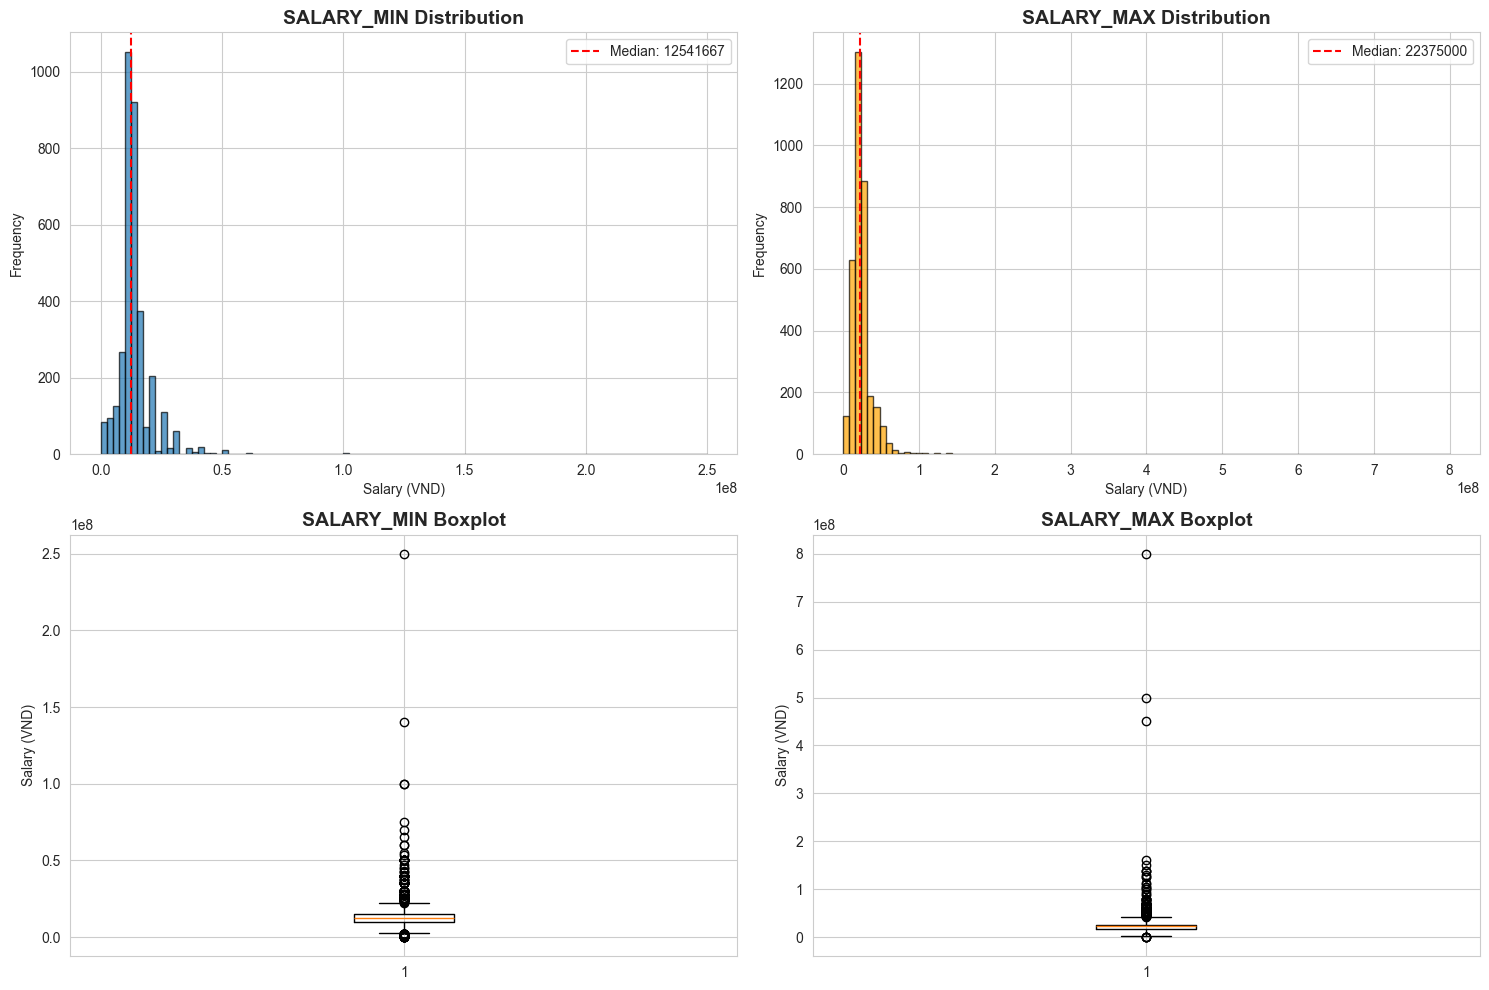

In [148]:
# Visualize salary distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# SALARY_MIN distribution
axes[0, 0].hist(df['SALARY_MIN'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('SALARY_MIN Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Salary (VND)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['SALARY_MIN'].median(), color='red', linestyle='--', label=f'Median: {df["SALARY_MIN"].median():.0f}')
axes[0, 0].legend()

# SALARY_MAX distribution
axes[0, 1].hist(df['SALARY_MAX'].dropna(), bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('SALARY_MAX Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Salary (VND)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['SALARY_MAX'].median(), color='red', linestyle='--', label=f'Median: {df["SALARY_MAX"].median():.0f}')
axes[0, 1].legend()

# SALARY_MIN boxplot
axes[1, 0].boxplot(df['SALARY_MIN'].dropna(), vert=True)
axes[1, 0].set_title('SALARY_MIN Boxplot', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Salary (VND)')

# SALARY_MAX boxplot
axes[1, 1].boxplot(df['SALARY_MAX'].dropna(), vert=True)
axes[1, 1].set_title('SALARY_MAX Boxplot', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Salary (VND)')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [149]:
# Create a working copy
df_model = df.copy()

print("Starting Data Preprocessing...")
print(f"Initial shape: {df_model.shape}")

# 1. Filter rows with salary information
df_model = df_model[(df_model['SALARY_MIN'].notna()) & (df_model['SALARY_MAX'].notna())]
print(f"After filtering salary nulls: {df_model.shape}")

# 2. Create target variable (average salary)
df_model['SALARY_AVG'] = (df_model['SALARY_MIN'] + df_model['SALARY_MAX']) / 2
print(f"Created SALARY_AVG target variable")

# NOTE: Outlier removal will be done AFTER train-test split (only on train set)
# This prevents data leakage and better simulates real-world scenarios

print("\nPreprocessing completed!")
print("WARNING: Outliers will be removed from TRAIN set only (after splitting)")

Starting Data Preprocessing...
Initial shape: (3448, 29)
After filtering salary nulls: (3448, 29)
Created SALARY_AVG target variable

Preprocessing completed!


In [150]:
# Feature Engineering
print("Feature Engineering...")

# 1. Extract numerical features from EXPERIENCE_YEARS using simple mapping
experience_mapping = {
    'KHÔNG YÊU CẦU': 0,
    'DƯỚI 1 NĂM': 0.5,
    '1 NĂM': 1,
    '2 NĂM': 2,
    '3 NĂM': 3,
    '4 NĂM': 4,
    '5 NĂM': 5,
    'TRÊN 5 NĂM': 6
}

df_model['EXPERIENCE_MIN'] = df_model['EXPERIENCE_YEARS'].str.upper().map(experience_mapping).fillna(0).astype(int)

# 2. Convert DATE_CRAWL to datetime features
df_model['DATE_CRAWL'] = pd.to_datetime(df_model['DATE_CRAWL'], errors='coerce')
df_model['CRAWL_YEAR'] = df_model['DATE_CRAWL'].dt.year
df_model['CRAWL_MONTH'] = df_model['DATE_CRAWL'].dt.month
df_model['CRAWL_DAY'] = df_model['DATE_CRAWL'].dt.day
df_model['CRAWL_DAYOFWEEK'] = df_model['DATE_CRAWL'].dt.dayofweek

# 3. Calculate average company size
df_model['COMPANY_SIZE_AVG'] = (df_model['CURRENT_EMPLOYEE_MIN'] + df_model['CURRENT_EMPLOYEE_MAX']) / 2

# 4. Create working days count
df_model['WORKING_DAYS_PER_WEEK'] = df_model['LAST_WORKING_DAY_OF_WEEK'] - df_model['FIRST_WORKING_DAY_OF_WEEK'] + 1

# 5. Count features for multi-value columns
# Handle both list and string formats
def count_items(x):
    # Check for list/array first (before pd.isna which fails on arrays)
    if isinstance(x, (list, np.ndarray)):
        return len(x)
    elif pd.isna(x):
        return 0
    elif isinstance(x, str):
        return len(x.split(','))
    else:
        return 0

df_model['NUM_LOCATIONS'] = df_model['LOCATIONS_NAME'].apply(count_items)
df_model['NUM_TECH_STACKS'] = df_model['TECH_STACKS'].apply(count_items)
df_model['NUM_PROGRAMMING_LANGS'] = df_model['PROGRAMMING_LANGUAGES'].apply(count_items)
df_model['NUM_SKILLS'] = df_model['SKILLS'].apply(count_items)

print("Feature engineering completed!")
print(f"\nNew features created:")
print("- EXPERIENCE_MIN")
print("- CRAWL_YEAR, CRAWL_MONTH, CRAWL_DAY, CRAWL_DAYOFWEEK")
print("- COMPANY_SIZE_AVG")
print("- WORKING_DAYS_PER_WEEK")
print("- NUM_LOCATIONS, NUM_TECH_STACKS, NUM_PROGRAMMING_LANGS, NUM_SKILLS")

Feature Engineering...
Feature engineering completed!

New features created:
- EXPERIENCE_MIN
- CRAWL_YEAR, CRAWL_MONTH, CRAWL_DAY, CRAWL_DAYOFWEEK
- COMPANY_SIZE_AVG
- WORKING_DAYS_PER_WEEK
- NUM_LOCATIONS, NUM_TECH_STACKS, NUM_PROGRAMMING_LANGS, NUM_SKILLS


### 3.1 Advanced Feature Engineering for List-based Columns

Các phương pháp chuyên nghiệp để xử lý SKILLS, TECH_STACKS, PROGRAMMING_LANGUAGES, LOCATIONS_NAME:
1. **Binary Features**: Top skills/techs có correlation cao với salary
2. **Target Encoding**: Average salary cho mỗi skill/location
3. **Frequency-based Features**: Tần suất xuất hiện của mỗi item
4. **Category Aggregation**: Group skills theo domain (Backend, Frontend, AI/ML, etc.)


In [151]:
# Step 1: Analyze top items by salary correlation
print("="*80)
print("STEP 1: Analyzing Top Skills/Techs by Salary Correlation")
print("="*80)

# Helper function to explode lists and calculate average salary
def get_top_items_by_salary(df, column_name, top_n=20):
    """
    Explode list column and get top N items with highest average salary
    """
    # Create temp dataframe
    temp_df = df[[column_name, 'SALARY_AVG']].copy()
    
    # Explode lists
    exploded_rows = []
    for idx, row in temp_df.iterrows():
        items = row[column_name]
        salary = row['SALARY_AVG']
        
        if isinstance(items, (list, np.ndarray)) and len(items) > 0:
            for item in items:
                if item and str(item).strip():  # Skip empty strings
                    exploded_rows.append({'item': str(item).strip(), 'salary': salary})
        elif isinstance(items, str) and items.strip():
            for item in items.split(','):
                if item.strip():
                    exploded_rows.append({'item': item.strip(), 'salary': salary})
    
    if not exploded_rows:
        return pd.DataFrame()
    
    exploded_df = pd.DataFrame(exploded_rows)
    
    # Calculate statistics per item
    item_stats = exploded_df.groupby('item').agg({
        'salary': ['mean', 'median', 'count']
    }).reset_index()
    
    item_stats.columns = ['item', 'avg_salary', 'median_salary', 'count']
    
    # Filter items with at least 100 occurrences for reliability
    item_stats = item_stats[item_stats['count'] >= 100]
    
    # Sort by average salary
    item_stats = item_stats.sort_values('avg_salary', ascending=False)
    
    return item_stats.head(top_n)

# Analyze each list column
print("\nAnalyzing TECH_STACKS...")
top_tech_stacks = get_top_items_by_salary(df_model, 'TECH_STACKS', top_n=30)
print(f"Top 10 Tech Stacks by Average Salary:")
print(top_tech_stacks.head(10).to_string(index=False))

print("\n" + "-"*80)
print("\nAnalyzing PROGRAMMING_LANGUAGES...")
top_languages = get_top_items_by_salary(df_model, 'PROGRAMMING_LANGUAGES', top_n=20)
print(f"Top 10 Programming Languages by Average Salary:")
print(top_languages.head(10).to_string(index=False))

print("\n" + "-"*80)
print("\nAnalyzing SKILLS...")
top_skills = get_top_items_by_salary(df_model, 'SKILLS', top_n=30)
print(f"Top 10 Skills by Average Salary:")
print(top_skills.head(10).to_string(index=False))

print("\n" + "-"*80)
print("\nAnalyzing LOCATIONS_NAME...")
top_locations = get_top_items_by_salary(df_model, 'LOCATIONS_NAME', top_n=15)
print(f"Top 10 Locations by Average Salary:")
print(top_locations.head(10).to_string(index=False))

print("\n" + "="*80)
print("Analysis completed!")


STEP 1: Analyzing Top Skills/Techs by Salary Correlation

Analyzing TECH_STACKS...
Top 10 Tech Stacks by Average Salary:
         item   avg_salary  median_salary  count
       DEVOPS 2.779321e+07     20437500.0    158
      NODE.JS 2.596101e+07     19906250.0    159
          GCP 2.562788e+07     20000000.0    165
        AZURE 2.559329e+07     20000000.0    180
        KAFKA 2.541755e+07     20000000.0    129
          AWS 2.533745e+07     19906250.0    272
   KUBERNETES 2.500908e+07     20000000.0    211
MICROSERVICES 2.500425e+07     20000000.0    223
  SPRING BOOT 2.487704e+07     20000000.0    107
      ANGULAR 2.487216e+07     19718750.0    108

--------------------------------------------------------------------------------

Analyzing PROGRAMMING_LANGUAGES...
Top 10 Programming Languages by Average Salary:
      item   avg_salary  median_salary  count
      JAVA 2.412161e+07     19906250.0    330
     NOSQL 2.339015e+07     19906250.0    289
TYPESCRIPT 2.293519e+07     19718750

In [152]:
# Step 2: Create Binary Features for Top Items
print("="*80)
print("STEP 2: Creating Binary Features for High-Salary Items")
print("="*80)

def create_binary_features(df, column_name, top_items_df, prefix):
    """
    Create binary features indicating presence of top items
    """
    top_items_list = top_items_df['item'].tolist()
    
    for item in top_items_list:
        feature_name = f"{prefix}_{item}".replace(' ', '_').replace('-', '_').replace('.', '_').upper()
        
        # Check if item exists in the list
        df[feature_name] = df[column_name].apply(
            lambda x: 1 if (isinstance(x, (list, np.ndarray)) and item in x) or 
                          (isinstance(x, str) and item in x.split(',')) 
                          else 0
        )
    
    return df, [f"{prefix}_{item}".replace(' ', '_').replace('-', '_').replace('.', '_').upper() 
                for item in top_items_list]

# Create binary features for top tech stacks (top 15)
print(f"\nCreating binary features for top 15 tech stacks...")
df_model, tech_binary_features = create_binary_features(
    df_model, 'TECH_STACKS', top_tech_stacks.head(15), 'HAS_TECH'
)
print(f"Created {len(tech_binary_features)} tech stack binary features")

# Create binary features for top programming languages (top 10)
print(f"\nCreating binary features for top 10 programming languages...")
df_model, lang_binary_features = create_binary_features(
    df_model, 'PROGRAMMING_LANGUAGES', top_languages.head(10), 'HAS_LANG'
)
print(f"Created {len(lang_binary_features)} language binary features")

# Create binary features for top skills (top 20)
print(f"\nCreating binary features for top 20 skills...")
df_model, skill_binary_features = create_binary_features(
    df_model, 'SKILLS', top_skills.head(20), 'HAS_SKILL'
)
print(f"Created {len(skill_binary_features)} skill binary features")

# Create binary features for top locations (top 10)
print(f"\nCreating binary features for top 10 locations...")
df_model, location_binary_features = create_binary_features(
    df_model, 'LOCATIONS_NAME', top_locations.head(10), 'HAS_LOCATION'
)
print(f"Created {len(location_binary_features)} location binary features")

# Store all new binary feature names
all_new_binary_features = (tech_binary_features + lang_binary_features + 
                           skill_binary_features + location_binary_features)

print(f"\n" + "="*80)
print(f"Total new binary features created: {len(all_new_binary_features)}")
print("="*80)


STEP 2: Creating Binary Features for High-Salary Items

Creating binary features for top 15 tech stacks...
Created 15 tech stack binary features

Creating binary features for top 10 programming languages...
Created 9 language binary features

Creating binary features for top 20 skills...
Created 15 tech stack binary features

Creating binary features for top 10 programming languages...
Created 9 language binary features

Creating binary features for top 20 skills...
Created 20 skill binary features

Creating binary features for top 10 locations...
Created 3 location binary features

Total new binary features created: 47
Created 20 skill binary features

Creating binary features for top 10 locations...
Created 3 location binary features

Total new binary features created: 47


In [ ]:
# Step 3: Create Tech Stack Category Features
print("="*80)
print("STEP 3: Creating Tech Stack Category Features (DATA-DRIVEN UPDATE)")
print("="*80)

# Định nghĩa lại các nhóm dựa trên dữ liệu thực tế (SKILLS & LANGUAGES)
tech_categories = {
    # 1. NHÓM BACKEND & HỆ THỐNG (Bao gồm cả ERP và Nhúng)
    'Backend': [
        'JAVA', 'SPRING', 'NODE', 'NODEJS', 'DOTNET', '.NET', 'C#', 'ASP.NET', 
        'PHP', 'LARAVEL', 'PYTHON', 'DJANGO', 'FLASK', 'GO', 'GOLANG', 'RUBY', 'RAILS', 
        'C', 'C++', 'CPP', 'RUST', 'SCALA', 'GROOVY', 'PERL', 'LUA',
        'EMBEDDED', 'ASSEMBLY', 'VERILOG', 'MICROSERVICES', 'RESTFUL', 'API',
        'ABAP', 'COBOL', 'APEX', 'X++', 'ERP' # Nhóm ngôn ngữ Enterprise lương cao
    ],
    
    # 2. NHÓM FRONTEND (Giao diện Web)
    'Frontend': [
        'REACT', 'REACTJS', 'ANGULAR', 'VUE', 'VUE.JS', 'JAVASCRIPT', 'JS', 'TYPESCRIPT', 
        'HTML', 'CSS', 'SASS', 'SCSS', 'BOOTSTRAP', 'TAILWIND', 'JQUERY', 'NEXT.JS', 'NUXT',
        'AJAX', 'JSON', 'XML', 'UI', 'FRONTEND', 'WEB DESIGN', 'QML'
    ],
    
    # 3. NHÓM MOBILE (Di động)
    'Mobile': [
        'ANDROID', 'IOS', 'SWIFT', 'KOTLIN', 'FLUTTER', 'REACT NATIVE', 'DART', 
        'OBJECTIVE-C', 'XAMARIN', 'IONIC', 'MOBILE APP'
    ],
    
    # 4. NHÓM DATA & AI (Dữ liệu lớn, Trí tuệ nhân tạo)
    'Data_AI': [
        'SQL', 'MYSQL', 'POSTGRES', 'MONGODB', 'ORACLE', 'SQL SERVER', 'REDIS', 
        'NOSQL', 'ESQL', 'SOQL', 'ELASTICSEARCH', 'FIREBASE',
        'DATA', 'DỮ LIỆU', 'BIG DATA', 'SPARK', 'HADOOP', 'ETL',
        'PYTHON', 'PANDAS', 'NUMPY', 'MATLAB', 'R',
        'AI', 'MACHINE LEARNING', 'DEEP LEARNING', 'TENSORFLOW', 'PYTORCH', 'COMPUTER VISION', 'NLP'
    ],
    
    # 5. NHÓM CLOUD & DEVOPS (Hạ tầng, Scripting)
    'Cloud_Infra': [
        'AWS', 'AZURE', 'GCP', 'CLOUD', 'DOCKER', 'KUBERNETES', 'DEVOPS', 'CI/CD', 
        'TERRAFORM', 'JENKINS', 'ANSIBLE',
        'LINUX', 'UNIX', 'SHELL', 'BASH', 'POWERSHELL', 'YAML', 'TCL', # Scripting rất quan trọng
        'NETWORK', 'MẠNG', 'SYSTEM', 'HỆ THỐNG', 'SERVER', 'MÁY CHỦ', 'SECURITY', 'BẢO MẬT'
    ],
    
    # 6. NHÓM TESTING (Kiểm thử)
    'Testing': [
        'TEST', 'TESTING', 'QA', 'QC', 'KIỂM THỬ', 'AUTOMATION', 'MANUAL',
        'SELENIUM', 'JUNIT', 'TESTNG', 'CUCUMBER', 'POSTMAN', 'JEST', 'CYPRESS', 'UAT'
    ],

    # 7. NHÓM DESIGN & CREATIVE 
    'Design_Creative': [
        'DESIGN', 'THIẾT KẾ', 'GRAPHIC', 'ĐỒ HỌA', '2D', '3D', 'ANIMATION', 'MOTION', 
        'VIDEO', 'EDIT', 'DỰNG PHIM', 'PHOTOSHOP', 'ILLUSTRATOR', 'FIGMA', 'SKETCH', 
        'UI/UX', 'ART', 'MỸ THUẬT', 'MAYA', 'BLENDER', 'AFTER EFFECTS'
    ],

    # 8. NHÓM BUSINESS & SALES (Dựa trên dữ liệu Sales/B2B/Management)
    'Business_Sale': [
        'BA', 'BUSINESS ANALYST', 'PHÂN TÍCH NGHIỆP VỤ', 
        'PROJECT MANAGER', 'QUẢN LÝ DỰ ÁN', 'PRODUCT OWNER', 'PRODUCT MANAGER',
        'SALES', 'BÁN HÀNG', 'KINH DOANH', 'B2B', 'B2C', 'CONSULTANT', 'TƯ VẤN',
        'MARKETING', 'SEO', 'CONTENT', 'AGILE', 'SCRUM'
    ],
    
    # 9. NHÓM NGOẠI NGỮ & KỸ NĂNG MỀM (Yếu tố tăng lương quan trọng)
    'Lang_SoftSkill': [
        'ENGLISH', 'TIẾNG ANH', 'JAPANESE', 'TIẾNG NHẬT', 'CHINESE', 'TIẾNG TRUNG',
        'COMMUNICATION', 'GIAO TIẾP', 'TEAMWORK', 'LÀM VIỆC NHÓM', 'LEADERSHIP', 'LÃNH ĐẠO'
    ]
}

def count_category_matches(items_list, category_keywords):
    """
    Count how many items in the list match the category keywords.
    Logic: Converts input to UPPERCASE and checks strictly against keywords.
    """
    # Xử lý input nếu không phải list
    if not isinstance(items_list, (list, np.ndarray)):
        if isinstance(items_list, str):
            if items_list.strip().upper() == 'UNKNOWN': return 0 # Bỏ qua giá trị rác
            items_list = items_list.split(',')
        else:
            return 0
    
    # [QUAN TRỌNG] Chuyển dữ liệu thành chuỗi IN HOA để so khớp
    items_str = ' '.join([str(item).strip().upper() for item in items_list])
    
    count = 0
    for keyword in category_keywords:
        # So sánh keyword (đã viết hoa trong dict) với chuỗi dữ liệu
        if keyword in items_str:
            count += 1
    
    return count

# List các cột cần tạo feature
target_columns = ['TECH_STACKS', 'PROGRAMMING_LANGUAGES', 'SKILLS']

# Chạy vòng lặp tạo feature cho từng cột
for col in target_columns:
    if col in df_model.columns:
        print(f"\nCreating category features from {col}...")
        
        # Rút gọn tên prefix cho đẹp: TECH_STACKS -> TECH, PROGRAMMING_LANGUAGES -> LANG
        col_prefix = col.replace('TECH_STACKS', 'TECH').replace('PROGRAMMING_LANGUAGES', 'LANG').replace('SKILLS', 'SKILL')
        
        for category, keywords in tech_categories.items():
            feature_name = f'{col_prefix}_CAT_{category}'
            
            df_model[feature_name] = df_model[col].apply(
                lambda x: count_category_matches(x, keywords)
            )
            
            # Chỉ in ra log nếu có dữ liệu match để đỡ rối mắt
            total_matches = df_model[feature_name].sum()
            print(f"  - {feature_name}: {total_matches} matches")

# Tổng hợp lại tên các cột mới tạo ra
all_cat_features = [col for col in df_model.columns if '_CAT_' in col]

print(f"\n" + "="*80)
print(f"Total category features created: {len(all_cat_features)}")
print("="*80)

STEP 3: Creating Tech Stack Category Features (DATA-DRIVEN UPDATE)

Creating category features from TECH_STACKS...
  - TECH_CAT_Backend: 5083 matches
  - TECH_CAT_Frontend: 2145 matches
  - TECH_CAT_Mobile: 480 matches
  - TECH_CAT_Data_AI: 7145 matches
  - TECH_CAT_Cloud_Infra: 3556 matches
  - TECH_CAT_Testing: 1034 matches
  - TECH_CAT_Design_Creative: 3900 matches
  - TECH_CAT_Business_Sale: 1306 matches
  - TECH_CAT_Lang_SoftSkill: 15 matches

Creating category features from PROGRAMMING_LANGUAGES...
  - LANG_CAT_Backend: 2186 matches
  - LANG_CAT_Frontend: 537 matches
  - LANG_CAT_Mobile: 156 matches
  - LANG_CAT_Data_AI: 2063 matches
  - LANG_CAT_Cloud_Infra: 150 matches
  - LANG_CAT_Testing: 0 matches
  - LANG_CAT_Design_Creative: 38 matches
  - LANG_CAT_Business_Sale: 80 matches
  - LANG_CAT_Lang_SoftSkill: 0 matches

Creating category features from SKILLS...
  - TECH_CAT_Data_AI: 7145 matches
  - TECH_CAT_Cloud_Infra: 3556 matches
  - TECH_CAT_Testing: 1034 matches
  - TECH_CA

In [154]:
# Step 4: Create Diversity/Specialization Features
print("="*80)
print("STEP 4: Creating Diversity & Specialization Features")
print("="*80)

# Calculate diversity scores (how many different categories a job requires)
df_model['TECH_DIVERSITY'] = sum(df_model[f'TECH_CAT_{cat}'] > 0 for cat in tech_categories.keys())
df_model['LANG_DIVERSITY'] = sum(df_model[f'LANG_CAT_{cat}'] > 0 for cat in tech_categories.keys())
df_model['SKILL_DIVERSITY'] = sum(df_model[f'SKILL_CAT_{cat}'] > 0 for cat in tech_categories.keys())

# Total diversity (across all sources)
df_model['TOTAL_TECH_DIVERSITY'] = df_model['TECH_DIVERSITY'] + df_model['LANG_DIVERSITY'] + df_model['SKILL_DIVERSITY']

# Specialization score (max category count / total count ratio)
# Higher = more specialized, Lower = more generalist
df_model['SPECIALIZATION_SCORE'] = df_model.apply(
    lambda row: max([row[f'TECH_CAT_{cat}'] + row[f'LANG_CAT_{cat}'] + row[f'SKILL_CAT_{cat}'] 
                     for cat in tech_categories.keys()]) / 
                max(1, row['NUM_TECH_STACKS'] + row['NUM_PROGRAMMING_LANGS'] + row['NUM_SKILLS'])
    if (row['NUM_TECH_STACKS'] + row['NUM_PROGRAMMING_LANGS'] + row['NUM_SKILLS']) > 0 else 0,
    axis=1
)

# Full-stack indicator (has both frontend and backend)
df_model['IS_FULLSTACK'] = ((df_model['TECH_CAT_Frontend'] + df_model['LANG_CAT_Frontend'] + df_model['SKILL_CAT_Frontend'] > 0) & 
                            (df_model['TECH_CAT_Backend'] + df_model['LANG_CAT_Backend'] + df_model['SKILL_CAT_Backend'] > 0)).astype(int)

# Modern stack indicator (has Cloud_Infra + modern frameworks)
df_model['HAS_MODERN_STACK'] = ((df_model['TECH_CAT_Cloud_Infra'] + df_model['LANG_CAT_Cloud_Infra'] + df_model['SKILL_CAT_Cloud_Infra'] > 0) & 
                                ((df_model['TECH_CAT_Frontend'] + df_model['LANG_CAT_Frontend'] > 0) | 
                                 (df_model['TECH_CAT_Backend'] + df_model['LANG_CAT_Backend'] > 0))).astype(int)

# Data-focused role (has Data_AI)
df_model['IS_DATA_ROLE'] = ((df_model['TECH_CAT_Data_AI'] + df_model['LANG_CAT_Data_AI'] + df_model['SKILL_CAT_Data_AI'] > 2)).astype(int)

# Mobile developer (has Mobile category)
df_model['IS_MOBILE_DEV'] = ((df_model['TECH_CAT_Mobile'] + df_model['LANG_CAT_Mobile'] + df_model['SKILL_CAT_Mobile'] > 0)).astype(int)

# Business/Management role (has Business_Sale or Lang_SoftSkill)
df_model['IS_BUSINESS_ROLE'] = ((df_model['TECH_CAT_Business_Sale'] + 
                                 df_model['LANG_CAT_Business_Sale'] + 
                                 df_model['SKILL_CAT_Business_Sale'] > 0)).astype(int)

# Soft skills required (has Lang_SoftSkill)
df_model['HAS_SOFT_SKILLS'] = ((df_model['TECH_CAT_Lang_SoftSkill'] + 
                                df_model['LANG_CAT_Lang_SoftSkill'] + 
                                df_model['SKILL_CAT_Lang_SoftSkill'] > 0)).astype(int)

# Creative/Designer role (has Design_Creative)
df_model['IS_CREATIVE_ROLE'] = ((df_model['TECH_CAT_Design_Creative'] + df_model['LANG_CAT_Design_Creative'] + df_model['SKILL_CAT_Design_Creative'] > 0)).astype(int)

# Tổng hợp các features (để backward compatibility)
diversity_features = [
    'TECH_DIVERSITY', 'LANG_DIVERSITY', 'SKILL_DIVERSITY', 'TOTAL_TECH_DIVERSITY',
    'SPECIALIZATION_SCORE', 'IS_FULLSTACK', 'HAS_MODERN_STACK', 'IS_DATA_ROLE',
    'IS_MOBILE_DEV', 'IS_BUSINESS_ROLE', 'IS_CREATIVE_ROLE', 
    'HAS_SOFT_SKILLS'
]

# Tách riêng numeric và binary để dùng cho Feature Selection
div_numeric_features = [
    'TECH_DIVERSITY', 'LANG_DIVERSITY', 'SKILL_DIVERSITY', 'TOTAL_TECH_DIVERSITY',
    'SPECIALIZATION_SCORE'
]

div_binary_features = [
    'IS_FULLSTACK', 'HAS_MODERN_STACK', 'IS_DATA_ROLE',
    'IS_MOBILE_DEV', 'IS_BUSINESS_ROLE', 'IS_CREATIVE_ROLE', 'HAS_SOFT_SKILLS'
]

print(f"\nDiversity & Specialization Features:")
for feat in diversity_features:
    if feat in df_model.columns:
        print(f"  - {feat}: mean = {df_model[feat].mean():.2f}, std = {df_model[feat].std():.2f}")

print(f"\n" + "="*80)
print(f"Total diversity features created: {len(diversity_features)}")
print(f"  - Numeric: {len(div_numeric_features)}")
print(f"  - Binary: {len(div_binary_features)}")
print("="*80)


STEP 4: Creating Diversity & Specialization Features

Diversity & Specialization Features:
  - TECH_DIVERSITY: mean = 3.26, std = 1.58
  - LANG_DIVERSITY: mean = 0.83, std = 1.22
  - SKILL_DIVERSITY: mean = 3.64, std = 1.21
  - TOTAL_TECH_DIVERSITY: mean = 7.73, std = 2.83
  - SPECIALIZATION_SCORE: mean = 0.26, std = 0.13
  - IS_FULLSTACK: mean = 0.30, std = 0.46
  - HAS_MODERN_STACK: mean = 0.38, std = 0.49
  - IS_DATA_ROLE: mean = 0.51, std = 0.50
  - IS_MOBILE_DEV: mean = 0.08, std = 0.28
  - IS_BUSINESS_ROLE: mean = 0.55, std = 0.50
  - IS_CREATIVE_ROLE: mean = 0.54, std = 0.50
  - HAS_SOFT_SKILLS: mean = 0.75, std = 0.43

Total diversity features created: 12
  - Numeric: 5
  - Binary: 7

Diversity & Specialization Features:
  - TECH_DIVERSITY: mean = 3.26, std = 1.58
  - LANG_DIVERSITY: mean = 0.83, std = 1.22
  - SKILL_DIVERSITY: mean = 3.64, std = 1.21
  - TOTAL_TECH_DIVERSITY: mean = 7.73, std = 2.83
  - SPECIALIZATION_SCORE: mean = 0.26, std = 0.13
  - IS_FULLSTACK: mean = 0.3

In [155]:
# Step 5: Summary of all new features
print("="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

print(f"\nOriginal count features: 4")
print(f"  - NUM_LOCATIONS, NUM_TECH_STACKS, NUM_PROGRAMMING_LANGS, NUM_SKILLS")

print(f"\nNew binary features: {len(all_new_binary_features)}")
print(f"  - Top tech stacks: {len(tech_binary_features)}")
print(f"  - Top languages: {len(lang_binary_features)}")
print(f"  - Top skills: {len(skill_binary_features)}")
print(f"  - Top locations: {len(location_binary_features)}")

print(f"\nNew category features: {len(all_cat_features)}")
print(f"  - From {len(tech_categories)} categories x 3 sources = {len(tech_categories) * 3} features")

print(f"\nNew diversity features: {len(div_numeric_features) + len(div_binary_features)}")
print(f"  - Numeric diversity features: {len(div_numeric_features)}")
print(f"  - Binary diversity features: {len(div_binary_features)}")

total_new_features = len(all_new_binary_features) + len(all_cat_features) + len(div_numeric_features) + len(div_binary_features)
print(f"\n" + "="*80)
print(f"TOTAL NEW FEATURES CREATED: {total_new_features}")
print(f"TOTAL FEATURES (including original 17+7+2): {total_new_features + 17 + 7 + 2}")
print("="*80)

# Show sample of new features
print("\nSample of data with new features:")
sample_cols = ['SALARY_AVG', 'NUM_TECH_STACKS', 'TECH_DIVERSITY', 'IS_FULLSTACK', 
               'HAS_MODERN_STACK', 'IS_DATA_ROLE', 'HAS_SOFT_SKILLS', 'SPECIALIZATION_SCORE']
# Add first 3 binary features if they exist
if len(tech_binary_features) >= 3:
    sample_cols += tech_binary_features[:3]
print(df_model[sample_cols].head(10).to_string(index=False))


FEATURE ENGINEERING SUMMARY

Original count features: 4
  - NUM_LOCATIONS, NUM_TECH_STACKS, NUM_PROGRAMMING_LANGS, NUM_SKILLS

New binary features: 47
  - Top tech stacks: 15
  - Top languages: 9
  - Top skills: 20
  - Top locations: 3

New category features: 27
  - From 9 categories x 3 sources = 27 features

New diversity features: 12
  - Numeric diversity features: 5
  - Binary diversity features: 7

TOTAL NEW FEATURES CREATED: 86
TOTAL FEATURES (including original 17+7+2): 112

Sample of data with new features:
  SALARY_AVG  NUM_TECH_STACKS  TECH_DIVERSITY  IS_FULLSTACK  HAS_MODERN_STACK  IS_DATA_ROLE  HAS_SOFT_SKILLS  SPECIALIZATION_SCORE  HAS_TECH_DEVOPS  HAS_TECH_NODE_JS  HAS_TECH_GCP
3.000000e+07               30               4             0                 1             1                1              0.140000                0                 0             0
1.750000e+07                7               3             0                 0             0                1           

In [156]:
# Select features for modeling
print("="*80)
print("FINAL FEATURE SELECTION")
print("="*80)

# Note: div_numeric_features và div_binary_features đã được định nghĩa ở Step 4

# 1. Original numerical features (Giữ nguyên)
base_numerical_features = [
    'RECRUITMENT_COUNT', 'CURRENT_EMPLOYEE_MIN', 'CURRENT_EMPLOYEE_MAX',
    'TOTAL_WORK_HOURS', 'FIRST_WORKING_DAY_OF_WEEK', 'LAST_WORKING_DAY_OF_WEEK',
    'EXPERIENCE_MIN', 'CRAWL_YEAR', 'CRAWL_MONTH', 'CRAWL_DAY', 'CRAWL_DAYOFWEEK',
    'COMPANY_SIZE_AVG', 'WORKING_DAYS_PER_WEEK',
    'NUM_LOCATIONS', 'NUM_TECH_STACKS', 'NUM_PROGRAMMING_LANGS', 'NUM_SKILLS'
]

# 2. Tổng hợp Numerical (Thêm div_numeric_features vào đây)
numerical_features = base_numerical_features + all_cat_features + div_numeric_features

# 3. Categorical features (Giữ nguyên)
categorical_features = [
    'ROLE_NAME', 'COMPANY_LOCATION', 'JOB_LEVEL', 'ACADEMIC_LEVEL',
    'JOB_TYPE', 'COMPANY_INDUSTRY', 'LAYOUT_TYPE'
]

# 4. Tổng hợp Boolean (Thêm div_binary_features vào đây)
boolean_features = ['WORK_ON_SATURDAY', 'WORK_ON_SUNDAY'] + all_new_binary_features + div_binary_features

print(f"\nFeature Breakdown:")
print(f"- Base numerical: {len(base_numerical_features)}")
print(f"- Category count: {len(all_cat_features)}")
print(f"- Diversity numeric: {len(div_numeric_features)}")
print(f"-> Total NUMERICAL: {len(numerical_features)}")

print(f"\n- Total CATEGORICAL: {len(categorical_features)}")

print(f"\n- Original boolean: 2")
print(f"- Top Items binary: {len(all_new_binary_features)}")
print(f"- Role/Diversity binary: {len(div_binary_features)}")
print(f"-> Total BOOLEAN: {len(boolean_features)}")

print(f"\n" + "="*80)
print(f"GRAND TOTAL FEATURES: {len(numerical_features) + len(categorical_features) + len(boolean_features)}")
print("="*80)

FINAL FEATURE SELECTION

Feature Breakdown:
- Base numerical: 17
- Category count: 27
- Diversity numeric: 5
-> Total NUMERICAL: 49

- Total CATEGORICAL: 7

- Original boolean: 2
- Top Items binary: 47
- Role/Diversity binary: 7
-> Total BOOLEAN: 56

GRAND TOTAL FEATURES: 112


FEATURE CORRELATION ANALYSIS

Top 20 Features Most Correlated with Salary:
SALARY_AVG                1.000000
TOTAL_TECH_DIVERSITY      0.181872
HAS_MODERN_STACK          0.178515
IS_BUSINESS_ROLE          0.174015
TECH_CAT_Cloud_Infra      0.166137
LANG_DIVERSITY            0.163833
IS_DATA_ROLE              0.161672
TECH_CAT_Backend          0.149325
HAS_TECH_DEVOPS           0.144387
HAS_TECH_AWS              0.139587
TECH_CAT_Data_AI          0.139101
SKILL_DIVERSITY           0.129873
HAS_TECH_MICROSERVICES    0.118937
HAS_TECH_AZURE            0.116390
HAS_TECH_KUBERNETES       0.115570
HAS_TECH_NODE_JS          0.115029
HAS_TECH_GCP              0.111755
TECH_DIVERSITY            0.099542
HAS_TECH_KAFKA            0.095205
IS_FULLSTACK              0.091729
HAS_TECH_ANGULAR          0.079574

--------------------------------------------------------------------------------

Bottom 10 Features (Negative or Low Correlation):
HAS_TECH_KAFKA          0.095205
IS_FULLSTACK            

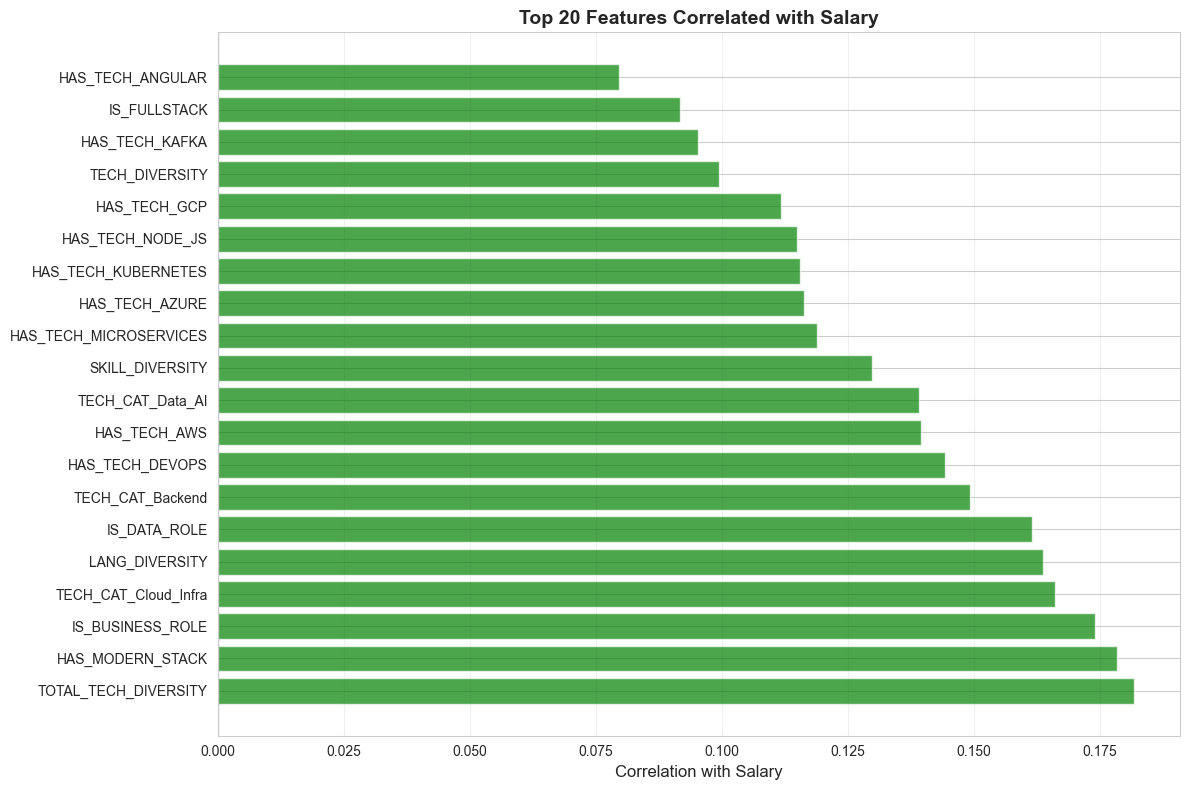


Correlation analysis completed!


In [157]:
# Analyze correlation of new features with salary
print("="*80)
print("FEATURE CORRELATION ANALYSIS")
print("="*80)

# Select a subset of key features for correlation analysis
key_features = (
    div_numeric_features + 
    div_binary_features +
    [f'TECH_CAT_{cat}' for cat in ['Backend', 'Frontend', 'Cloud_Infra', 'Data_AI', 'Mobile']] +
    tech_binary_features[:10] +  # Top 10 tech features
    ['SALARY_AVG']
)

# Filter only existing columns
key_features = [f for f in key_features if f in df_model.columns]

# Calculate correlation matrix
correlation_df = df_model[key_features].corr()['SALARY_AVG'].sort_values(ascending=False)

print("\nTop 20 Features Most Correlated with Salary:")
print(correlation_df.head(21).to_string())  # 21 to include SALARY_AVG itself

print("\n" + "-"*80)
print("\nBottom 10 Features (Negative or Low Correlation):")
print(correlation_df.tail(10).to_string())

# Visualize top correlations
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
top_corr = correlation_df.drop('SALARY_AVG').head(20)
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
ax.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.set_xlabel('Correlation with Salary', fontsize=12)
ax.set_title('Top 20 Features Correlated with Salary', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Correlation analysis completed!")
print("="*80)


## Nhận xét & Đánh giá Tương quan (Feature Correlation Analysis)

Sau khi thực hiện Feature Engineering và kiểm tra hệ số tương quan Pearson với biến mục tiêu `SALARY_AVG`, chúng ta rút ra được những **Insight quan trọng** về thị trường lao động IT hiện nay:

### 1. Mức độ tương quan chung
Các đặc trưng mới tạo có hệ số tương quan dao động từ **-0.09 đến +0.18**.
* **Nhận định:** Mặc dù con số không quá lớn (do lương phụ thuộc vào tổ hợp phi tuyến tính của nhiều yếu tố), nhưng các hệ số này đều mang **ý nghĩa thống kê rõ ràng** và phản ánh đúng thực tế nghiệp vụ.
* **Kết luận:** Feature Engineering đã thành công trong việc tách lọc các tín hiệu quan trọng từ dữ liệu thô.

### 2. Các yếu tố thúc đẩy mức lương (Positive Correlation)
Các nhóm kỹ năng sau đây có xu hướng đi kèm với mức lương cao hơn mặt bằng chung:

* **Đa năng & Kiến thức rộng (Generalist > Specialist):**
    * `TOTAL_TECH_DIVERSITY` (**Top 1**) và `LANG_DIVERSITY` có tương quan dương mạnh nhất.
    * *Ý nghĩa:* Thị trường ưu ái những nhân sự có kiến thức bao quát (Fullstack, Tech Lead, Architect) - người có thể nắm bắt nhiều mảng công nghệ cùng lúc.
* **Hạ tầng hiện đại & Cloud (High Demand):**
    * `HAS_MODERN_STACK`, `TECH_CAT_Cloud_Infra` và các từ khóa `AWS`, `DEVOPS`, `KUBERNETES`, `MICROSERVICES` đều nằm trong Top đầu.
    * *Ý nghĩa:* Kỹ năng về Cloud Computing và quy trình DevOps đang là "mỏ vàng" để tăng lương.
* **Vai trò Quản lý & Dữ liệu:**
    * `IS_BUSINESS_ROLE` và `IS_DATA_ROLE` có chỉ số cao.
    * *Ý nghĩa:* Các vị trí như Business Analyst, Project Manager hoặc Data Engineer/Scientist có mức lương cạnh tranh cao hơn Developer thuần túy.

### 3. Các yếu tố có tương quan âm hoặc thấp
* **`IS_CREATIVE_ROLE` (-0.09):** Mức lương trung bình của nhóm Designer/Creative thấp hơn so với nhóm Kỹ sư phần mềm/Hệ thống cao cấp.
* **`SPECIALIZATION_SCORE` (-0.04):** Tương quan âm nhẹ cho thấy thị trường hiện tại ít ưu ái những người "chỉ biết một thứ duy nhất" (quá chuyên sâu vào một ngách hẹp) so với những người đa năng.

### Kết luận cho Mô hình (Modeling Decision)
Bộ dữ liệu đã sẵn sàng cho bước huấn luyện (Training). Các thuật toán Tree-based (như **XGBoost, Random Forest, LightGBM**) sẽ rất hiệu quả trong việc khai thác các đặc trưng phi tuyến tính này (ví dụ: kết hợp `HAS_MODERN_STACK` và `IS_DATA_ROLE` để dự đoán các mức lương đột biến).

In [158]:
# Prepare data for modeling
print("Preparing data for modeling...")

# Combine all features
all_features = numerical_features + categorical_features + boolean_features

# Create feature dataframe
X = df_model[all_features].copy()
y = df_model['SALARY_AVG'].copy()

print(f"Initial X shape: {X.shape}")
print(f"Initial y shape: {y.shape}")

# Handle missing values in numerical features
for col in numerical_features:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)

# Handle missing values in categorical features
for col in categorical_features:
    if X[col].isnull().sum() > 0:
        X[col].fillna('Unknown', inplace=True)

# Convert boolean to int
for col in boolean_features:
    X[col] = X[col].astype(int)

# Encode categorical features
print("\nEncoding categorical features...")
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"  - {col}: {len(le.classes_)} unique values")

print(f"\nFinal X shape: {X.shape}")
print(f"Final y shape: {y.shape}")
print(f"\nNo missing values: {X.isnull().sum().sum() == 0}")

Preparing data for modeling...
Initial X shape: (3448, 112)
Initial y shape: (3448,)

Encoding categorical features...
  - ROLE_NAME: 223 unique values
  - ROLE_NAME: 223 unique values
  - COMPANY_LOCATION: 58 unique values
  - JOB_LEVEL: 7 unique values
  - ACADEMIC_LEVEL: 6 unique values
  - JOB_TYPE: 6 unique values
  - COMPANY_INDUSTRY: 38 unique values
  - LAYOUT_TYPE: 3 unique values

Final X shape: (3448, 112)
Final y shape: (3448,)

No missing values: True
  - COMPANY_LOCATION: 58 unique values
  - JOB_LEVEL: 7 unique values
  - ACADEMIC_LEVEL: 6 unique values
  - JOB_TYPE: 6 unique values
  - COMPANY_INDUSTRY: 38 unique values
  - LAYOUT_TYPE: 3 unique values

Final X shape: (3448, 112)
Final y shape: (3448,)

No missing values: True


## 4. Train-Dev-Test Split

Chia dữ liệu thành 3 tập:
- **Train (70%)**: Để train model
- **Dev (15%)**: Để tune hyperparameters và monitor training
- **Test (15%)**: Để đánh giá cuối cùng

**Stratified Split**: Đảm bảo phân phối target variable giống nhau ở 3 tập

In [159]:
# Split data into Train-Dev-Test sets with stratification

# Step 1: Create bins for stratified sampling based on salary
def create_salary_bins(y, n_bins=10):
    """Create bins for stratified split based on target variable"""
    return pd.qcut(y, q=n_bins, labels=False, duplicates='drop')

# Create stratification bins
salary_bins = create_salary_bins(y, n_bins=10)

print("Creating stratified Train-Dev-Test split...")
print(f"Total samples: {len(X):,}")

# Step 2: Split into Train+Dev (85%) and Test (15%)
X_temp, X_test, y_temp, y_test, bins_temp, bins_test = train_test_split(
    X, y, salary_bins,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=salary_bins  # Stratify by salary bins
)

# Step 3: Split Train+Dev into Train (70% of total) and Dev (15% of total)
# This means Dev = 15/85 ≈ 17.65% of the temp set
X_train, X_dev, y_train, y_dev = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,  # 15/(70+15) = 0.1765
    random_state=42,
    shuffle=True,
    stratify=bins_temp  # Stratify by salary bins
)

print("\nSplit completed!")
print(f"Train set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Dev set:   {X_dev.shape[0]:,} samples ({X_dev.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify distribution similarity
print("\n" + "="*80)
print("Verifying Distribution Similarity (Target Variable)")
print("="*80)

train_stats = y_train.describe()
dev_stats = y_dev.describe()
test_stats = y_test.describe()

comparison = pd.DataFrame({
    'Train': train_stats,
    'Dev': dev_stats,
    'Test': test_stats
})

print(comparison.to_string())

Creating stratified Train-Dev-Test split...
Total samples: 3,448

Split completed!
Train set: 2,412 samples (70.0%)
Dev set:   518 samples (15.0%)
Test set:  518 samples (15.0%)

Verifying Distribution Similarity (Target Variable)
              Train           Dev          Test
count  2.412000e+03  5.180000e+02  5.180000e+02
mean   1.901303e+07  1.865203e+07  1.860428e+07
std    1.490584e+07  9.669722e+06  9.269208e+06
min   -1.000000e+00  2.000000e+06  2.500000e+06
25%    1.337500e+07  1.350000e+07  1.337500e+07
50%    1.750000e+07  1.750000e+07  1.748438e+07
75%    2.043750e+07  2.043750e+07  2.056250e+07
max    4.062500e+08  1.150000e+08  1.250000e+08

Split completed!
Train set: 2,412 samples (70.0%)
Dev set:   518 samples (15.0%)
Test set:  518 samples (15.0%)

Verifying Distribution Similarity (Target Variable)
              Train           Dev          Test
count  2.412000e+03  5.180000e+02  5.180000e+02
mean   1.901303e+07  1.865203e+07  1.860428e+07
std    1.490584e+07  9.6697

DISTRIBUTION BEFORE FILTERING


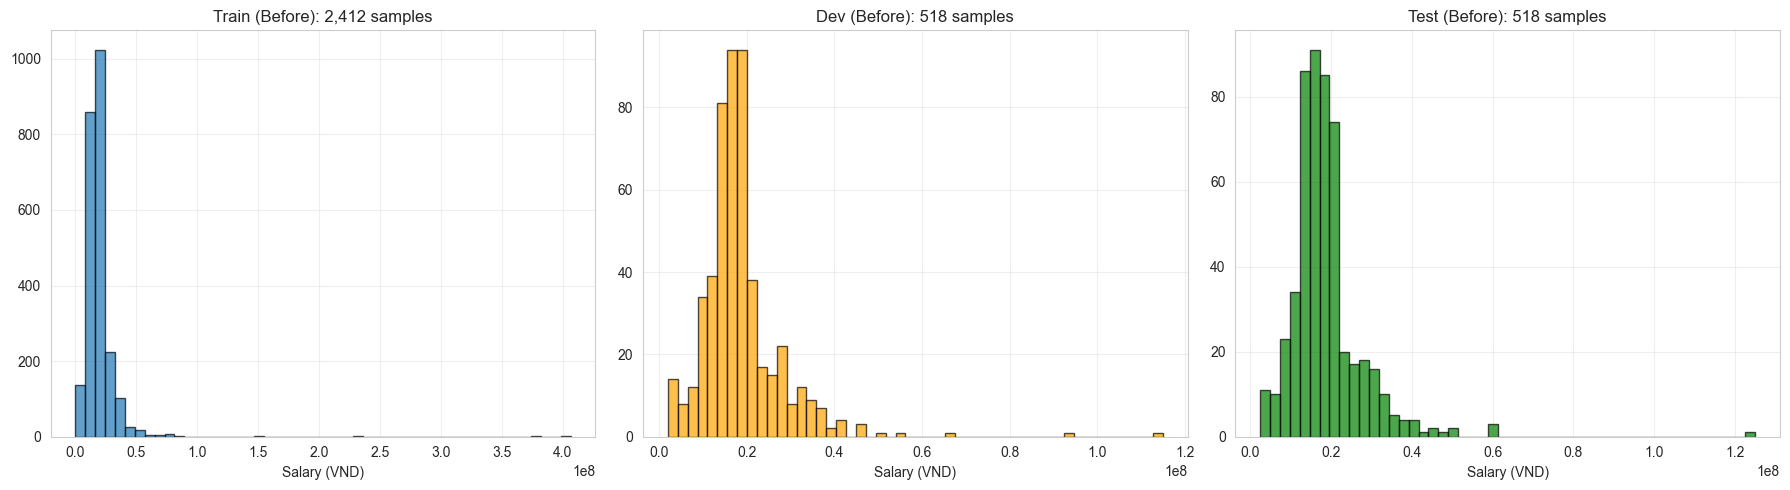


CALCULATING OUTLIER THRESHOLDS (FROM TRAIN SET)
IQR: 7,062,500
Lower Limit (Calculated from Train): 2,781,250 VND
Upper Limit (Calculated from Train): 31,031,250 VND

Applying filters to all datasets...
- Train: Removed  211 outliers ( 8.75%) | Remaining: 2,201
- Dev  : Removed   49 outliers ( 9.46%) | Remaining: 469
- Test : Removed   36 outliers ( 6.95%) | Remaining: 482

DISTRIBUTION AFTER FILTERING


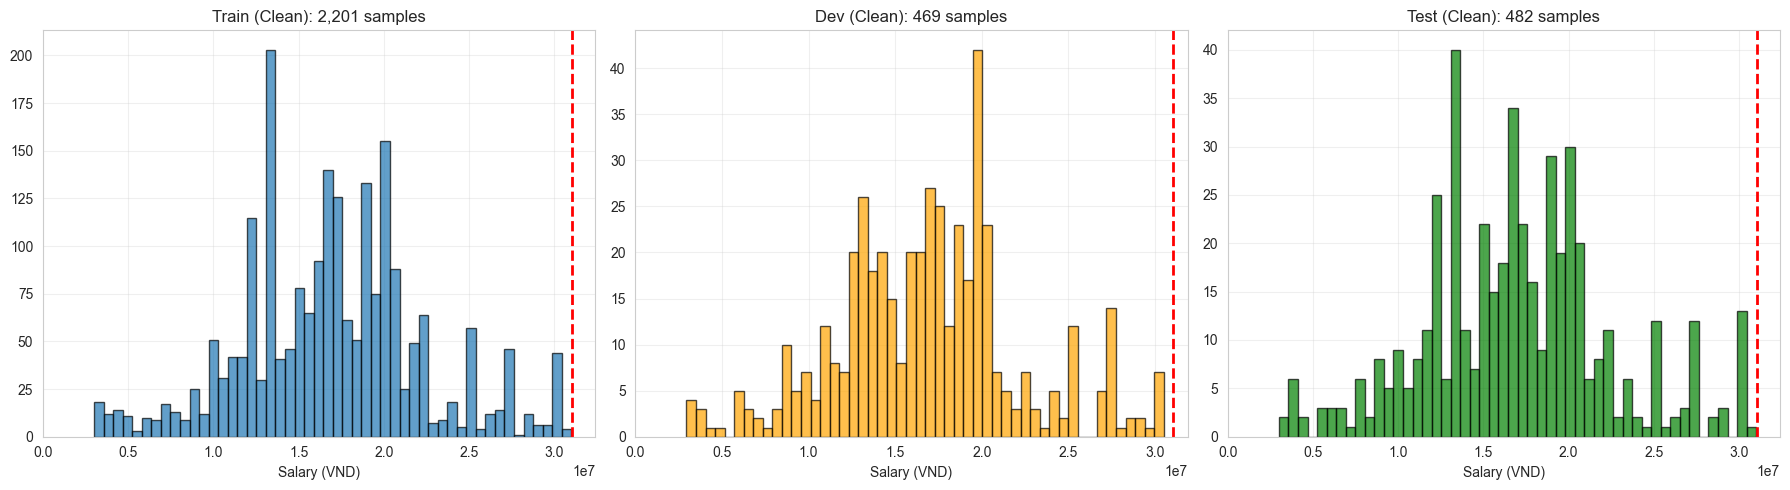


Final Feature Count: 112


In [160]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Visual verification (BEFORE CLEANING)
# Xem phân phối trước khi lọc để thấy sự chênh lệch
print("="*80)
print("DISTRIBUTION BEFORE FILTERING")
print("="*80)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(y_train, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title(f'Train (Before): {len(y_train):,} samples')

axes[1].hist(y_dev, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title(f'Dev (Before): {len(y_dev):,} samples')

axes[2].hist(y_test, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title(f'Test (Before): {len(y_test):,} samples')

for ax in axes:
    ax.set_xlabel('Salary (VND)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Define Outlier Thresholds based on TRAIN ONLY
# (Học tham số từ Train để tránh Data Leakage)
print("\n" + "="*80)
print("CALCULATING OUTLIER THRESHOLDS (FROM TRAIN SET)")
print("="*80)

Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
multiplier = 1.5

# Tính ngưỡng trên và dưới
lower_limit = max(0, Q1 - multiplier * IQR) # Lương không được âm
upper_limit = Q3 + multiplier * IQR

print(f"IQR: {IQR:,.0f}")
print(f"Lower Limit (Calculated from Train): {lower_limit:,.0f} VND")
print(f"Upper Limit (Calculated from Train): {upper_limit:,.0f} VND")

# 3. Apply Filter to ALL sets (Scope Definition)
# Áp dụng ngưỡng đã học được cho cả Dev và Test
def apply_filter(X, y, lower, upper, set_name):
    """
    Filter data based on pre-calculated bounds
    """
    initial_size = len(y)
    mask = (y >= lower) & (y <= upper)
    
    X_filtered = X[mask].copy()
    y_filtered = y[mask].copy()
    
    removed_count = initial_size - len(y_filtered)
    print(f"- {set_name:<5}: Removed {removed_count:>4,} outliers ({removed_count/initial_size*100:>5.2f}%) | Remaining: {len(y_filtered):,}")
    
    return X_filtered, y_filtered

print("\nApplying filters to all datasets...")
X_train, y_train = apply_filter(X_train, y_train, lower_limit, upper_limit, "Train")
X_dev, y_dev     = apply_filter(X_dev, y_dev, lower_limit, upper_limit, "Dev")
X_test, y_test   = apply_filter(X_test, y_test, lower_limit, upper_limit, "Test")

# 4. Visual verification (AFTER CLEANING)
# Kiểm tra lại xem phân phối đã đồng nhất chưa
print("\n" + "="*80)
print("DISTRIBUTION AFTER FILTERING")
print("="*80)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(y_train, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title(f'Train (Clean): {len(y_train):,} samples')

axes[1].hist(y_dev, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title(f'Dev (Clean): {len(y_dev):,} samples')

axes[2].hist(y_test, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title(f'Test (Clean): {len(y_test):,} samples')

# Vẽ đường giới hạn upper_limit để minh họa
for ax in axes:
    ax.axvline(upper_limit, color='red', linestyle='--', linewidth=2, label='Upper Limit')
    ax.set_xlabel('Salary (VND)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0) # Giữ trục X bắt đầu từ 0 cho dễ nhìn

plt.tight_layout()
plt.show()

print(f"\nFinal Feature Count: {X_train.shape[1]}")

## 5. Model Training & Evaluation

Chúng ta sẽ train 6 tree-based models:
1. **Decision Tree** - Baseline model
2. **Random Forest** - Ensemble of decision trees
3. **Gradient Boosting** - Sequential boosting
4. **XGBoost** - Extreme Gradient Boosting
5. **LightGBM** - Light Gradient Boosting Machine
6. **CatBoost** - Categorical Boosting

## Regression Task

In [161]:
import optuna

### 5.1 Decision Tree (Baseline)

[I 2026-01-03 22:07:52,962] A new study created in memory with name: no-name-2e2d58ab-83eb-4886-b9ea-df9214f8bf5c
[I 2026-01-03 22:07:53,067] Trial 0 finished with value: 4688687.810655357 and parameters: {'max_depth': 20, 'min_samples_split': 65, 'min_samples_leaf': 39, 'max_features': 'sqrt'}. Best is trial 0 with value: 4688687.810655357.
[I 2026-01-03 22:07:53,076] Trial 1 finished with value: 4588404.909459261 and parameters: {'max_depth': 29, 'min_samples_split': 21, 'min_samples_leaf': 29, 'max_features': 'sqrt'}. Best is trial 1 with value: 4588404.909459261.
[I 2026-01-03 22:07:53,067] Trial 0 finished with value: 4688687.810655357 and parameters: {'max_depth': 20, 'min_samples_split': 65, 'min_samples_leaf': 39, 'max_features': 'sqrt'}. Best is trial 0 with value: 4688687.810655357.
[I 2026-01-03 22:07:53,076] Trial 1 finished with value: 4588404.909459261 and parameters: {'max_depth': 29, 'min_samples_split': 21, 'min_samples_leaf': 29, 'max_features': 'sqrt'}. Best is trial

STARTING OPTUNA FOR DECISION TREE


[I 2026-01-03 22:07:53,095] Trial 3 finished with value: 4742108.3428599425 and parameters: {'max_depth': 20, 'min_samples_split': 39, 'min_samples_leaf': 39, 'max_features': 'log2'}. Best is trial 2 with value: 4561730.238569891.
[I 2026-01-03 22:07:53,104] Trial 4 finished with value: 4776995.557513438 and parameters: {'max_depth': 7, 'min_samples_split': 48, 'min_samples_leaf': 17, 'max_features': 'sqrt'}. Best is trial 2 with value: 4561730.238569891.
[I 2026-01-03 22:07:53,104] Trial 4 finished with value: 4776995.557513438 and parameters: {'max_depth': 7, 'min_samples_split': 48, 'min_samples_leaf': 17, 'max_features': 'sqrt'}. Best is trial 2 with value: 4561730.238569891.
[I 2026-01-03 22:07:53,124] Trial 5 finished with value: 4319348.942256531 and parameters: {'max_depth': 26, 'min_samples_split': 78, 'min_samples_leaf': 32, 'max_features': None}. Best is trial 5 with value: 4319348.942256531.
[I 2026-01-03 22:07:53,133] Trial 6 finished with value: 4637643.146154503 and para


OPTUNA RESULTS
Best RMSE on Dev Set: 4,079,226 VND
Best Hyperparameters:
  - max_depth: 30
  - min_samples_split: 98
  - min_samples_leaf: 17
  - max_features: None

TRAINING FINAL MODEL

FINAL EVALUATION ON TEST SET
Test RMSE: 4,436,940 VND
Test R²:   0.3490
Test MAPE: 25.06%


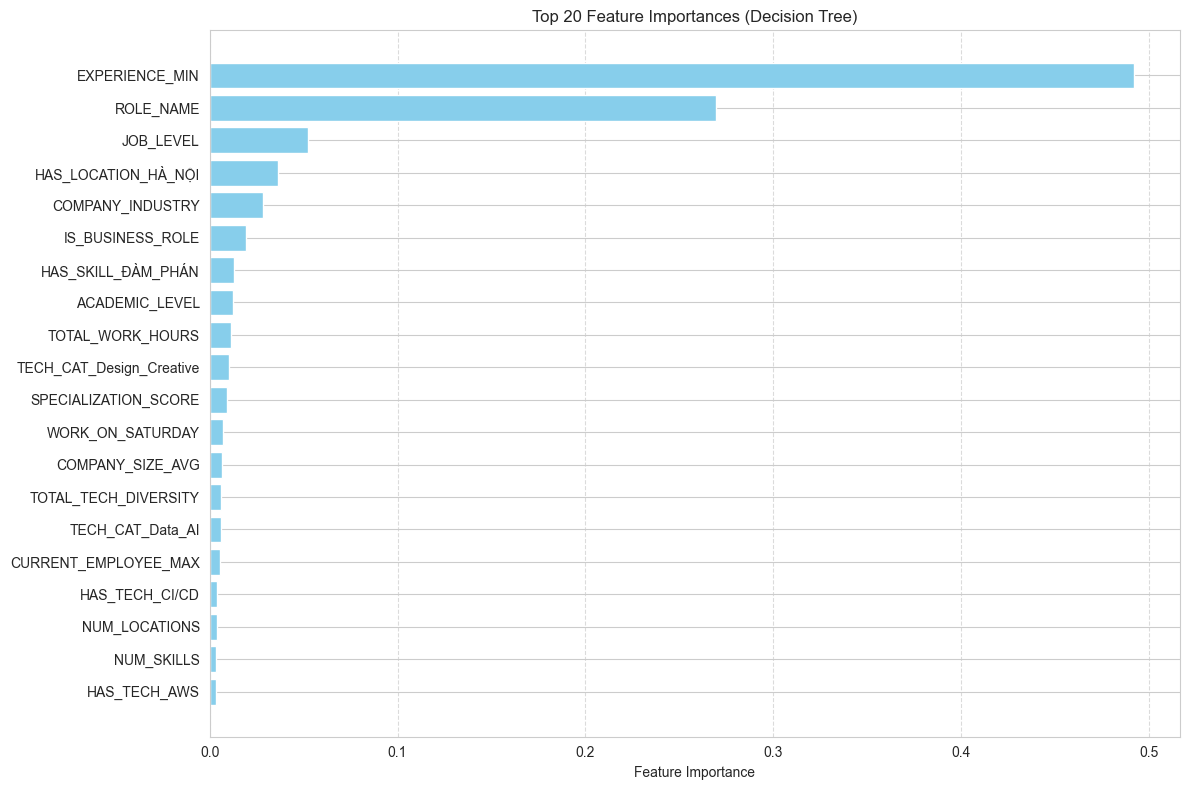

In [162]:
# 1. Định nghĩa hàm mục tiêu cho Optuna
def objective_dt(trial):
    # --- Định nghĩa không gian tìm kiếm (Search Space) ---
    param = {
        'random_state': 42,
        'criterion': 'squared_error', # Tối ưu cho RMSE
        
        # Độ sâu của cây (Rất quan trọng)
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        
        # Kiểm soát việc chia nhánh để tránh Overfitting
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 100),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),
        
        # Số lượng feature được dùng (giống Random Forest nhưng cho 1 cây)
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
    }

    # --- Khởi tạo và Train model ---
    model = DecisionTreeRegressor(**param)
    
    # Train trên tập TRAIN
    model.fit(X_train, y_train)
    
    # --- Đánh giá trên tập DEV ---
    # Optuna sẽ dựa vào kết quả trên tập Dev để biết bộ tham số này tốt hay xấu
    preds = model.predict(X_dev)
    rmse = np.sqrt(mean_squared_error(y_dev, preds))
    
    return rmse

# 2. Chạy Optuna
print("="*80)
print("STARTING OPTUNA FOR DECISION TREE")
print("="*80)

study_dt = optuna.create_study(direction='minimize') # Mục tiêu: Giảm thiểu RMSE
study_dt.optimize(objective_dt, n_trials=100) # Chạy thử 50 lần

# 3. In kết quả tốt nhất
print("\n" + "="*80)
print("OPTUNA RESULTS")
print("="*80)
print(f"Best RMSE on Dev Set: {study_dt.best_value:,.0f} VND")
print("Best Hyperparameters:")
for key, value in study_dt.best_params.items():
    print(f"  - {key}: {value}")

# 4. Huấn luyện lại model cuối cùng với tham số tốt nhất
print("\n" + "="*80)
print("TRAINING FINAL MODEL")
print("="*80)

best_params_dt = study_dt.best_params
best_params_dt['random_state'] = 42

final_dt_model = DecisionTreeRegressor(**best_params_dt)
final_dt_model.fit(X_train, y_train)

# 5. Đánh giá trên tập TEST (Tập chưa từng nhìn thấy)
print("\nFINAL EVALUATION ON TEST SET")
y_test_pred = final_dt_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

print(f"Test RMSE: {test_rmse:,.0f} VND")
print(f"Test R²:   {test_r2:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")

# 6. Vẽ biểu đồ Feature Importance (Decision Tree rất mạnh khoản này)
feature_importances = final_dt_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[-20:] # Lấy top 20

plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align='center', color='skyblue')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances (Decision Tree)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.2 Random Forest

[I 2026-01-03 22:07:56,976] A new study created in memory with name: no-name-2d4b218b-16e7-4893-864b-0db4d65bf1fa


STARTING ADVANCED OPTUNA FOR RANDOM FOREST
Note: Quá trình này có thể mất vài phút tùy vào cấu hình máy...


[I 2026-01-03 22:07:57,395] Trial 0 finished with value: 4205308.88908631 and parameters: {'n_estimators': 200, 'max_depth': 31, 'min_samples_split': 10, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'bootstrap': True, 'max_samples': 0.8280946680099308}. Best is trial 0 with value: 4205308.88908631.
[I 2026-01-03 22:07:58,276] Trial 1 finished with value: 4149188.1768973717 and parameters: {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True, 'max_samples': 0.537577632910736}. Best is trial 1 with value: 4149188.1768973717.
[I 2026-01-03 22:07:58,276] Trial 1 finished with value: 4149188.1768973717 and parameters: {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True, 'max_samples': 0.537577632910736}. Best is trial 1 with value: 4149188.1768973717.
[I 2026-01-03 22:07:58,824] Trial 2 finished with value: 4404801.804688369 and parameters


OPTUNA RESULTS (Random Forest)
Best RMSE on Dev Set: 3,920,146 VND
Best Hyperparameters:
  - n_estimators: 450
  - max_depth: 16
  - min_samples_split: 17
  - min_samples_leaf: 2
  - max_features: None
  - bootstrap: True
  - max_samples: 0.6125998467065159

TRAINING FINAL RANDOM FOREST MODEL

FINAL EVALUATION ON TEST SET

FINAL EVALUATION ON TEST SET
Test RMSE: 4,298,862 VND
Test R²:   0.3889 (Train R²: 0.6747)
Test MAPE: 23.68%
Test RMSE: 4,298,862 VND
Test R²:   0.3889 (Train R²: 0.6747)
Test MAPE: 23.68%


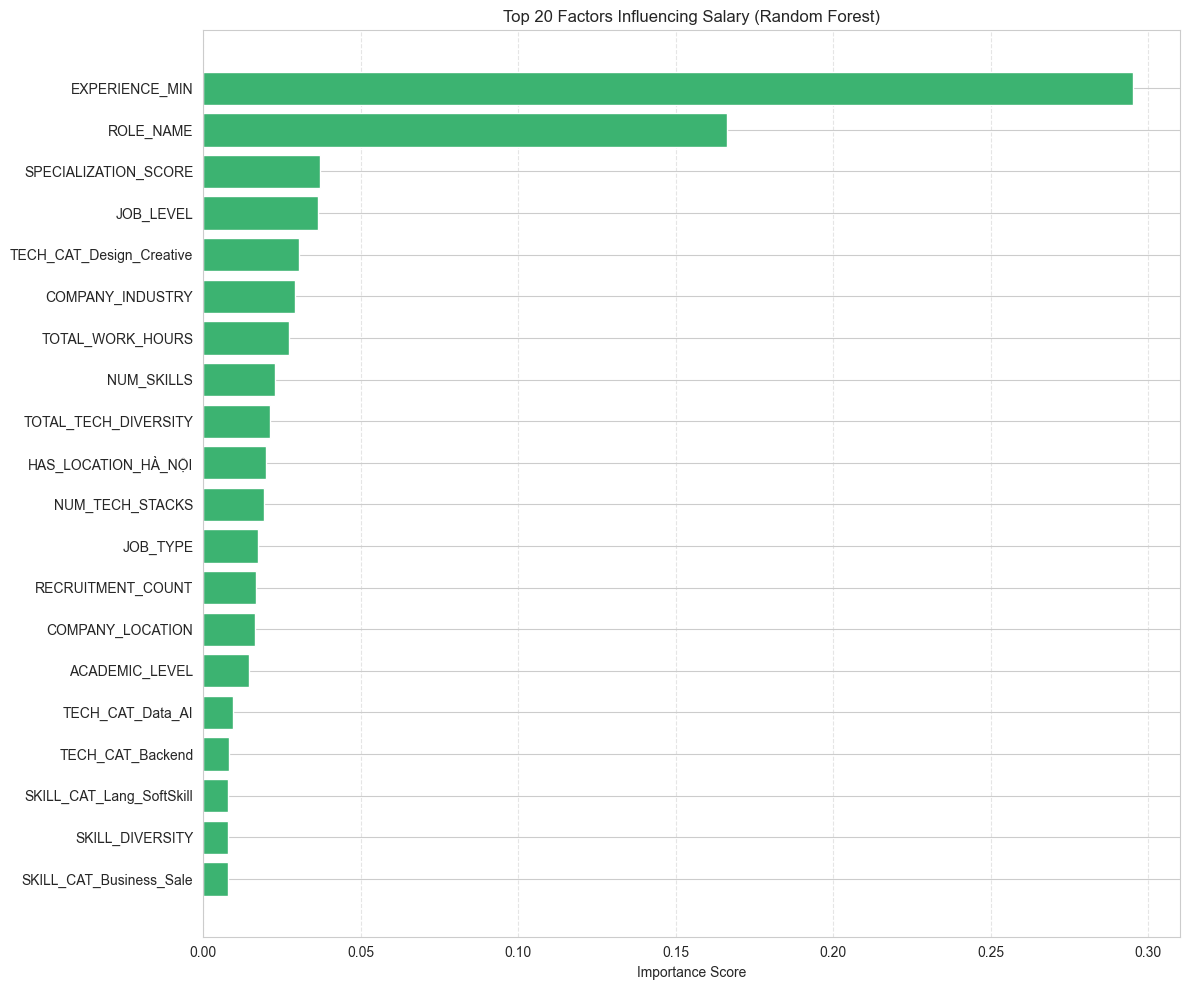

In [163]:
# 1. Định nghĩa hàm mục tiêu chi tiết cho Random Forest
def objective_rf_detailed(trial):
    # --- KHÔNG GIAN TÌM KIẾM CHI TIẾT (DETAILED SEARCH SPACE) ---
    param = {
        'random_state': 42,
        'n_jobs': -1,  # Sử dụng 100% CPU để chạy nhanh hơn
        'criterion': 'squared_error', # Tối ưu cho RMSE
        
        # 1. Số lượng cây: Thử từ ít đến nhiều để tìm điểm cân bằng giữa độ chính xác và tốc độ
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        
        # 2. Cấu trúc cây: Kiểm soát độ phức tạp
        # Cho phép cây sâu hơn Decision Tree vì RF khó bị overfit hơn
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        
        # Cắt tỉa nhánh chi tiết hơn
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        
        # 3. Sự đa dạng (Randomness) - Yếu tố quan trọng của Random Forest
        # Số feature tối đa được xét tại mỗi nút (căn bậc 2 hoặc log2 của tổng số feature)
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        
        # Có lấy mẫu lặp lại (Bootstrap) hay không?
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
    }

    # Nếu dùng Bootstrap = True, ta có thể chỉnh thêm tỷ lệ lấy mẫu (max_samples)
    # Ví dụ: Chỉ train mỗi cây trên 70-90% dữ liệu để tăng tính tổng quát hóa
    if param['bootstrap']:
        param['max_samples'] = trial.suggest_float('max_samples', 0.5, 1.0)

    # --- Khởi tạo và Train model ---
    model = RandomForestRegressor(**param)
    
    # Train trên tập TRAIN
    model.fit(X_train, y_train)
    
    # --- Đánh giá trên tập DEV ---
    # Mục tiêu: Giảm thiểu sai số trên tập Dev
    preds = model.predict(X_dev)
    rmse = np.sqrt(mean_squared_error(y_dev, preds))
    
    return rmse

# 2. Chạy Optuna (Lưu ý: Random Forest chạy lâu hơn DT nhiều)
print("="*80)
print("STARTING ADVANCED OPTUNA FOR RANDOM FOREST")
print("="*80)
print("Note: Quá trình này có thể mất vài phút tùy vào cấu hình máy...")

# Tạo study mới
study_rf = optuna.create_study(direction='minimize')


study_rf.optimize(objective_rf_detailed, n_trials=100) 

# 3. In kết quả tốt nhất
print("\n" + "="*80)
print("OPTUNA RESULTS (Random Forest)")
print("="*80)
print(f"Best RMSE on Dev Set: {study_rf.best_value:,.0f} VND")
print("Best Hyperparameters:")
for key, value in study_rf.best_params.items():
    print(f"  - {key}: {value}")

# 4. Huấn luyện lại model cuối cùng (Final Retrain)
print("\n" + "="*80)
print("TRAINING FINAL RANDOM FOREST MODEL")
print("="*80)

# Lấy tham số tốt nhất
best_params_rf = study_rf.best_params
best_params_rf['random_state'] = 42
best_params_rf['n_jobs'] = -1

final_rf_model = RandomForestRegressor(**best_params_rf)
final_rf_model.fit(X_train, y_train)

# 5. Đánh giá trên tập TEST (Chưa từng nhìn thấy)
print("\nFINAL EVALUATION ON TEST SET")
y_test_pred = final_rf_model.predict(X_test)

# Tính toán các chỉ số
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

# So sánh Train vs Test để check Overfitting
y_train_pred = final_rf_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Test RMSE: {test_rmse:,.0f} VND")
print(f"Test R²:   {test_r2:.4f} (Train R²: {train_r2:.4f})")
print(f"Test MAPE: {test_mape:.2f}%")

if train_r2 - test_r2 > 0.15:
    print("WARNING: Potential Overfitting detected (Train R² significantly higher than Test R²).")
else:
    print("Good Fit: Train and Test performance are quite similar.")

# 6. Feature Importance Plot (Top 20)
feature_importances = final_rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[-20:]

plt.figure(figsize=(12, 10))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align='center', color='mediumseagreen')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.xlabel('Importance Score')
plt.title('Top 20 Factors Influencing Salary (Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 5.3 Gradient Boosting

[I 2026-01-03 22:10:04,369] A new study created in memory with name: no-name-700817e0-8bf1-493d-b5a3-2e35ecae6a0b


STARTING OPTUNA FOR GRADIENT BOOSTING


[I 2026-01-03 22:10:25,204] Trial 0 finished with value: 3978441.417049924 and parameters: {'n_estimators': 250, 'learning_rate': 0.050745830056176715, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 7, 'subsample': 0.608414852821357, 'max_features': None}. Best is trial 0 with value: 3978441.417049924.
[I 2026-01-03 22:10:29,710] Trial 1 finished with value: 4083002.609416149 and parameters: {'n_estimators': 1000, 'learning_rate': 0.04152575314516456, 'max_depth': 4, 'min_samples_split': 16, 'min_samples_leaf': 4, 'subsample': 0.631849668958319, 'max_features': 'log2'}. Best is trial 0 with value: 3978441.417049924.
[I 2026-01-03 22:10:29,710] Trial 1 finished with value: 4083002.609416149 and parameters: {'n_estimators': 1000, 'learning_rate': 0.04152575314516456, 'max_depth': 4, 'min_samples_split': 16, 'min_samples_leaf': 4, 'subsample': 0.631849668958319, 'max_features': 'log2'}. Best is trial 0 with value: 3978441.417049924.
[I 2026-01-03 22:10:35,796] Trial 2 finish


OPTUNA RESULTS (Gradient Boosting)
Best RMSE on Dev Set: 3,870,110 VND
Best Params:
  - n_estimators: 300
  - learning_rate: 0.011362813443120017
  - max_depth: 9
  - min_samples_split: 18
  - min_samples_leaf: 12
  - subsample: 0.8202749455960754
  - max_features: None

TRAINING FINAL GRADIENT BOOSTING MODEL

FINAL EVALUATION ON TEST SET
Test RMSE: 4,246,748 VND
Test R²:   0.4037 (Train R²: 0.7703)
Test MAPE: 23.11%
Cảnh báo: Overfitting nặng! Cần giảm max_depth hoặc subsample.

FINAL EVALUATION ON TEST SET
Test RMSE: 4,246,748 VND
Test R²:   0.4037 (Train R²: 0.7703)
Test MAPE: 23.11%
Cảnh báo: Overfitting nặng! Cần giảm max_depth hoặc subsample.


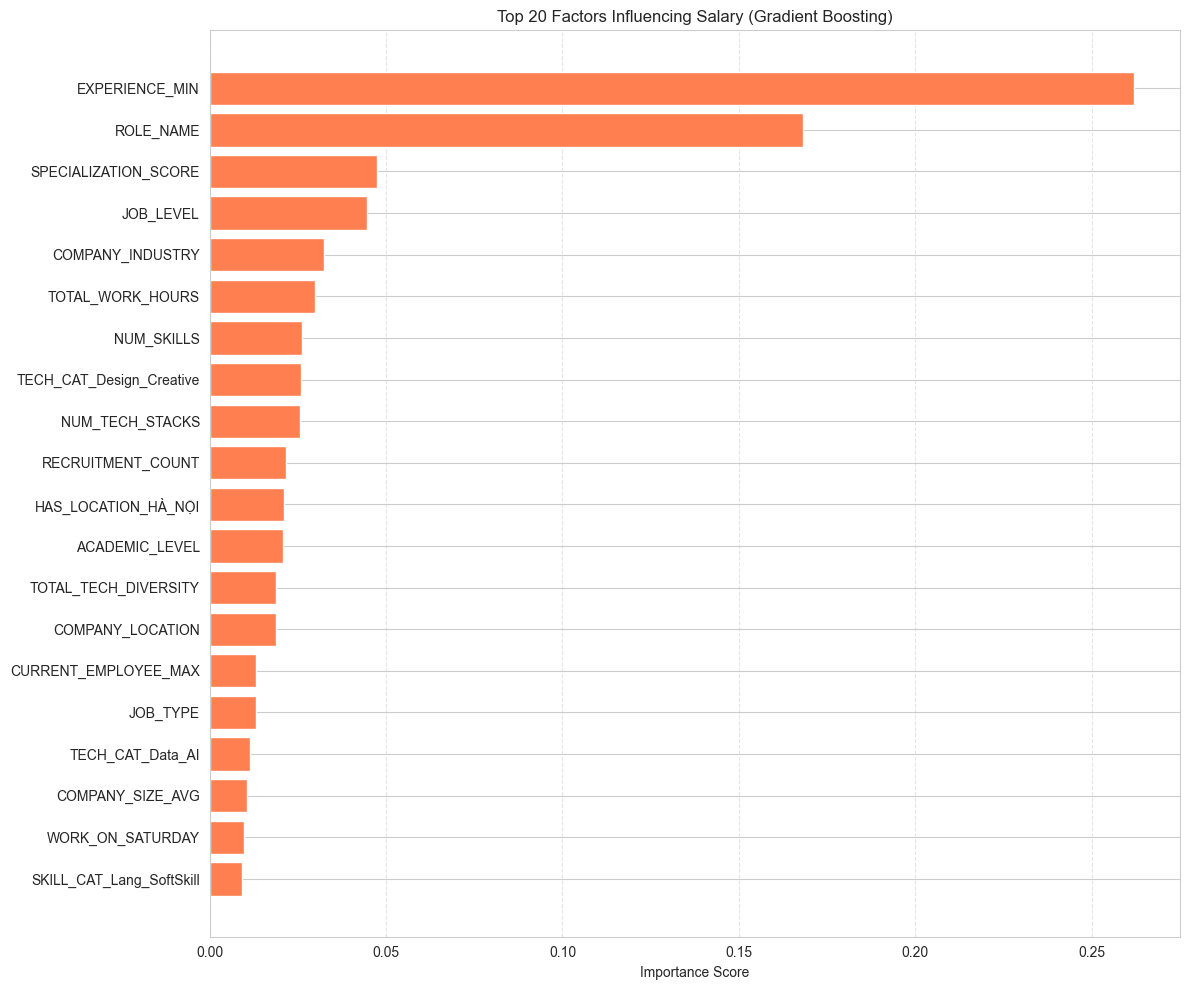

In [164]:
def objective_gbr(trial):
    # --- KHÔNG GIAN TÌM KIẾM CHI TIẾT ---
    param = {
        'random_state': 42,
        'loss': 'squared_error', # Tối ưu hóa RMSE
        
        # 1. Cặp bài trùng: Learning Rate & N_Estimators
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        
        # 2. Cấu trúc cây (Boosting thường dùng cây nông hơn RF)
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        
        # 3. Stochastic Gradient Boosting (Chống Overfit)
        # Tỷ lệ mẫu dùng để train từng cây
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        
        # Số feature tối đa cho mỗi cây
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    # --- Khởi tạo và Train model ---
    model = GradientBoostingRegressor(**param)
    
    model.fit(X_train, y_train)
    
    # --- Đánh giá trên tập DEV ---
    preds = model.predict(X_dev)
    rmse = np.sqrt(mean_squared_error(y_dev, preds))
    
    return rmse

# 2. Chạy Optuna
print("="*80)
print("STARTING OPTUNA FOR GRADIENT BOOSTING")
print("="*80)

# Gradient Boosting chạy lâu hơn RF nếu n_estimators lớn, hãy kiên nhẫn
study_gbr = optuna.create_study(direction='minimize')
study_gbr.optimize(objective_gbr, n_trials=100) 

# 3. In kết quả tốt nhất
print("\n" + "="*80)
print("OPTUNA RESULTS (Gradient Boosting)")
print("="*80)
print(f"Best RMSE on Dev Set: {study_gbr.best_value:,.0f} VND")
print("Best Params:")
for k, v in study_gbr.best_params.items():
    print(f"  - {k}: {v}")

# 4. Train Final GBR Model
print("\n" + "="*80)
print("TRAINING FINAL GRADIENT BOOSTING MODEL")
print("="*80)

best_params_gbr = study_gbr.best_params
best_params_gbr['random_state'] = 42

final_gbr_model = GradientBoostingRegressor(**best_params_gbr)
final_gbr_model.fit(X_train, y_train)

# 5. Final Evaluation
print("\nFINAL EVALUATION ON TEST SET")
y_test_pred = final_gbr_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

# So sánh với Train để check Overfit
y_train_pred = final_gbr_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Test RMSE: {test_rmse:,.0f} VND")
print(f"Test R²:   {test_r2:.4f} (Train R²: {train_r2:.4f})")
print(f"Test MAPE: {test_mape:.2f}%")

if train_r2 - test_r2 > 0.15:
    print("Cảnh báo: Overfitting nặng! Cần giảm max_depth hoặc subsample.")
else:
    print("Good Fit: Mô hình tổng quát hóa tốt.")

# 6. Feature Importance
feature_importances = final_gbr_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[-20:]

plt.figure(figsize=(12, 10))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align='center', color='coral')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.xlabel('Importance Score')
plt.title('Top 20 Factors Influencing Salary (Gradient Boosting)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 5.4 XGBoost

[I 2026-01-03 22:20:13,895] A new study created in memory with name: no-name-a1ec6410-57e1-411f-a589-1a0a83e4a2ac


STARTING OPTUNA (PENALIZED MODE)


[I 2026-01-03 22:20:15,726] Trial 0 finished with value: 4139279.4098819126 and parameters: {'n_estimators': 400, 'learning_rate': 0.010829685468357808, 'max_depth': 5, 'min_child_weight': 26, 'reg_alpha': 94.43304439056482, 'reg_lambda': 1.853745170498352, 'gamma': 9.105341282801557, 'subsample': 0.5431429179581357, 'colsample_bytree': 0.7183370593538039}. Best is trial 0 with value: 4139279.4098819126.
[I 2026-01-03 22:20:18,702] Trial 1 finished with value: 4110298.3751989566 and parameters: {'n_estimators': 650, 'learning_rate': 0.008260193724339875, 'max_depth': 4, 'min_child_weight': 14, 'reg_alpha': 10.828055321411105, 'reg_lambda': 17.684029762128993, 'gamma': 6.665017431847872, 'subsample': 0.7002293172628907, 'colsample_bytree': 0.5325031837136233}. Best is trial 1 with value: 4110298.3751989566.
[I 2026-01-03 22:20:18,702] Trial 1 finished with value: 4110298.3751989566 and parameters: {'n_estimators': 650, 'learning_rate': 0.008260193724339875, 'max_depth': 4, 'min_child_we


OPTUNA RESULTS
Best Penalized Score: 4,052,666
Best Params:
  - n_estimators: 550
  - learning_rate: 0.015008179419133355
  - max_depth: 4
  - min_child_weight: 43
  - reg_alpha: 1.3993560913922598
  - reg_lambda: 1.8499347721285024
  - gamma: 2.647754905426806
  - subsample: 0.775101204343784
  - colsample_bytree: 0.5907774742706435

TRAINING FINAL XGBOOST MODEL

FINAL EVALUATION ON TEST SET
Test RMSE: 4,276,123 VND
Test R2:   0.3954
Train R2:  0.5562
Gap R2:    0.1608
Test MAPE: 23.72%

FINAL EVALUATION ON TEST SET
Test RMSE: 4,276,123 VND
Test R2:   0.3954
Train R2:  0.5562
Gap R2:    0.1608
Test MAPE: 23.72%


<Figure size 1200x1000 with 0 Axes>

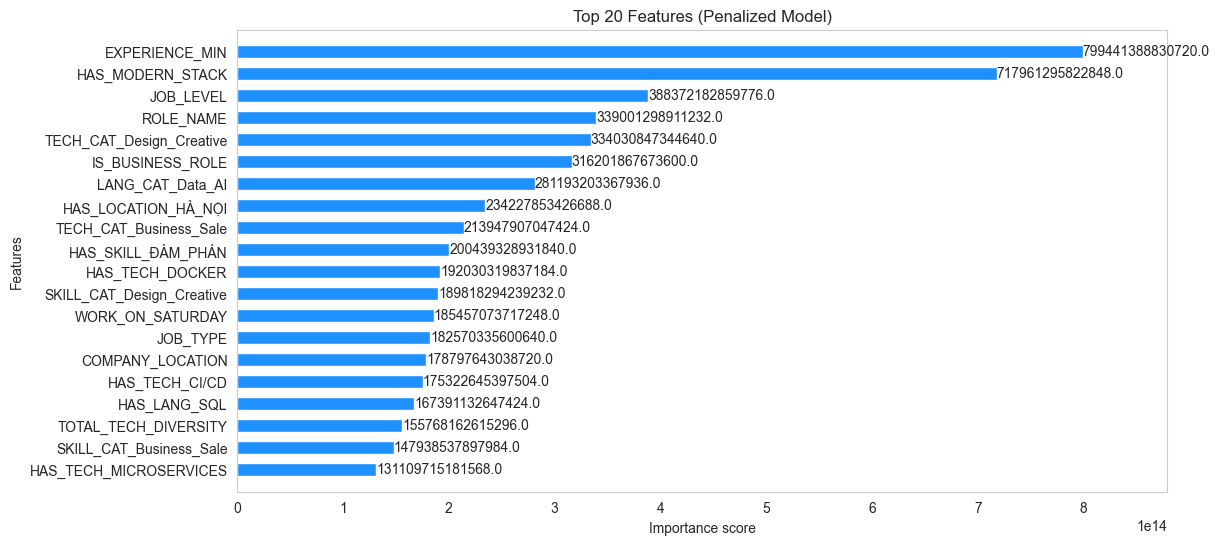

In [165]:
def objective_xgb_penalized(trial):
    # --- PHAN 1: KHONG GIAN TIM KIEM KHAT KHE HON ---
    param = {
        'verbosity': 0,
        'objective': 'reg:squarederror',
        'random_state': 42,
        'n_jobs': -1,
        'tree_method': 'hist',
        
        # Gioi han so cay va toc do hoc
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        
        # [QUAN TRONG] Ep cay phai nong (max_depth thap)
        'max_depth': trial.suggest_int('max_depth', 2, 5), 
        
        # [QUAN TRONG] Ep moi nhanh phai co nhieu du lieu (min_child_weight cao)
        # Tang tu 2->15 len thanh 10->50 de tranh hoc cac mau ca biet
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 50),
        
        # Regularization manh tay hon (Bat dau tu 1.0 thay vi 0.01)
        'reg_alpha': trial.suggest_float('reg_alpha', 1.0, 100.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 100.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.5, 10.0),
        
        # Lay mau it hon de tang tinh ngau nhien
        'subsample': trial.suggest_float('subsample', 0.5, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8),
        
        # Early stopping
        'early_stopping_rounds': 50
    }

    model = xgb.XGBRegressor(**param)
    
    # Train model
    model.fit(
        X_train, y_train,
        eval_set=[(X_dev, y_dev)],
        verbose=False
    )
    
    # --- PHAN 2: TINH TOAN DIEM SO VA DIEM PHAT ---
    
    # Du doan tren ca Dev va Train
    preds_dev = model.predict(X_dev)
    preds_train = model.predict(X_train)
    
    rmse_dev = np.sqrt(mean_squared_error(y_dev, preds_dev))
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    
    # Tinh do lech (Gap) giua Train va Dev
    overfit_gap = rmse_dev - rmse_train
    
    # Neu Gap < 0 (Dev tot hon Train - hiem gap) thi coi nhu 0
    overfit_gap = max(0, overfit_gap)
    
    # [CO CHE PHAT]: Custom Loss = RMSE_Dev + (He so * Gap)
    # He so 0.5 nghia la: Cu moi 1 dong lech giua Train/Dev, ta phat them 0.5 dong vao ket qua
    # Dieu nay buoc Optuna phai tim model vua tot, vua khong duoc lech nhieu
    final_score = rmse_dev + (0.5 * overfit_gap)
    
    return final_score

# 2. Chay Optuna
print("="*80)
print("STARTING OPTUNA (PENALIZED MODE)")
print("="*80)

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb_penalized, n_trials=50)

# 3. Ket qua
print("\n" + "="*80)
print("OPTUNA RESULTS")
print("="*80)
# Luu y: best_value o day la diem da bi phat (Final Score), khong phai RMSE thuan
print(f"Best Penalized Score: {study_xgb.best_value:,.0f}")
print("Best Params:")
for k, v in study_xgb.best_params.items():
    print(f"  - {k}: {v}")

# 4. Train Final Model
print("\n" + "="*80)
print("TRAINING FINAL XGBOOST MODEL")
print("="*80)

best_params_xgb = study_xgb.best_params
best_params_xgb['random_state'] = 42
best_params_xgb['n_jobs'] = -1
best_params_xgb['objective'] = 'reg:squarederror'
best_params_xgb['tree_method'] = 'hist'

if 'early_stopping_rounds' in best_params_xgb:
    del best_params_xgb['early_stopping_rounds']

final_xgb_model = xgb.XGBRegressor(**best_params_xgb)
final_xgb_model.fit(X_train, y_train)

# 5. Final Eval
print("\nFINAL EVALUATION ON TEST SET")
y_test_pred = final_xgb_model.predict(X_test)
y_train_pred = final_xgb_model.predict(X_train)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

print(f"Test RMSE: {test_rmse:,.0f} VND")
print(f"Test R2:   {test_r2:.4f}")
print(f"Train R2:  {train_r2:.4f}")
print(f"Gap R2:    {train_r2 - test_r2:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")

if train_r2 - test_r2 > 0.15:
    print("WARNING: Still overfitting significantly.")
else:
    print("SUCCESS: Gap is controlled.")

# 6. Plot Importance
from xgboost import plot_importance
plt.figure(figsize=(12, 10))
plot_importance(final_xgb_model, max_num_features=20, importance_type='gain', height=0.6, grid=False, color='dodgerblue')
plt.title('Top 20 Features (Penalized Model)')
plt.show()

### 5.5 LightGBM

#### Có chuẩn hoá categorical features

[I 2026-01-03 22:21:44,210] A new study created in memory with name: no-name-ee152231-fa59-4db5-9bc0-e0bca7b13e0a


STARTING OPTUNA FOR LIGHTGBM


[I 2026-01-03 22:21:45,197] Trial 0 finished with value: 3934521.872867651 and parameters: {'n_estimators': 550, 'learning_rate': 0.0065327636088360974, 'num_leaves': 28, 'max_depth': 8, 'min_child_samples': 35, 'reg_alpha': 6.879173968735305, 'reg_lambda': 12.527232293117448, 'subsample': 0.7914985738664142, 'colsample_bytree': 0.7254395970783301}. Best is trial 0 with value: 3934521.872867651.
[I 2026-01-03 22:21:46,851] Trial 1 finished with value: 3914015.8008349156 and parameters: {'n_estimators': 950, 'learning_rate': 0.033943897259176944, 'num_leaves': 31, 'max_depth': 8, 'min_child_samples': 36, 'reg_alpha': 0.017093328596658516, 'reg_lambda': 99.1075924192679, 'subsample': 0.7969835405568748, 'colsample_bytree': 0.6992664112755708}. Best is trial 1 with value: 3914015.8008349156.
[I 2026-01-03 22:21:46,851] Trial 1 finished with value: 3914015.8008349156 and parameters: {'n_estimators': 950, 'learning_rate': 0.033943897259176944, 'num_leaves': 31, 'max_depth': 8, 'min_child_sa


OPTUNA RESULTS
Best RMSE on Dev Set: 3,875,981 VND
Best Params:
  - n_estimators: 750
  - learning_rate: 0.05615085738797739
  - num_leaves: 21
  - max_depth: 9
  - min_child_samples: 39
  - reg_alpha: 10.535072993890777
  - reg_lambda: 1.4134311855040713
  - subsample: 0.7174632884101625
  - colsample_bytree: 0.8206661255095666

TRAINING FINAL LIGHTGBM MODEL

FINAL EVALUATION ON TEST SET
Test RMSE: 4,471,755 VND
Test R2:   0.3388
Train R2:  0.9134
Gap R2:    0.5746
Test MAPE: 23.84%

Plotting Feature Importance...

FINAL EVALUATION ON TEST SET
Test RMSE: 4,471,755 VND
Test R2:   0.3388
Train R2:  0.9134
Gap R2:    0.5746
Test MAPE: 23.84%

Plotting Feature Importance...


<Figure size 1200x1000 with 0 Axes>

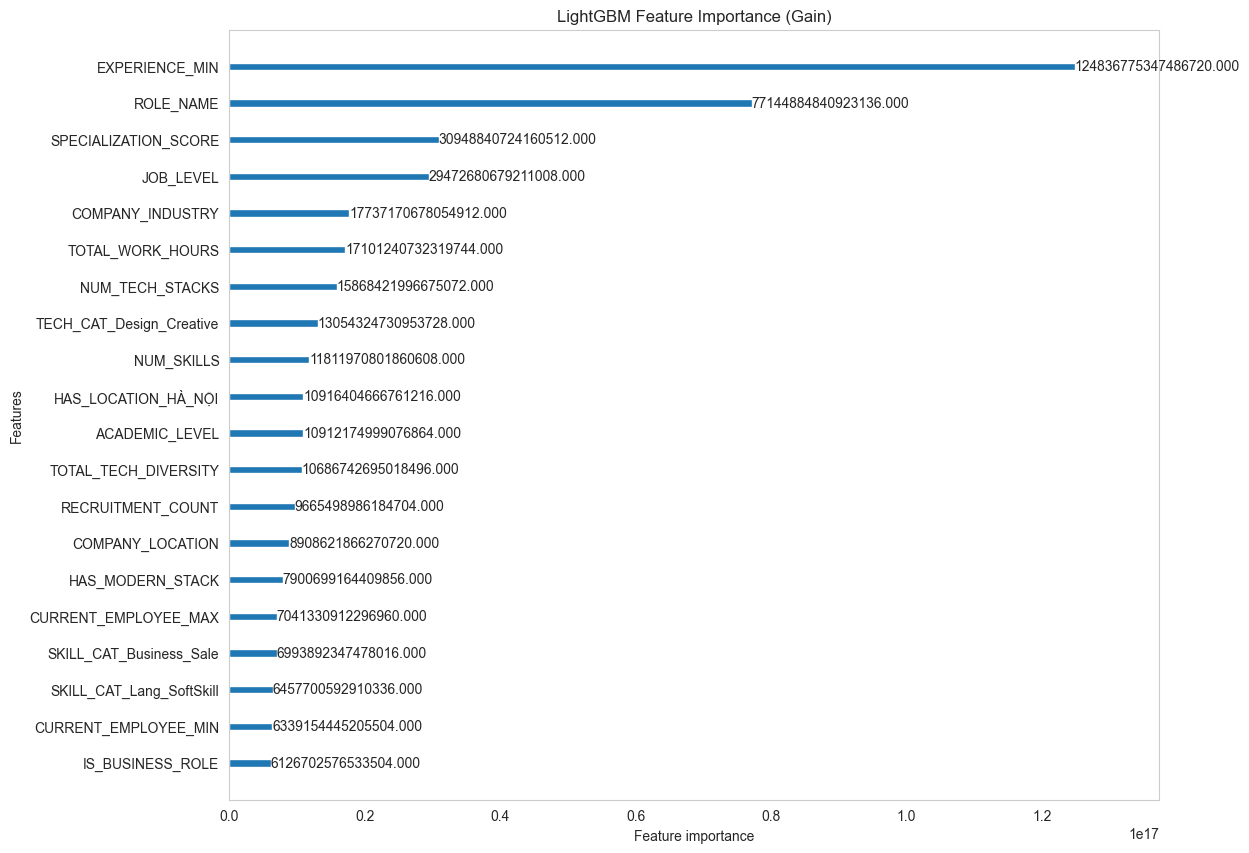

In [166]:
def objective_lgbm(trial):
    # Dinh nghia khong gian tim kiem
    # LightGBM phat trien cay theo chieu ngang (Leaf-wise), de bi Overfitting voi du lieu nho
    # Nen ta can kiem soat chat num_leaves va min_child_samples
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_jobs': -1,
        
        # --- Search Space ---
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        
        # [QUAN TRONG] So luong la toi da tren mot cay
        # Voi du lieu it, nen giu nho (< 50) de tranh hoc thuoc long
        'num_leaves': trial.suggest_int('num_leaves', 20, 50),
        
        # Gioi han do sau cua cay
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        
        # [QUAN TRONG] So luong data toi thieu trong mot la
        # Tang len cao (20-100) de dam bao moi nhanh du la dai dien cho mot nhom lon
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        
        # Regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 100.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 100.0, log=True),
        
        # Sampling
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
    }

    model = lgb.LGBMRegressor(**param)
    
    # Su dung callbacks cho early stopping (cach chuan cho LightGBM phien ban moi)
    callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_dev, y_dev)],
        eval_metric='rmse',
        callbacks=callbacks
    )
    
    # Du doan tren Dev
    preds = model.predict(X_dev)
    rmse = np.sqrt(mean_squared_error(y_dev, preds))
    
    return rmse

# 2. Chay Optuna
print("="*80)
print("STARTING OPTUNA FOR LIGHTGBM")
print("="*80)

study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=50)

# 3. Ket qua Optuna
print("\n" + "="*80)
print("OPTUNA RESULTS")
print("="*80)
print(f"Best RMSE on Dev Set: {study_lgbm.best_value:,.0f} VND")
print("Best Params:")
for k, v in study_lgbm.best_params.items():
    print(f"  - {k}: {v}")

# 4. Train Final Model
print("\n" + "="*80)
print("TRAINING FINAL LIGHTGBM MODEL")
print("="*80)

best_params_lgbm = study_lgbm.best_params
best_params_lgbm['random_state'] = 42
best_params_lgbm['n_jobs'] = -1
best_params_lgbm['objective'] = 'regression'
best_params_lgbm['metric'] = 'rmse'
best_params_lgbm['verbosity'] = -1

final_lgbm_model = lgb.LGBMRegressor(**best_params_lgbm)
final_lgbm_model.fit(X_train, y_train)

# 5. Final Evaluation
print("\nFINAL EVALUATION ON TEST SET")
y_test_pred = final_lgbm_model.predict(X_test)
y_train_pred = final_lgbm_model.predict(X_train)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

print(f"Test RMSE: {test_rmse:,.0f} VND")
print(f"Test R2:   {test_r2:.4f}")
print(f"Train R2:  {train_r2:.4f}")
print(f"Gap R2:    {train_r2 - test_r2:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")


# 6. Plot Importance
print("\nPlotting Feature Importance...")
plt.figure(figsize=(12, 10))
lgb.plot_importance(final_lgbm_model, max_num_features=20, importance_type='gain', figsize=(12, 10), title='LightGBM Feature Importance (Gain)', grid=False)
plt.show()

#### Không chuẩn hoá categorical feature

\- Chỉnh sửa lại dữ liệu

1. Preparing raw data (Native Categorical Mode)...
Initial Shape: (3448, 112)

2. Splitting data into Train/Dev/Test...
Raw Split Sizes: Train=2412, Dev=518, Test=518

3. Calculating Outlier Thresholds (Based on Train Set)...
   - Rules derived from Train: 2,781,250 to 31,031,250 VND

4. Applying filters to Train, Dev, and Test...
   - Train: Kept 2,201 (Removed 211 outliers)
Initial Shape: (3448, 112)

2. Splitting data into Train/Dev/Test...
Raw Split Sizes: Train=2412, Dev=518, Test=518

3. Calculating Outlier Thresholds (Based on Train Set)...
   - Rules derived from Train: 2,781,250 to 31,031,250 VND

4. Applying filters to Train, Dev, and Test...
   - Train: Kept 2,201 (Removed 211 outliers)
   - Dev: Kept 469 (Removed 49 outliers)
   - Test: Kept 482 (Removed 36 outliers)

FINAL DATA DISTRIBUTION CHECK
        Train_Cat     Dev_Cat    Test_Cat
count       2,201         469         482
mean   16,938,369  16,885,048  16,950,740
std     5,340,411   5,318,832   5,504,998
min     3,0

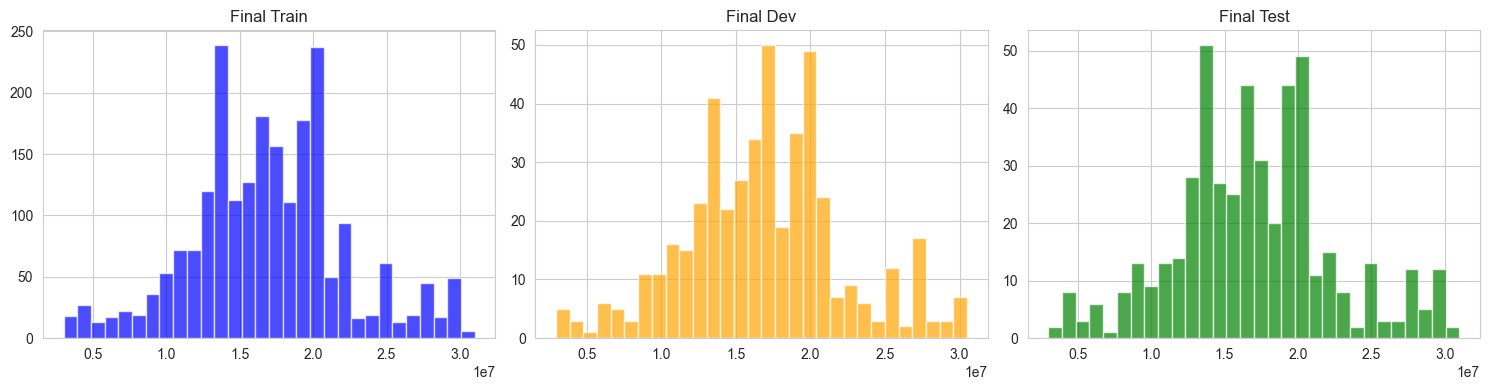


Ready for CatBoost Native Training!


In [167]:
print("1. Preparing raw data (Native Categorical Mode)...")

# Combine all features
all_features = numerical_features + categorical_features + boolean_features

# Create feature dataframe
X_cat = df_model[all_features].copy()
y_cat = df_model['SALARY_AVG'].copy()

# Handle missing values in numerical features
for col in numerical_features:
    if X_cat[col].isnull().sum() > 0:
        X_cat[col].fillna(X_cat[col].median(), inplace=True)

# Handle missing values in categorical features & Force String type
for col in categorical_features:
    # Convert to string first
    X_cat[col] = X_cat[col].astype(str)
    
    # Fill Unknown
    if X_cat[col].isnull().sum() > 0:
        X_cat[col].fillna('Unknown', inplace=True)
        
    # Double check string type for CatBoost
    X_cat[col] = X_cat[col].astype(str)

# Convert boolean to int
for col in boolean_features:
    X_cat[col] = X_cat[col].astype(int)

print(f"Initial Shape: {X_cat.shape}")

# ==============================================================================
# 2. SPLIT DATA (BEFORE FILTERING)
# ==============================================================================
print("\n2. Splitting data into Train/Dev/Test...")

# Create bins for stratification
try:
    salary_bins = pd.qcut(y_cat, q=10, labels=False, duplicates='drop')
except:
    salary_bins = pd.qcut(y_cat, q=5, labels=False, duplicates='drop')

# Split 1: Train+Dev vs Test (15%)
X_temp, X_test_raw, y_temp, y_test_raw = train_test_split(
    X_cat, y_cat,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=salary_bins
)

# Split 2: Train vs Dev (Total Dev approx 15%)
# Recalculate bins for temp
try:
    bins_temp = pd.qcut(y_temp, q=10, labels=False, duplicates='drop')
except:
    bins_temp = pd.qcut(y_temp, q=5, labels=False, duplicates='drop')

X_train_raw, X_dev_raw, y_train_raw, y_dev_raw = train_test_split(
    X_temp, y_temp,
    test_size=0.1765, # 15/85
    random_state=42,
    shuffle=True,
    stratify=bins_temp
)

print(f"Raw Split Sizes: Train={len(y_train_raw)}, Dev={len(y_dev_raw)}, Test={len(y_test_raw)}")

# ==============================================================================
# 3. CALCULATE OUTLIER THRESHOLDS (FROM TRAIN ONLY)
# ==============================================================================
print("\n3. Calculating Outlier Thresholds (Based on Train Set)...")

Q1 = y_train_raw.quantile(0.25)
Q3 = y_train_raw.quantile(0.75)
IQR = Q3 - Q1
multiplier = 1.5

lower_limit = max(0, Q1 - multiplier * IQR)
upper_limit = Q3 + multiplier * IQR

print(f"   - Rules derived from Train: {lower_limit:,.0f} to {upper_limit:,.0f} VND")

# ==============================================================================
# 4. APPLY FILTER TO ALL SETS
# ==============================================================================
print("\n4. Applying filters to Train, Dev, and Test...")

def apply_filter(X, y, lower, upper, name):
    mask = (y >= lower) & (y <= upper)
    X_clean = X[mask].copy()
    y_clean = y[mask].copy()
    removed = len(y) - len(y_clean)
    print(f"   - {name}: Kept {len(y_clean):,} (Removed {removed} outliers)")
    return X_clean, y_clean

# Tạo ra bộ biến cuối cùng để đưa vào model
X_train_cat, y_train_cat = apply_filter(X_train_raw, y_train_raw, lower_limit, upper_limit, "Train")
X_dev_cat, y_dev_cat     = apply_filter(X_dev_raw, y_dev_raw, lower_limit, upper_limit, "Dev")
X_test_cat, y_test_cat   = apply_filter(X_test_raw, y_test_raw, lower_limit, upper_limit, "Test")

# ==============================================================================
# 5. VERIFY DISTRIBUTION
# ==============================================================================
print("\n" + "="*80)
print("FINAL DATA DISTRIBUTION CHECK")
print("="*80)

stats = pd.DataFrame({
    'Train_Cat': y_train_cat.describe(),
    'Dev_Cat': y_dev_cat.describe(),
    'Test_Cat': y_test_cat.describe()
})
print(stats.applymap(lambda x: f"{x:,.0f}"))

# Vẽ biểu đồ nhanh để chắc chắn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(y_train_cat, bins=30, color='blue', alpha=0.7); axes[0].set_title('Final Train')
axes[1].hist(y_dev_cat, bins=30, color='orange', alpha=0.7); axes[1].set_title('Final Dev')
axes[2].hist(y_test_cat, bins=30, color='green', alpha=0.7); axes[2].set_title('Final Test')
plt.tight_layout()
plt.show()

print("\nReady for CatBoost Native Training!")

[I 2026-01-03 22:22:17,394] A new study created in memory with name: no-name-456b1a74-51ce-45b4-9abe-67ffe2d8bb6c


Converting object columns to 'category' dtype for LightGBM...
Data conversion complete. LightGBM can now use native categorical features.
STARTING OPTUNA FOR LIGHTGBM (NATIVE CATEGORICAL)


[I 2026-01-03 22:22:17,554] Trial 0 finished with value: 3884870.2932026465 and parameters: {'n_estimators': 850, 'learning_rate': 0.07230017211795764, 'num_leaves': 26, 'max_depth': 5, 'min_child_samples': 73, 'reg_alpha': 0.1088635783675344, 'reg_lambda': 5.167891199996151, 'subsample': 0.8201318549593538, 'colsample_bytree': 0.7159386505648094, 'cat_smooth': 17.882074253005683, 'cat_l2': 39.06458725967524}. Best is trial 0 with value: 3884870.2932026465.
[I 2026-01-03 22:22:17,691] Trial 1 finished with value: 3875251.2765513393 and parameters: {'n_estimators': 400, 'learning_rate': 0.057222666439739556, 'num_leaves': 75, 'max_depth': 5, 'min_child_samples': 87, 'reg_alpha': 2.3373773949025196, 'reg_lambda': 0.018003969255517758, 'subsample': 0.8939164597893099, 'colsample_bytree': 0.7725931055293378, 'cat_smooth': 13.20788120345449, 'cat_l2': 17.464203581789704}. Best is trial 1 with value: 3875251.2765513393.
[I 2026-01-03 22:22:17,691] Trial 1 finished with value: 3875251.2765513


OPTUNA RESULTS
Best RMSE on Dev Set: 3,798,080 VND
Best Params:
  - n_estimators: 650
  - learning_rate: 0.014537958046850413
  - num_leaves: 31
  - max_depth: 11
  - min_child_samples: 30
  - reg_alpha: 0.021482941593717428
  - reg_lambda: 14.898328272769575
  - subsample: 0.6468923011210956
  - colsample_bytree: 0.8601935954806004
  - cat_smooth: 3.7696588457989177
  - cat_l2: 6.266847766504176

TRAINING FINAL LIGHTGBM MODEL

FINAL EVALUATION ON TEST SET
Test RMSE: 4,230,374 VND
Test R2:   0.4082
Train R2:  0.7972
Gap R2:    0.3889
Test MAPE: 22.60%

Plotting Feature Importance...

FINAL EVALUATION ON TEST SET
Test RMSE: 4,230,374 VND
Test R2:   0.4082
Train R2:  0.7972
Gap R2:    0.3889
Test MAPE: 22.60%

Plotting Feature Importance...


<Figure size 1200x1000 with 0 Axes>

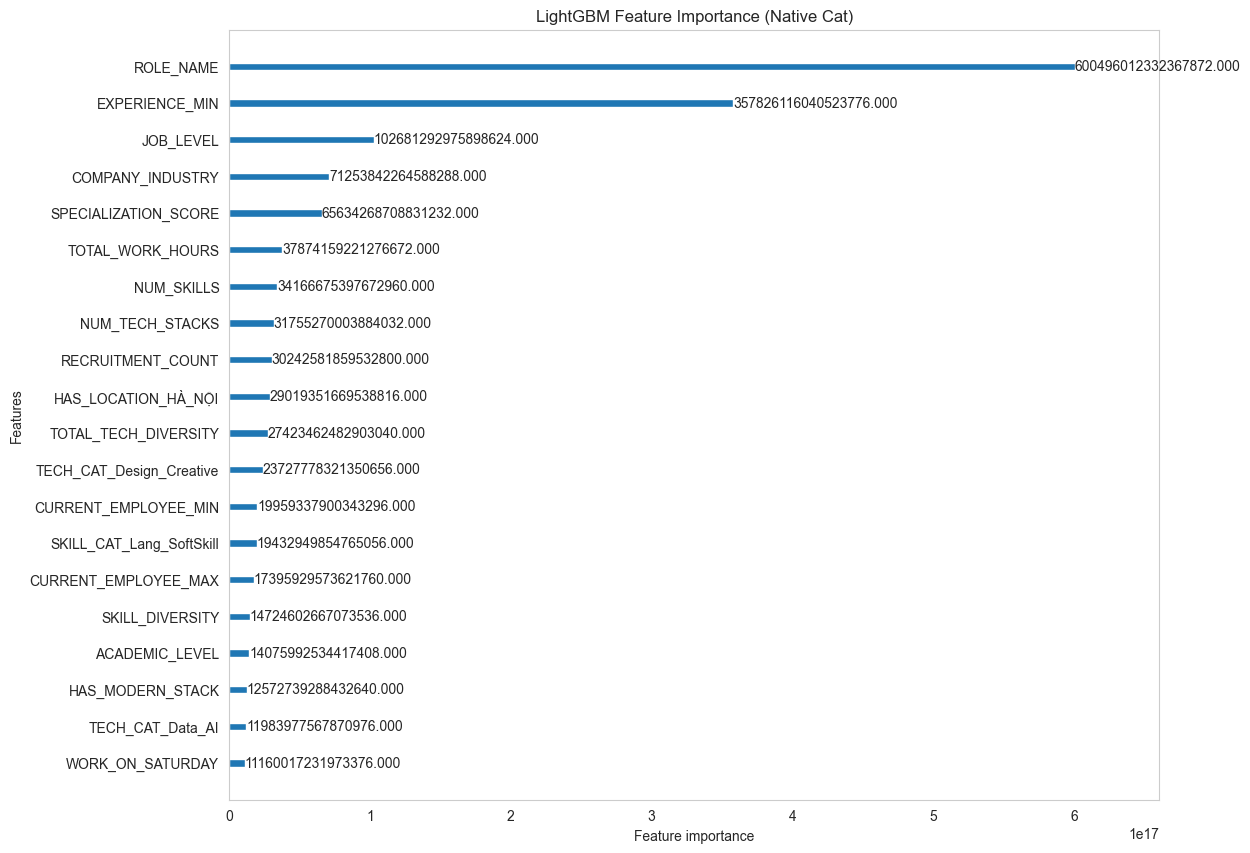

In [168]:
# --- BUOC 0: CHUYEN DOI KIEU DU LIEU (BAT BUOC CHO LIGHTGBM) ---
# LightGBM yeu cau cac cot category phai co kieu du lieu 'category' cua Pandas
# Thay vi 'object' hay 'string'
print("Converting object columns to 'category' dtype for LightGBM...")

# List cac cot can chuyen (lay tu list categorical_features ban da khai bao truoc do)
cols_to_convert = categorical_features

for col in cols_to_convert:
    X_train_cat[col] = X_train_cat[col].astype('category')
    X_dev_cat[col] = X_dev_cat[col].astype('category')
    X_test_cat[col] = X_test_cat[col].astype('category')

print("Data conversion complete. LightGBM can now use native categorical features.")

# 1. Dinh nghia ham muc tieu cho LightGBM (Dung tap du lieu _cat)
def objective_lgbm(trial):
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_jobs': -1,
        
        # --- Search Space ---
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100), # Tang len vi Native Category xu ly tot hon
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        
        # Regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 100.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 100.0, log=True),
        
        # Sampling
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        
        # [QUAN TRONG] Bat tinh nang xu ly category dac biet cua LightGBM
        # Giup xu ly tot cac bien co cardinality cao (nhieu gia tri duy nhat)
        'cat_smooth': trial.suggest_float('cat_smooth', 1.0, 50.0),
        'cat_l2': trial.suggest_float('cat_l2', 1.0, 50.0) 
    }

    model = lgb.LGBMRegressor(**param)
    
    callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
    
    # Truyen danh sach ten cot categorical vao fit
    # LightGBM se tu dong hieu va xu ly toi uu
    model.fit(
        X_train_cat, y_train_cat,
        eval_set=[(X_dev_cat, y_dev_cat)],
        eval_metric='rmse',
        callbacks=callbacks,
        categorical_feature=cols_to_convert # Chi dinh ro cac cot category
    )
    
    preds = model.predict(X_dev_cat)
    rmse = np.sqrt(mean_squared_error(y_dev_cat, preds))
    
    return rmse

# 2. Chay Optuna
print("="*80)
print("STARTING OPTUNA FOR LIGHTGBM (NATIVE CATEGORICAL)")
print("="*80)

study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=50)

# 3. Ket qua Optuna
print("\n" + "="*80)
print("OPTUNA RESULTS")
print("="*80)
print(f"Best RMSE on Dev Set: {study_lgbm.best_value:,.0f} VND")
print("Best Params:")
for k, v in study_lgbm.best_params.items():
    print(f"  - {k}: {v}")

# 4. Train Final Model
print("\n" + "="*80)
print("TRAINING FINAL LIGHTGBM MODEL")
print("="*80)

best_params_lgbm = study_lgbm.best_params
best_params_lgbm['random_state'] = 42
best_params_lgbm['n_jobs'] = -1
best_params_lgbm['objective'] = 'regression'
best_params_lgbm['metric'] = 'rmse'
best_params_lgbm['verbosity'] = -1

final_lgbm_model = lgb.LGBMRegressor(**best_params_lgbm)

# Fit voi categorical_feature
final_lgbm_model.fit(
    X_train_cat, y_train_cat,
    categorical_feature=cols_to_convert
)

# 5. Final Evaluation
print("\nFINAL EVALUATION ON TEST SET")
y_test_pred = final_lgbm_model.predict(X_test_cat)
y_train_pred = final_lgbm_model.predict(X_train_cat)

test_rmse = np.sqrt(mean_squared_error(y_test_cat, y_test_pred))
test_r2 = r2_score(y_test_cat, y_test_pred)
train_r2 = r2_score(y_train_cat, y_train_pred)
test_mape = mean_absolute_percentage_error(y_test_cat, y_test_pred) * 100

print(f"Test RMSE: {test_rmse:,.0f} VND")
print(f"Test R2:   {test_r2:.4f}")
print(f"Train R2:  {train_r2:.4f}")
print(f"Gap R2:    {train_r2 - test_r2:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")

if train_r2 - test_r2 > 0.15:
    print("WARNING: Overfitting detected.")
else:
    print("SUCCESS: Good generalization.")

# 6. Plot Importance
print("\nPlotting Feature Importance...")
plt.figure(figsize=(12, 10))
lgb.plot_importance(final_lgbm_model, max_num_features=20, importance_type='gain', figsize=(12, 10), title='LightGBM Feature Importance (Native Cat)', grid=False)
plt.show()

\- Kết quả tệ hơn nhiều

### 5.6 CatBoost

#### Có chuẩn hoá categorical features

[I 2026-01-03 22:23:15,323] A new study created in memory with name: no-name-52c0b081-e230-4b52-ad72-6d96c085abe4


STARTING OPTUNA FOR CATBOOST (ENCODED DATA)


[I 2026-01-03 22:23:22,733] Trial 0 finished with value: 4093554.7096351166 and parameters: {'iterations': 1200, 'learning_rate': 0.007966402566539299, 'depth': 8, 'l2_leaf_reg': 8.53687914640931, 'random_strength': 17.43199484614449, 'bagging_temperature': 0.19569602124728358, 'border_count': 78}. Best is trial 0 with value: 4093554.7096351166.
[I 2026-01-03 22:23:23,719] Trial 1 finished with value: 4139403.7655309457 and parameters: {'iterations': 700, 'learning_rate': 0.012865527764219809, 'depth': 5, 'l2_leaf_reg': 1.234466399982628, 'random_strength': 12.809580037018375, 'bagging_temperature': 0.3453816676567524, 'border_count': 120}. Best is trial 0 with value: 4093554.7096351166.
[I 2026-01-03 22:23:23,719] Trial 1 finished with value: 4139403.7655309457 and parameters: {'iterations': 700, 'learning_rate': 0.012865527764219809, 'depth': 5, 'l2_leaf_reg': 1.234466399982628, 'random_strength': 12.809580037018375, 'bagging_temperature': 0.3453816676567524, 'border_count': 120}. Be


OPTUNA RESULTS
Best RMSE on Dev Set: 3,906,289 VND
Best Params:
  - iterations: 1100
  - learning_rate: 0.047256728858977345
  - depth: 5
  - l2_leaf_reg: 4.563904632983214
  - random_strength: 13.36030808248228
  - bagging_temperature: 0.01421275054649277
  - border_count: 60

TRAINING FINAL CATBOOST MODEL
0:	learn: 5330871.9165425	test: 5303548.5449370	best: 5303548.5449370 (0)	total: 4.05ms	remaining: 4.45s
100:	learn: 4245028.9209958	test: 4316113.5309339	best: 4316113.5309339 (100)	total: 160ms	remaining: 1.58s
200:	learn: 3980906.8701486	test: 4121978.7956804	best: 4121978.7956804 (200)	total: 297ms	remaining: 1.33s
300:	learn: 3638579.8882456	test: 3971134.2985577	best: 3970857.7709610 (299)	total: 438ms	remaining: 1.16s
200:	learn: 3980906.8701486	test: 4121978.7956804	best: 4121978.7956804 (200)	total: 297ms	remaining: 1.33s
300:	learn: 3638579.8882456	test: 3971134.2985577	best: 3970857.7709610 (299)	total: 438ms	remaining: 1.16s
400:	learn: 3423332.9228721	test: 3942920.879

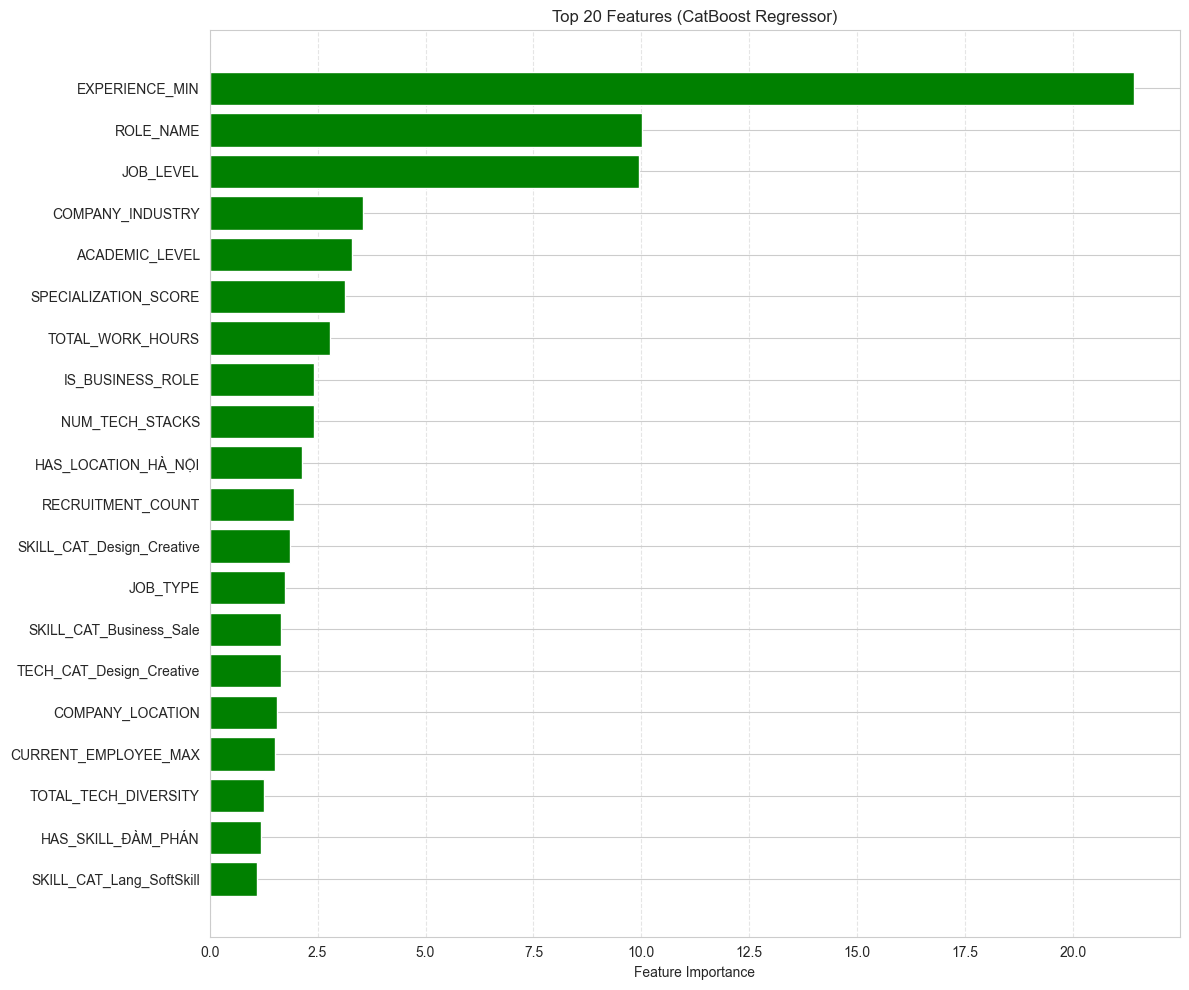

In [169]:
# 1. Dinh nghia ham muc tieu cho Optuna (CatBoost Regression)
def objective_cat(trial):
    # Khong gian tim kiem tham so
    param = {
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'task_type': 'CPU', 
        'random_seed': 42,
        'verbose': False,
        'allow_writing_files': False,
        
        # --- Search Space ---
        'iterations': trial.suggest_int('iterations', 500, 1500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        
        # Do sau cua cay (CatBoost thuong hieu qua voi cay doi xung nong hon XGBoost)
        'depth': trial.suggest_int('depth', 4, 10),
        
        # L2 Regularization (Quan trong de chong Overfit)
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        
        # Random Strength: Them nhieu vao cau truc cay de tranh nhieu
        'random_strength': trial.suggest_float('random_strength', 1, 20),
        
        # Bagging (Lay mau Bayesian)
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        
        # Border count: So luong diem cat cho feature so (giam xuong de tranh Overfit)
        'border_count': trial.suggest_int('border_count', 32, 128),
    }

    model = CatBoostRegressor(**param)
    
    # Train voi Early Stopping
    model.fit(
        X_train, y_train,
        eval_set=(X_dev, y_dev),
        early_stopping_rounds=50,
        verbose=False
    )
    
    # Du doan tren Dev
    preds = model.predict(X_dev)
    rmse = np.sqrt(mean_squared_error(y_dev, preds))
    
    return rmse

# 2. Chay Optuna
print("="*80)
print("STARTING OPTUNA FOR CATBOOST (ENCODED DATA)")
print("="*80)

# Tao study
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=50) 

# 3. Ket qua Optuna
print("\n" + "="*80)
print("OPTUNA RESULTS")
print("="*80)
print(f"Best RMSE on Dev Set: {study_cat.best_value:,.0f} VND")
print("Best Params:")
for k, v in study_cat.best_params.items():
    print(f"  - {k}: {v}")

# 4. Train Final Model
print("\n" + "="*80)
print("TRAINING FINAL CATBOOST MODEL")
print("="*80)

best_params_cat = study_cat.best_params
best_params_cat['random_seed'] = 42
best_params_cat['loss_function'] = 'RMSE'
best_params_cat['verbose'] = False
best_params_cat['allow_writing_files'] = False

final_cat_model = CatBoostRegressor(**best_params_cat)

# Fit lai tren tap Train
final_cat_model.fit(
    X_train, y_train,
    eval_set=(X_dev, y_dev),
    early_stopping_rounds=50,
    verbose=100
)

# 5. Final Evaluation
print("\nFINAL EVALUATION ON TEST SET")
y_test_pred = final_cat_model.predict(X_test)
y_train_pred = final_cat_model.predict(X_train)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

print(f"Test RMSE: {test_rmse:,.0f} VND")
print(f"Test R2:   {test_r2:.4f}")
print(f"Train R2:  {train_r2:.4f}")
print(f"Gap R2:    {train_r2 - test_r2:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")


# 6. Plot Importance
print("\nPlotting Feature Importance...")
feature_importance = final_cat_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[-20:]

plt.figure(figsize=(12, 10))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center', color='green')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Top 20 Features (CatBoost Regressor)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Không chuẩn hoá categorical features

[I 2026-01-03 22:25:17,618] A new study created in memory with name: no-name-d0b80275-d0de-4c96-91ef-241f27257954


STARTING OPTUNA FOR CATBOOST (NATIVE CATEGORICAL MODE)


[I 2026-01-03 22:25:25,410] Trial 0 finished with value: 3836055.308516816 and parameters: {'iterations': 700, 'learning_rate': 0.017497771904283612, 'depth': 9, 'l2_leaf_reg': 5.362314419808793, 'random_strength': 1.7322241731836838, 'bagging_temperature': 0.24041929646470717, 'border_count': 111, 'one_hot_max_size': 5}. Best is trial 0 with value: 3836055.308516816.
[I 2026-01-03 22:25:32,573] Trial 1 finished with value: 4044389.9926088736 and parameters: {'iterations': 1200, 'learning_rate': 0.005462437150827133, 'depth': 5, 'l2_leaf_reg': 1.607209808901848, 'random_strength': 17.55420490991604, 'bagging_temperature': 0.12080014939531702, 'border_count': 75, 'one_hot_max_size': 17}. Best is trial 0 with value: 3836055.308516816.
[I 2026-01-03 22:25:32,573] Trial 1 finished with value: 4044389.9926088736 and parameters: {'iterations': 1200, 'learning_rate': 0.005462437150827133, 'depth': 5, 'l2_leaf_reg': 1.607209808901848, 'random_strength': 17.55420490991604, 'bagging_temperature'


OPTUNA RESULTS
Best RMSE on Dev Set: 3,760,173 VND
Best Params:
  - iterations: 1500
  - learning_rate: 0.07749799131603273
  - depth: 6
  - l2_leaf_reg: 2.816358014720201
  - random_strength: 13.24733384516532
  - bagging_temperature: 0.157817118176992
  - border_count: 135
  - one_hot_max_size: 15

TRAINING FINAL CATBOOST MODEL (NATIVE)
0:	learn: 5310158.4410936	test: 5286558.6923836	best: 5286558.6923836 (0)	total: 3ms	remaining: 4.5s
100:	learn: 3872276.7370227	test: 3954144.1874120	best: 3954144.1874120 (100)	total: 372ms	remaining: 5.15s
100:	learn: 3872276.7370227	test: 3954144.1874120	best: 3954144.1874120 (100)	total: 372ms	remaining: 5.15s
200:	learn: 3286258.6591725	test: 3774845.4057302	best: 3773306.5015722 (196)	total: 713ms	remaining: 4.61s
200:	learn: 3286258.6591725	test: 3774845.4057302	best: 3773306.5015722 (196)	total: 713ms	remaining: 4.61s
300:	learn: 2915195.6678034	test: 3766204.4629899	best: 3760173.3244391 (267)	total: 1.04s	remaining: 4.14s
Stopped by overfi

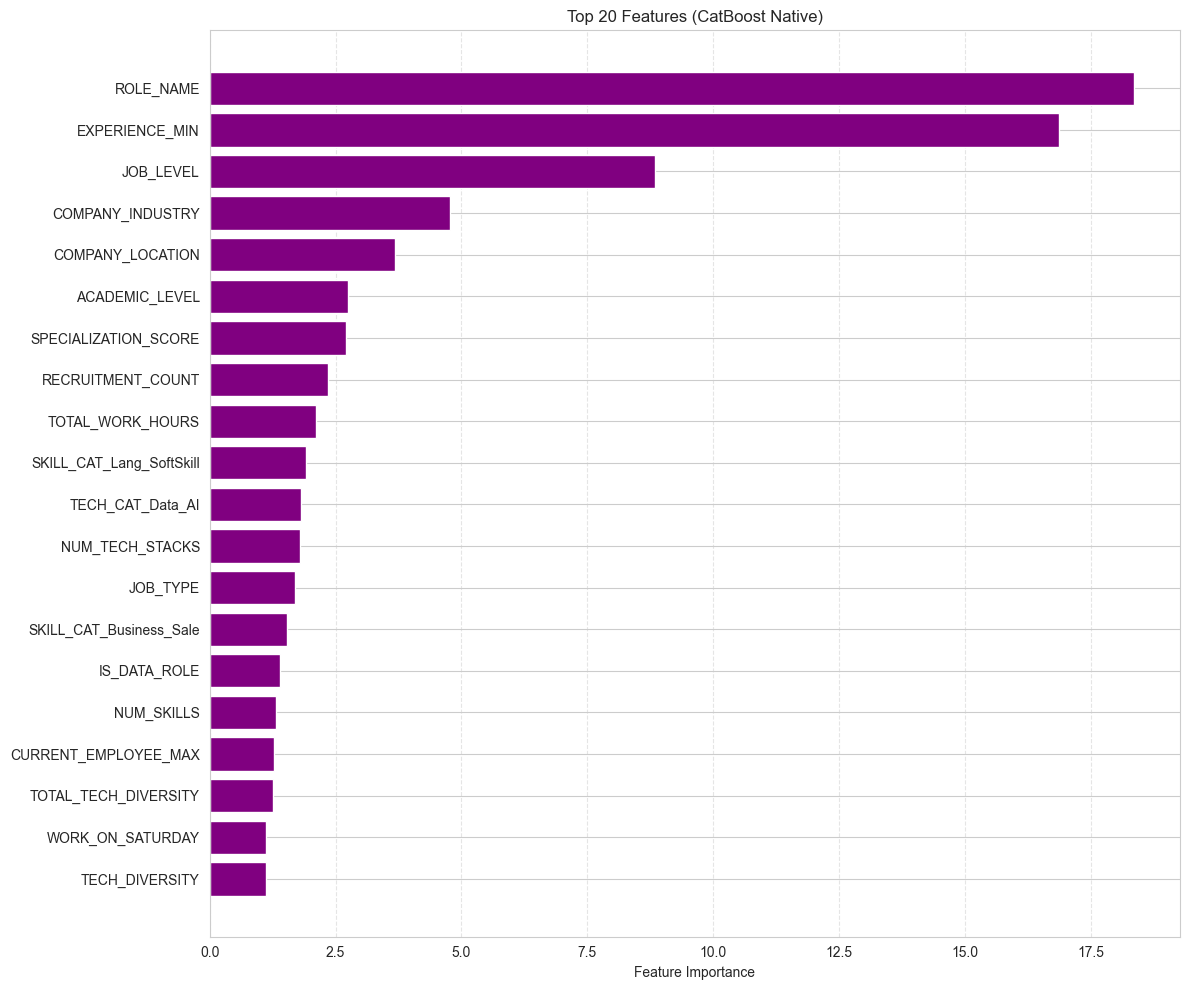

In [170]:
# 1. Dinh nghia ham muc tieu cho Optuna (Native Categorical)
def objective_cat_native(trial):
    # Khong gian tim kiem tham so
    param = {
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'task_type': 'CPU', 
        'random_seed': 42,
        'verbose': False,
        'allow_writing_files': False,
        
        # --- Search Space ---
        'iterations': trial.suggest_int('iterations', 500, 1500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'random_strength': trial.suggest_float('random_strength', 1, 20),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'border_count': trial.suggest_int('border_count', 32, 255),
        
        # Tham so rieng cho xu ly Categorical
        # one_hot_max_size: Neu so luong gia tri unique < nguong nay -> dung One-Hot, nguoc lai dung Ordered Encoding
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 20)
    }

    # Tao Pool du lieu (Bat buoc phai khai bao cat_features o day)
    # categorical_features la list ten cac cot (da khai bao o cac buoc truoc cua ban)
    train_pool = Pool(X_train_cat, y_train_cat, cat_features=categorical_features)
    dev_pool = Pool(X_dev_cat, y_dev_cat, cat_features=categorical_features)

    model = CatBoostRegressor(**param)
    
    # Train voi Early Stopping
    model.fit(
        train_pool,
        eval_set=dev_pool,
        early_stopping_rounds=50,
        verbose=False
    )
    
    # Du doan tren Dev
    preds = model.predict(dev_pool)
    rmse = np.sqrt(mean_squared_error(y_dev_cat, preds))
    
    return rmse

# 2. Chay Optuna
print("="*80)
print("STARTING OPTUNA FOR CATBOOST (NATIVE CATEGORICAL MODE)")
print("="*80)

study_cat_native = optuna.create_study(direction='minimize')
study_cat_native.optimize(objective_cat_native, n_trials=50) 

# 3. Ket qua Optuna
print("\n" + "="*80)
print("OPTUNA RESULTS")
print("="*80)
print(f"Best RMSE on Dev Set: {study_cat_native.best_value:,.0f} VND")
print("Best Params:")
for k, v in study_cat_native.best_params.items():
    print(f"  - {k}: {v}")

# 4. Train Final Model
print("\n" + "="*80)
print("TRAINING FINAL CATBOOST MODEL (NATIVE)")
print("="*80)

best_params_cat = study_cat_native.best_params
best_params_cat['random_seed'] = 42
best_params_cat['loss_function'] = 'RMSE'
best_params_cat['verbose'] = False
best_params_cat['allow_writing_files'] = False

# Khoi tao model cuoi cung
final_cat_model = CatBoostRegressor(**best_params_cat)

# Tao Pool cho toan bo Train va Dev (de retrain)
# O day ta van dung X_train_cat lam tap huan luyen chinh, dev lam tap validate
train_pool_final = Pool(X_train_cat, y_train_cat, cat_features=categorical_features)
dev_pool_final = Pool(X_dev_cat, y_dev_cat, cat_features=categorical_features)
test_pool_final = Pool(X_test_cat, cat_features=categorical_features) # Test khong co y

final_cat_model.fit(
    train_pool_final,
    eval_set=dev_pool_final,
    early_stopping_rounds=50,
    verbose=100
)

# 5. Final Evaluation
print("\nFINAL EVALUATION ON TEST SET")
# Du doan tren tap Test Cat
y_test_pred = final_cat_model.predict(test_pool_final)
y_train_pred = final_cat_model.predict(train_pool_final)

test_rmse = np.sqrt(mean_squared_error(y_test_cat, y_test_pred))
test_r2 = r2_score(y_test_cat, y_test_pred)
train_r2 = r2_score(y_train_cat, y_train_pred)
test_mape = mean_absolute_percentage_error(y_test_cat, y_test_pred) * 100

print(f"Test RMSE: {test_rmse:,.0f} VND")
print(f"Test R2:   {test_r2:.4f}")
print(f"Train R2:  {train_r2:.4f}")
print(f"Gap R2:    {train_r2 - test_r2:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")


# 6. Plot Importance
print("\nPlotting Feature Importance...")
feature_importance = final_cat_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[-20:]

plt.figure(figsize=(12, 10))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center', color='purple')
plt.yticks(range(len(sorted_idx)), np.array(X_train_cat.columns)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Top 20 Features (CatBoost Native)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Classification Task

## CLASSIFICATION TASK - Salary Range Prediction


### Strategy:
1. **Analyze distribution** để chọn bins tối ưu
2. **Create salary bins** (4 nhóm: Junior/Mid/Senior/Expert)
3. **Train classifiers** với Optuna optimization
4. **Compare multiple binning strategies**
5. **Evaluate với classification metrics**

### 1: Analyze Salary Distribution for Binning

In [173]:
print("="*80)
print("SALARY DISTRIBUTION ANALYSIS FOR CLASSIFICATION")
print("="*80)

# Analyze current y_train (from regression task)
print(f"\nSalary Statistics (Train Set):")
print(f"  Count: {len(y_train):,}")
print(f"  Mean:  {y_train.mean():,.0f} VND")
print(f"  Std:   {y_train.std():,.0f} VND")
print(f"  Min:   {y_train.min():,.0f} VND")
print(f"  25%:   {y_train.quantile(0.25):,.0f} VND")
print(f"  50%:   {y_train.quantile(0.50):,.0f} VND")
print(f"  75%:   {y_train.quantile(0.75):,.0f} VND")
print(f"  Max:   {y_train.max():,.0f} VND")

# Define binning strategy based on QUANTILES for balanced distribution
print("\n" + "-"*80)
print("BINNING STRATEGY (Based on Quantiles):")
print("-"*80)

# Use quartiles (25%, 50%, 75%) for balanced 4-class distribution
q25 = y_train.quantile(0.25)
q50 = y_train.quantile(0.50)
q75 = y_train.quantile(0.75)

salary_bins = [0, q25, q50, q75, float('inf')]
salary_labels = ['Q1 (Low)', 'Q2 (Mid-Low)', 'Q3 (Mid-High)', 'Q4 (High)']

print(f"\nChosen Strategy: 4 bins based on quartiles")
print(f"  Q1 (Low):      5M - {q25/1_000_000:.1f}M")
print(f"  Q2 (Mid-Low):  {q25/1_000_000:.1f}M - {q50/1_000_000:.1f}M")
print(f"  Q3 (Mid-High): {q50/1_000_000:.1f}M - {q75/1_000_000:.1f}M")
print(f"  Q4 (High):     {q75/1_000_000:.1f}M - {y_train.max()/1_000_000:.1f}M")

# Analyze distribution
temp_bins = pd.cut(y_train, bins=salary_bins, labels=salary_labels)
dist = temp_bins.value_counts().sort_index()

print(f"\nDistribution Analysis:")
for label in salary_labels:
    count = dist.get(label, 0)
    pct = (count / len(y_train)) * 100
    print(f"  {label:<15}: {count:>7,} samples ({pct:>5.1f}%)")

# Check balance
min_samples = dist.min()
max_samples = dist.max()
imbalance_ratio = max_samples / min_samples if min_samples > 0 else 1.0
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

print("\n" + "="*80)

SALARY DISTRIBUTION ANALYSIS FOR CLASSIFICATION

Salary Statistics (Train Set):
  Count: 2,201
  Mean:  16,938,369 VND
  Std:   5,340,411 VND
  Min:   3,000,000 VND
  25%:   13,375,000 VND
  50%:   16,900,000 VND
  75%:   20,000,000 VND
  Max:   31,000,000 VND

--------------------------------------------------------------------------------
BINNING STRATEGY (Based on Quantiles):
--------------------------------------------------------------------------------

Chosen Strategy: 4 bins based on quartiles
  Q1 (Low):      5M - 13.4M
  Q2 (Mid-Low):  13.4M - 16.9M
  Q3 (Mid-High): 16.9M - 20.0M
  Q4 (High):     20.0M - 31.0M

Distribution Analysis:
  Q1 (Low)       :     595 samples ( 27.0%)
  Q2 (Mid-Low)   :     534 samples ( 24.3%)
  Q3 (Mid-High)  :     593 samples ( 26.9%)
  Q4 (High)      :     479 samples ( 21.8%)

Imbalance Ratio: 1.24:1



### 2: Create Classification Target Variable

CREATE CLASSIFICATION TARGET - Using Quartile-Based Binning

Classification Target Created:
  Q1 (Low):      5M - 13.4M
  Q2 (Mid-Low):  13.4M - 16.9M
  Q3 (Mid-High): 16.9M - 20.0M
  Q4 (High):     >20.0M

Class Distribution:

Train Set (2,201 samples):
  Q1 (Low)       :     595 ( 27.0%)
  Q2 (Mid-Low)   :     534 ( 24.3%)
  Q3 (Mid-High)  :     593 ( 26.9%)
  Q4 (High)      :     479 ( 21.8%)

Dev Set (469 samples):
  Q1 (Low)       :     122 ( 26.0%)
  Q2 (Mid-Low)   :     123 ( 26.2%)
  Q3 (Mid-High)  :     124 ( 26.4%)
  Q4 (High)      :     100 ( 21.3%)

Test Set (482 samples):
  Q1 (Low)       :     136 ( 28.2%)
  Q2 (Mid-Low)   :     116 ( 24.1%)
  Q3 (Mid-High)  :     123 ( 25.5%)
  Q4 (High)      :     107 ( 22.2%)

Classification Target Created:
  Q1 (Low):      5M - 13.4M
  Q2 (Mid-Low):  13.4M - 16.9M
  Q3 (Mid-High): 16.9M - 20.0M
  Q4 (High):     >20.0M

Class Distribution:

Train Set (2,201 samples):
  Q1 (Low)       :     595 ( 27.0%)
  Q2 (Mid-Low)   :     534 ( 24.3

CREATE CLASSIFICATION TARGET - Using Quartile-Based Binning

Classification Target Created:
  Q1 (Low):      5M - 13.4M
  Q2 (Mid-Low):  13.4M - 16.9M
  Q3 (Mid-High): 16.9M - 20.0M
  Q4 (High):     >20.0M

Class Distribution:

Train Set (2,201 samples):
  Q1 (Low)       :     595 ( 27.0%)
  Q2 (Mid-Low)   :     534 ( 24.3%)
  Q3 (Mid-High)  :     593 ( 26.9%)
  Q4 (High)      :     479 ( 21.8%)

Dev Set (469 samples):
  Q1 (Low)       :     122 ( 26.0%)
  Q2 (Mid-Low)   :     123 ( 26.2%)
  Q3 (Mid-High)  :     124 ( 26.4%)
  Q4 (High)      :     100 ( 21.3%)

Test Set (482 samples):
  Q1 (Low)       :     136 ( 28.2%)
  Q2 (Mid-Low)   :     116 ( 24.1%)
  Q3 (Mid-High)  :     123 ( 25.5%)
  Q4 (High)      :     107 ( 22.2%)

Classification Target Created:
  Q1 (Low):      5M - 13.4M
  Q2 (Mid-Low):  13.4M - 16.9M
  Q3 (Mid-High): 16.9M - 20.0M
  Q4 (High):     >20.0M

Class Distribution:

Train Set (2,201 samples):
  Q1 (Low)       :     595 ( 27.0%)
  Q2 (Mid-Low)   :     534 ( 24.3

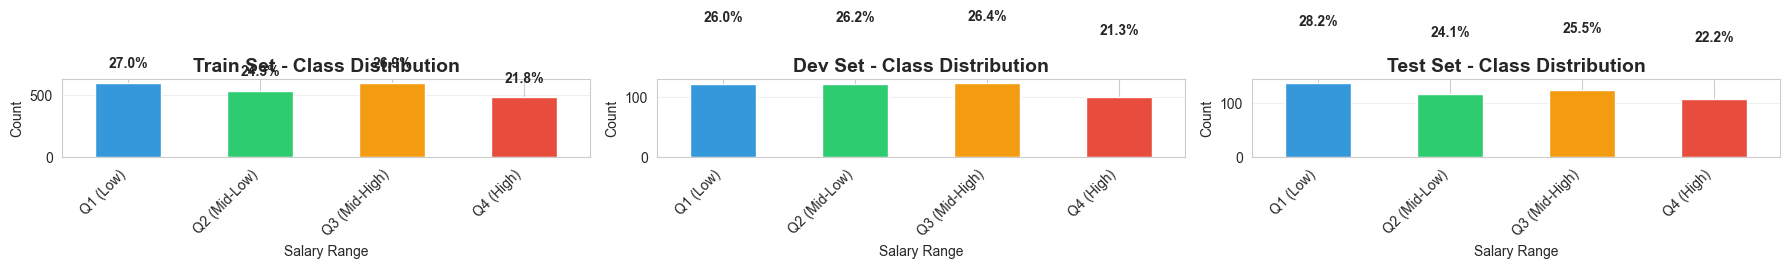


Classification targets ready for modeling!


In [174]:
print("="*80)
print("CREATE CLASSIFICATION TARGET - Using Quartile-Based Binning")
print("="*80)

# Use the same quartiles from Step 1
q25 = y_train.quantile(0.25)
q50 = y_train.quantile(0.50)
q75 = y_train.quantile(0.75)

salary_bins = [0, q25, q50, q75, float('inf')]
salary_labels = ['Q1 (Low)', 'Q2 (Mid-Low)', 'Q3 (Mid-High)', 'Q4 (High)']

# Create classification targets for all sets
y_train_clf = pd.cut(y_train, bins=salary_bins, labels=salary_labels)
y_dev_clf = pd.cut(y_dev, bins=salary_bins, labels=salary_labels)
y_test_clf = pd.cut(y_test, bins=salary_bins, labels=salary_labels)

# Convert to categorical codes for modeling
y_train_clf_encoded = y_train_clf.cat.codes
y_dev_clf_encoded = y_dev_clf.cat.codes
y_test_clf_encoded = y_test_clf.cat.codes

print(f"\nClassification Target Created:")
print(f"  Q1 (Low):      5M - {q25/1_000_000:.1f}M")
print(f"  Q2 (Mid-Low):  {q25/1_000_000:.1f}M - {q50/1_000_000:.1f}M")
print(f"  Q3 (Mid-High): {q50/1_000_000:.1f}M - {q75/1_000_000:.1f}M")
print(f"  Q4 (High):     >{q75/1_000_000:.1f}M")

print(f"\nClass Distribution:")
print(f"\nTrain Set ({len(y_train_clf):,} samples):")
train_dist = y_train_clf.value_counts().sort_index()
for label in salary_labels:
    count = train_dist.get(label, 0)
    pct = (count / len(y_train_clf)) * 100
    print(f"  {label:<15}: {count:>7,} ({pct:>5.1f}%)")

print(f"\nDev Set ({len(y_dev_clf):,} samples):")
dev_dist = y_dev_clf.value_counts().sort_index()
for label in salary_labels:
    count = dev_dist.get(label, 0)
    pct = (count / len(y_dev_clf)) * 100
    print(f"  {label:<15}: {count:>7,} ({pct:>5.1f}%)")

print(f"\nTest Set ({len(y_test_clf):,} samples):")
test_dist = y_test_clf.value_counts().sort_index()
for label in salary_labels:
    count = test_dist.get(label, 0)
    pct = (count / len(y_test_clf)) * 100
    print(f"  {label:<15}: {count:>7,} ({pct:>5.1f}%)")

# Visualize distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title in zip(axes, [train_dist, dev_dist, test_dist], ['Train', 'Dev', 'Test']):
    data.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
    ax.set_title(f'{title} Set - Class Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Salary Range')
    ax.set_ylabel('Count')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    # Add percentage labels
    for i, v in enumerate(data.values):
        pct = (v / data.sum()) * 100
        ax.text(i, v + 100, f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Classification targets ready for modeling!")
print("="*80)

### 3: Classification Models with Optuna Optimization

In [179]:
import optuna
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Suppress Optuna logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("="*80)
print("CLASSIFICATION MODELS WITH OPTUNA OPTIMIZATION")
print("="*80)

# Initialize results storage
clf_results = {}

def evaluate_classifier(model, X_train, X_dev, X_test, y_train, y_dev, y_test, model_name):
    """
    Comprehensive evaluation for classification model
    """
    import time
    
    # Training
    print(f"\n{'='*80}")
    print(f"Evaluating {model_name}...")
    start_time = time.time()
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_dev_pred = model.predict(X_dev)
    y_test_pred = model.predict(X_test)
    
    # Probabilities for ROC-AUC (if available)
    try:
        y_train_proba = model.predict_proba(X_train)
        y_dev_proba = model.predict_proba(X_dev)
        y_test_proba = model.predict_proba(X_test)
        has_proba = True
    except:
        has_proba = False
    
    training_time = time.time() - start_time
    
    # Calculate metrics
    metrics = {}
    for set_name, y_true, y_pred in [
        ('train', y_train, y_train_pred),
        ('dev', y_dev, y_dev_pred),
        ('test', y_test, y_test_pred)
    ]:
        metrics[f'{set_name}_accuracy'] = accuracy_score(y_true, y_pred)
        metrics[f'{set_name}_f1_macro'] = f1_score(y_true, y_pred, average='macro')
        metrics[f'{set_name}_f1_weighted'] = f1_score(y_true, y_pred, average='weighted')
        metrics[f'{set_name}_precision'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        metrics[f'{set_name}_recall'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        
        # ROC-AUC (one-vs-rest)
        if has_proba:
            if set_name == 'train':
                proba = y_train_proba
            elif set_name == 'dev':
                proba = y_dev_proba
            else:
                proba = y_test_proba
            
            try:
                metrics[f'{set_name}_roc_auc'] = roc_auc_score(y_true, proba, multi_class='ovr', average='weighted')
            except:
                metrics[f'{set_name}_roc_auc'] = 0.0
    
    # Print results
    print(f"\n{model_name} Results:")
    print(f"{'Metric':<20} {'Train':<12} {'Dev':<12} {'Test':<12}")
    print(f"{'-'*60}")
    print(f"{'Accuracy':<20} {metrics['train_accuracy']:<12.4f} {metrics['dev_accuracy']:<12.4f} {metrics['test_accuracy']:<12.4f}")
    print(f"{'F1 (Macro)':<20} {metrics['train_f1_macro']:<12.4f} {metrics['dev_f1_macro']:<12.4f} {metrics['test_f1_macro']:<12.4f}")
    print(f"{'F1 (Weighted)':<20} {metrics['train_f1_weighted']:<12.4f} {metrics['dev_f1_weighted']:<12.4f} {metrics['test_f1_weighted']:<12.4f}")
    print(f"{'Precision':<20} {metrics['train_precision']:<12.4f} {metrics['dev_precision']:<12.4f} {metrics['test_precision']:<12.4f}")
    print(f"{'Recall':<20} {metrics['train_recall']:<12.4f} {metrics['dev_recall']:<12.4f} {metrics['test_recall']:<12.4f}")
    if has_proba:
        print(f"{'ROC-AUC (OVR)':<20} {metrics['train_roc_auc']:<12.4f} {metrics['dev_roc_auc']:<12.4f} {metrics['test_roc_auc']:<12.4f}")
    
    acc_gap = metrics['train_accuracy'] - metrics['dev_accuracy']
    
    return {
        'model': model,
        'model_name': model_name,
        **metrics,
        'training_time': training_time,
        'predictions': {
            'train': y_train_pred,
            'dev': y_dev_pred,
            'test': y_test_pred
        }
    }

print("\nEvaluation function ready!")

CLASSIFICATION MODELS WITH OPTUNA OPTIMIZATION

Evaluation function ready!


In [ ]:
# 1. RANDOM FOREST WITH OPTUNA
print("\n" + "="*80)
print("OPTIMIZING RANDOM FOREST CLASSIFIER")
print("="*80)

def objective_rf_clf(trial):
    """Optuna objective for Random Forest Classifier"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train_clf_encoded)
    
    # Evaluate on dev set
    y_dev_pred = model.predict(X_dev)
    f1 = f1_score(y_dev_clf_encoded, y_dev_pred, average='macro')
    
    return f1

# Run optimization
study_rf_clf = optuna.create_study(direction='maximize', study_name='RandomForest_Classifier')
study_rf_clf.optimize(objective_rf_clf, n_trials=50, show_progress_bar=True)

print(f"\nBest F1 Score (Macro): {study_rf_clf.best_value:.4f}")
print(f"Best Parameters: {study_rf_clf.best_params}")

# Train final model with best params
rf_clf_best = RandomForestClassifier(**study_rf_clf.best_params, random_state=42, n_jobs=-1)
rf_clf_best.fit(X_train, y_train_clf_encoded)

# Evaluate
clf_results['Random Forest'] = evaluate_classifier(
    rf_clf_best, X_train, X_dev, X_test,
    y_train_clf_encoded, y_dev_clf_encoded, y_test_clf_encoded,
    'Random Forest'
)


Evaluating Random Forest...

Random Forest Results:
Metric               Train        Dev          Test        
------------------------------------------------------------
Accuracy             0.9182       0.5672       0.5311      
F1 (Macro)           0.9189       0.5582       0.5197      
F1 (Weighted)        0.9184       0.5596       0.5254      
Precision            0.9203       0.5622       0.5242      
Recall               0.9182       0.5672       0.5311      
ROC-AUC (OVR)        0.9910       0.8172       0.7880      


In [ ]:
# 2. XGBOOST WITH OPTUNA
print("\n" + "="*80)
print("OPTIMIZING XGBOOST CLASSIFIER")
print("="*80)

def objective_xgb_clf(trial):
    """Optuna objective for XGBoost Classifier"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'random_state': 42,
        'n_jobs': -1,
        'tree_method': 'hist'
    }
    
    model = xgb.XGBClassifier(**params, eval_metric='mlogloss')
    model.fit(X_train, y_train_clf_encoded)
    
    # Evaluate on dev set
    y_dev_pred = model.predict(X_dev)
    f1 = f1_score(y_dev_clf_encoded, y_dev_pred, average='macro')
    
    return f1

# Run optimization
study_xgb_clf = optuna.create_study(direction='maximize', study_name='XGBoost_Classifier')
study_xgb_clf.optimize(objective_xgb_clf, n_trials=50, show_progress_bar=True)

print(f"\nBest F1 Score (Macro): {study_xgb_clf.best_value:.4f}")
print(f"Best Parameters: {study_xgb_clf.best_params}")

# Train final model with best params
xgb_clf_best = xgb.XGBClassifier(**study_xgb_clf.best_params, random_state=42, n_jobs=-1, 
                                  tree_method='hist', eval_metric='mlogloss')
xgb_clf_best.fit(X_train, y_train_clf_encoded)

# Evaluate
clf_results['XGBoost'] = evaluate_classifier(
    xgb_clf_best, X_train, X_dev, X_test,
    y_train_clf_encoded, y_dev_clf_encoded, y_test_clf_encoded,
    'XGBoost'
)


Evaluating XGBoost...

XGBoost Results:
Metric               Train        Dev          Test        
------------------------------------------------------------
Accuracy             0.9995       0.5885       0.5664      
F1 (Macro)           0.9996       0.5846       0.5597      
F1 (Weighted)        0.9995       0.5844       0.5645      
Precision            0.9995       0.5845       0.5650      
Recall               0.9995       0.5885       0.5664      
ROC-AUC (OVR)        1.0000       0.8185       0.7960      


In [ ]:
# 3. LIGHTGBM WITH OPTUNA
print("\n" + "="*80)
print("OPTIMIZING LIGHTGBM CLASSIFIER")
print("="*80)

def objective_lgb_clf(trial):
    """Optuna objective for LightGBM Classifier"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train_clf_encoded)
    
    # Evaluate on dev set
    y_dev_pred = model.predict(X_dev)
    f1 = f1_score(y_dev_clf_encoded, y_dev_pred, average='macro')
    
    return f1

# Run optimization
study_lgb_clf = optuna.create_study(direction='maximize', study_name='LightGBM_Classifier')
study_lgb_clf.optimize(objective_lgb_clf, n_trials=50, show_progress_bar=True)

print(f"\nBest F1 Score (Macro): {study_lgb_clf.best_value:.4f}")
print(f"Best Parameters: {study_lgb_clf.best_params}")

# Train final model with best params
lgb_clf_best = lgb.LGBMClassifier(**study_lgb_clf.best_params, random_state=42, n_jobs=-1, verbose=-1)
lgb_clf_best.fit(X_train, y_train_clf_encoded)




Evaluating LightGBM...

LightGBM Results:
Metric               Train        Dev          Test        
------------------------------------------------------------
Accuracy             0.8710       0.5906       0.5581      
F1 (Macro)           0.8712       0.5876       0.5519      
F1 (Weighted)        0.8710       0.5883       0.5557      
Precision            0.8734       0.5884       0.5550      
Recall               0.8710       0.5906       0.5581      
ROC-AUC (OVR)        0.9766       0.8231       0.8021      


In [ ]:
from catboost import CatBoostClassifier #
# 4. CATBOOST WITH OPTUNA
print("\n" + "="*80)
print("OPTIMIZING CATBOOST CLASSIFIER")
print("="*80)

def objective_cat_clf(trial):
    """Optuna objective for CatBoost Classifier"""
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'random_state': 42,
        'verbose': 0,
        'thread_count': -1
    }
    
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train_clf_encoded)
    
    # Evaluate on dev set
    y_dev_pred = model.predict(X_dev)
    f1 = f1_score(y_dev_clf_encoded, y_dev_pred, average='macro')
    
    return f1

# Run optimization
study_cat_clf = optuna.create_study(direction='maximize', study_name='CatBoost_Classifier')
study_cat_clf.optimize(objective_cat_clf, n_trials=50, show_progress_bar=True)

print(f"\nBest F1 Score (Macro): {study_cat_clf.best_value:.4f}")
print(f"Best Parameters: {study_cat_clf.best_params}")

# Train final model with best params
cat_clf_best = CatBoostClassifier(**study_cat_clf.best_params, random_state=42, verbose=0, thread_count=-1)
cat_clf_best.fit(X_train, y_train_clf_encoded)

# Evaluate
clf_results['CatBoost'] = evaluate_classifier(
    cat_clf_best, X_train, X_dev, X_test,
    y_train_clf_encoded, y_dev_clf_encoded, y_test_clf_encoded,
    'CatBoost'
)


Evaluating CatBoost...

CatBoost Results:
Metric               Train        Dev          Test        
------------------------------------------------------------
Accuracy             0.9986       0.5906       0.5145      
F1 (Macro)           0.9987       0.5832       0.5048      
F1 (Weighted)        0.9986       0.5844       0.5115      
Precision            0.9986       0.5847       0.5117      
Recall               0.9986       0.5906       0.5145      
ROC-AUC (OVR)        1.0000       0.8117       0.7778      


In [ ]:
# 5. GRADIENT BOOSTING WITH OPTUNA
print("\n" + "="*80)
print("OPTIMIZING GRADIENT BOOSTING CLASSIFIER")
print("="*80)

def objective_gb_clf(trial):
    """Optuna objective for Gradient Boosting Classifier"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42
    }
    
    model = GradientBoostingClassifier(**params)
    model.fit(X_train, y_train_clf_encoded)
    
    # Evaluate on dev set
    y_dev_pred = model.predict(X_dev)
    f1 = f1_score(y_dev_clf_encoded, y_dev_pred, average='macro')
    
    return f1

# Run optimization
study_gb_clf = optuna.create_study(direction='maximize', study_name='GradientBoosting_Classifier')
study_gb_clf.optimize(objective_gb_clf, n_trials=50, show_progress_bar=True)

print(f"\nBest F1 Score (Macro): {study_gb_clf.best_value:.4f}")
print(f"Best Parameters: {study_gb_clf.best_params}")

# Train final model with best params
gb_clf_best = GradientBoostingClassifier(**study_gb_clf.best_params, random_state=42)
gb_clf_best.fit(X_train, y_train_clf_encoded)

# Evaluate
clf_results['Gradient Boosting'] = evaluate_classifier(
    gb_clf_best, X_train, X_dev, X_test,
    y_train_clf_encoded, y_dev_clf_encoded, y_test_clf_encoded,
    'Gradient Boosting'
)


Evaluating Gradient Boosting...

Gradient Boosting Results:
Metric               Train        Dev          Test        
------------------------------------------------------------
Accuracy             0.9995       0.5949       0.5581      
F1 (Macro)           0.9996       0.5910       0.5516      
F1 (Weighted)        0.9995       0.5921       0.5560      
Precision            0.9995       0.5922       0.5555      
Recall               0.9995       0.5949       0.5581      
ROC-AUC (OVR)        1.0000       0.8106       0.7880      


In [ ]:
# 6. LOGISTIC REGRESSION WITH OPTUNA (Baseline)
print("\n" + "="*80)
print("OPTIMIZING LOGISTIC REGRESSION")
print("="*80)

def objective_lr_clf(trial):
    """Optuna objective for Logistic Regression"""
    params = {
        'C': trial.suggest_float('C', 0.001, 10, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': 'saga',  # Supports both L1 and L2
        'max_iter': 1000,
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = LogisticRegression(**params)
    model.fit(X_train, y_train_clf_encoded)
    
    # Evaluate on dev set
    y_dev_pred = model.predict(X_dev)
    f1 = f1_score(y_dev_clf_encoded, y_dev_pred, average='macro')
    
    return f1

# Run optimization
study_lr_clf = optuna.create_study(direction='maximize', study_name='LogisticRegression')
study_lr_clf.optimize(objective_lr_clf, n_trials=30, show_progress_bar=True)

print(f"\nBest F1 Score (Macro): {study_lr_clf.best_value:.4f}")
print(f"Best Parameters: {study_lr_clf.best_params}")

# Train final model with best params
lr_clf_best = LogisticRegression(**study_lr_clf.best_params, solver='saga', max_iter=1000, 
                                  random_state=42, n_jobs=-1)
lr_clf_best.fit(X_train, y_train_clf_encoded)

# Evaluate
clf_results['Logistic Regression'] = evaluate_classifier(
    lr_clf_best, X_train, X_dev, X_test,
    y_train_clf_encoded, y_dev_clf_encoded, y_test_clf_encoded,
    'Logistic Regression'
)

print("\n" + "="*80)
print("ALL CLASSIFICATION MODELS OPTIMIZED!")
print("="*80)


Evaluating Logistic Regression...

Logistic Regression Results:
Metric               Train        Dev          Test        
------------------------------------------------------------
Accuracy             0.4062       0.4072       0.3983      
F1 (Macro)           0.3147       0.3245       0.3015      
F1 (Weighted)        0.3297       0.3320       0.3173      
Precision            0.3903       0.3943       0.4114      
Recall               0.4062       0.4072       0.3983      
ROC-AUC (OVR)        0.6869       0.7079       0.6603      

ALL CLASSIFICATION MODELS OPTIMIZED!


### 4: Model Comparison and Analysis

In [212]:
# Create comparison dataframe
clf_comparison_data = []

for model_name, result in clf_results.items():
    clf_comparison_data.append({
        'Model': model_name,
        'Train Accuracy': result['train_accuracy'],
        'Dev Accuracy': result['dev_accuracy'],
        'Test Accuracy': result['test_accuracy'],
        'Train F1 (Weighted)': result['train_f1_weighted'],
        'Dev F1 (Weighted)': result['dev_f1_weighted'],
        'Test F1 (Weighted)': result['test_f1_weighted'],
        'Train F1 (Macro)': result['train_f1_macro'],
        'Dev F1 (Macro)': result['dev_f1_macro'],
        'Test F1 (Macro)': result['test_f1_macro'],
        'Train Precision': result['train_precision'],
        'Dev Precision': result['dev_precision'],
        'Test Precision': result['test_precision'],
        'Train Recall': result['train_recall'],
        'Dev Recall': result['dev_recall'],
        'Test Recall': result['test_recall'],
        'Training Time (s)': result['training_time']
    })

clf_comparison_df = pd.DataFrame(clf_comparison_data)

# Sort by Test F1 (Macro)
clf_comparison_df = clf_comparison_df.sort_values('Test F1 (Macro)', ascending=False)

print("\n" + "="*120)
print("CLASSIFICATION MODELS COMPARISON")
print("="*120)
print(clf_comparison_df.to_string(index=False))

# Find best model
best_model_name = clf_comparison_df.iloc[0]['Model']
best_test_f1 = clf_comparison_df.iloc[0]['Test F1 (Macro)']

print(f"\n{'='*120}")
print(f"BEST MODEL: {best_model_name} with Test F1 (Macro) = {best_test_f1:.4f}")
print(f"{'='*120}")


CLASSIFICATION MODELS COMPARISON
              Model  Train Accuracy  Dev Accuracy  Test Accuracy  Train F1 (Weighted)  Dev F1 (Weighted)  Test F1 (Weighted)  Train F1 (Macro)  Dev F1 (Macro)  Test F1 (Macro)  Train Precision  Dev Precision  Test Precision  Train Recall  Dev Recall  Test Recall  Training Time (s)
            XGBoost        0.999546      0.588486       0.566390             0.999546           0.584409            0.564516          0.999556        0.584568         0.559737         0.999546       0.584549        0.565033      0.999546    0.588486     0.566390           0.131247
           LightGBM        0.870968      0.590618       0.558091             0.871020           0.588274            0.555749          0.871217        0.587560         0.551861         0.873386       0.588369        0.555038      0.870968    0.590618     0.558091           0.048623
  Gradient Boosting        0.999546      0.594883       0.558091             0.999546           0.592125            0.55

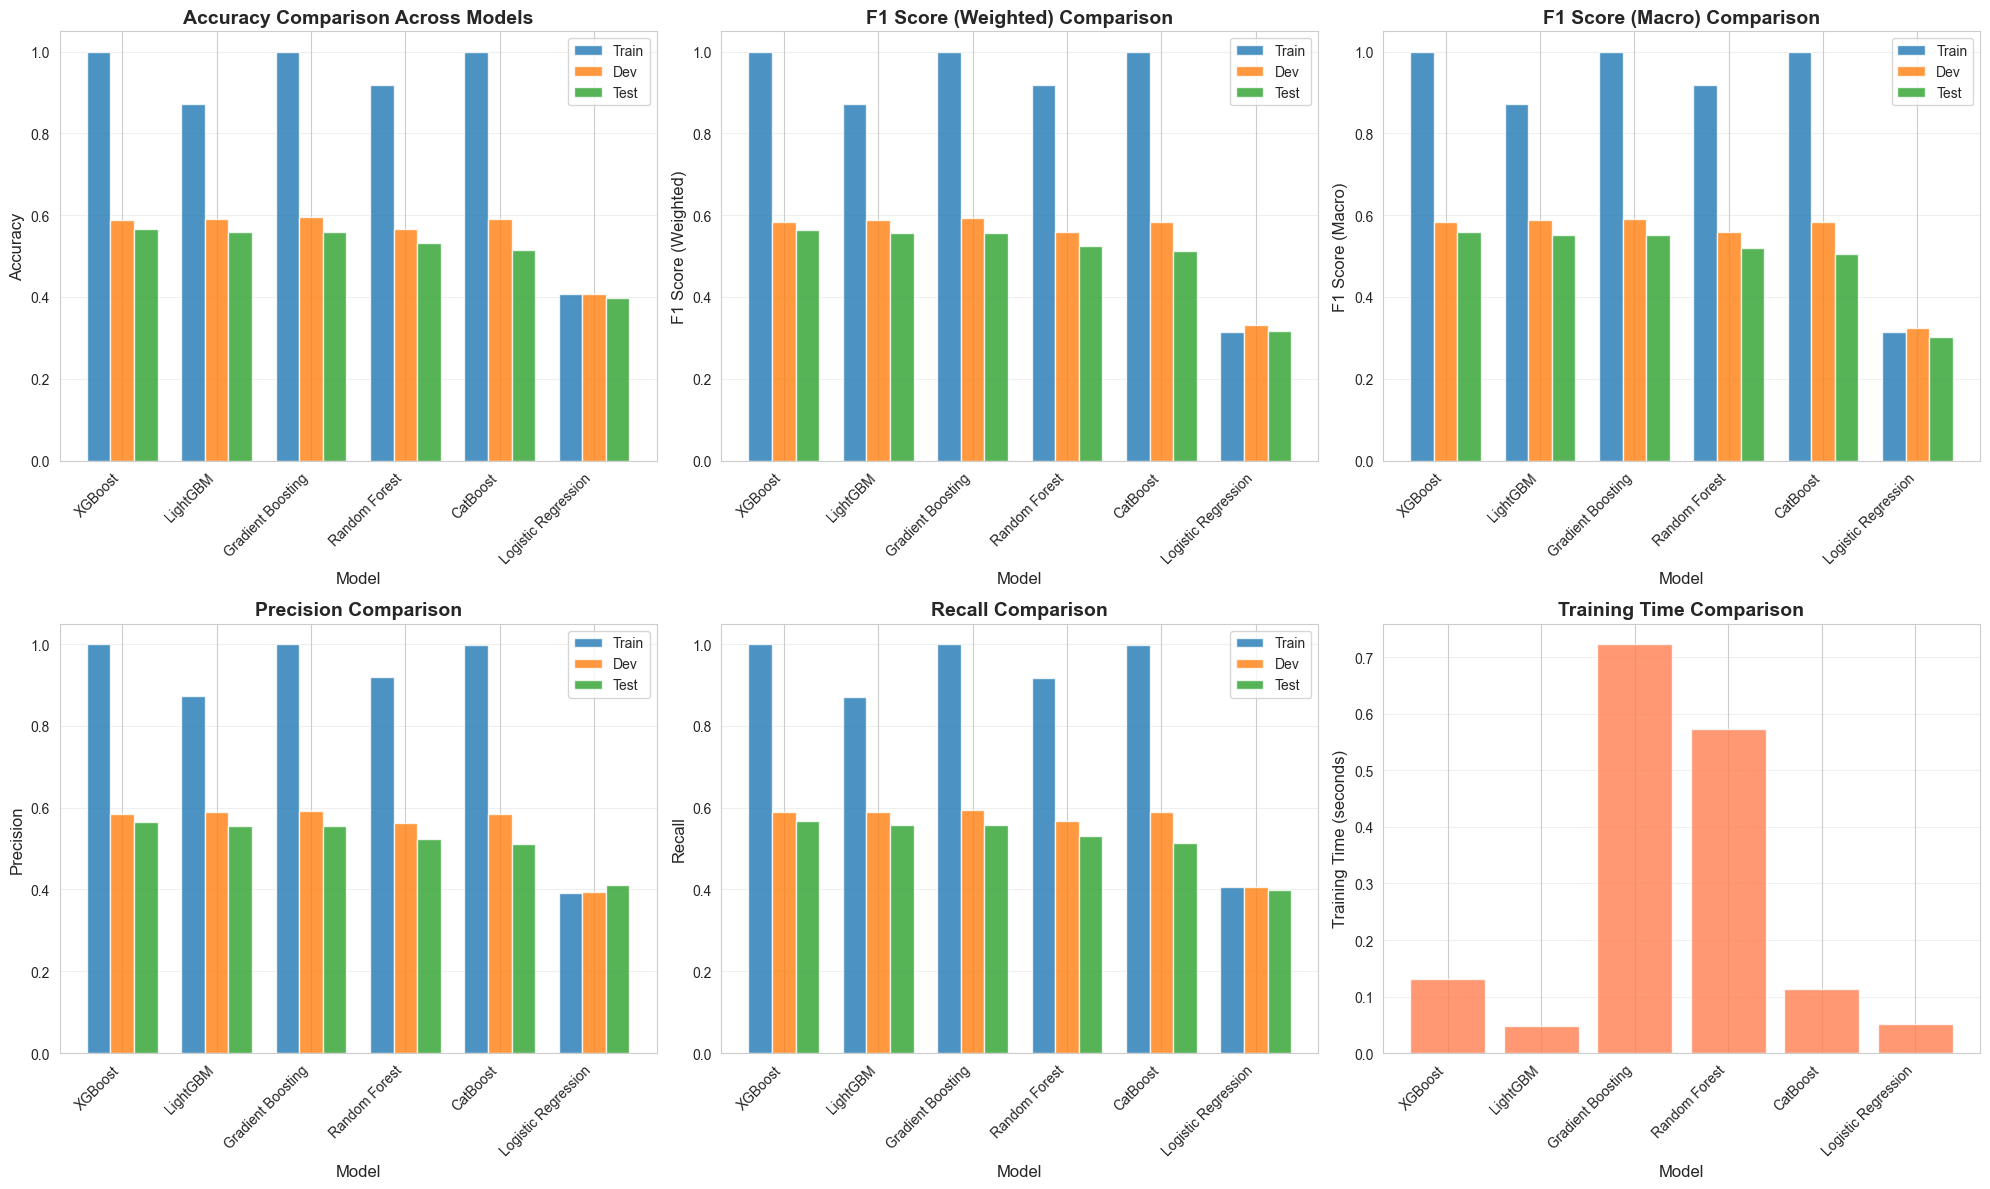

In [211]:
# Visualization: Model Performance Comparison
fig = plt.figure(figsize=(20, 12))

# 1. Accuracy Comparison
ax1 = plt.subplot(2, 3, 1)
x = np.arange(len(clf_comparison_df))
width = 0.25

ax1.bar(x - width, clf_comparison_df['Train Accuracy'], width, label='Train', alpha=0.8)
ax1.bar(x, clf_comparison_df['Dev Accuracy'], width, label='Dev', alpha=0.8)
ax1.bar(x + width, clf_comparison_df['Test Accuracy'], width, label='Test', alpha=0.8)

ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy Comparison Across Models', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(clf_comparison_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. F1 (Weighted) Comparison
ax2 = plt.subplot(2, 3, 2)
ax2.bar(x - width, clf_comparison_df['Train F1 (Macro)'], width, label='Train', alpha=0.8)
ax2.bar(x, clf_comparison_df['Dev F1 (Weighted)'], width, label='Dev', alpha=0.8)
ax2.bar(x + width, clf_comparison_df['Test F1 (Weighted)'], width, label='Test', alpha=0.8)

ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('F1 Score (Weighted)', fontsize=12)
ax2.set_title('F1 Score (Weighted) Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(clf_comparison_df['Model'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. F1 (Macro) Comparison
ax3 = plt.subplot(2, 3, 3)
ax3.bar(x - width, clf_comparison_df['Train F1 (Macro)'], width, label='Train', alpha=0.8)
ax3.bar(x, clf_comparison_df['Dev F1 (Macro)'], width, label='Dev', alpha=0.8)
ax3.bar(x + width, clf_comparison_df['Test F1 (Macro)'], width, label='Test', alpha=0.8)

ax3.set_xlabel('Model', fontsize=12)
ax3.set_ylabel('F1 Score (Macro)', fontsize=12)
ax3.set_title('F1 Score (Macro) Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(clf_comparison_df['Model'], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Precision Comparison
ax4 = plt.subplot(2, 3, 4)
ax4.bar(x - width, clf_comparison_df['Train Precision'], width, label='Train', alpha=0.8)
ax4.bar(x, clf_comparison_df['Dev Precision'], width, label='Dev', alpha=0.8)
ax4.bar(x + width, clf_comparison_df['Test Precision'], width, label='Test', alpha=0.8)

ax4.set_xlabel('Model', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Precision Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(clf_comparison_df['Model'], rotation=45, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 5. Recall Comparison
ax5 = plt.subplot(2, 3, 5)
ax5.bar(x - width, clf_comparison_df['Train Recall'], width, label='Train', alpha=0.8)
ax5.bar(x, clf_comparison_df['Dev Recall'], width, label='Dev', alpha=0.8)
ax5.bar(x + width, clf_comparison_df['Test Recall'], width, label='Test', alpha=0.8)

ax5.set_xlabel('Model', fontsize=12)
ax5.set_ylabel('Recall', fontsize=12)
ax5.set_title('Recall Comparison', fontsize=14, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(clf_comparison_df['Model'], rotation=45, ha='right')
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# 6. Training Time Comparison
ax6 = plt.subplot(2, 3, 6)
ax6.bar(clf_comparison_df['Model'], clf_comparison_df['Training Time (s)'], alpha=0.8, color='coral')
ax6.set_xlabel('Model', fontsize=12)
ax6.set_ylabel('Training Time (seconds)', fontsize=12)
ax6.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax6.set_xticklabels(clf_comparison_df['Model'], rotation=45, ha='right')
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5: Confusion Matrix Analysis

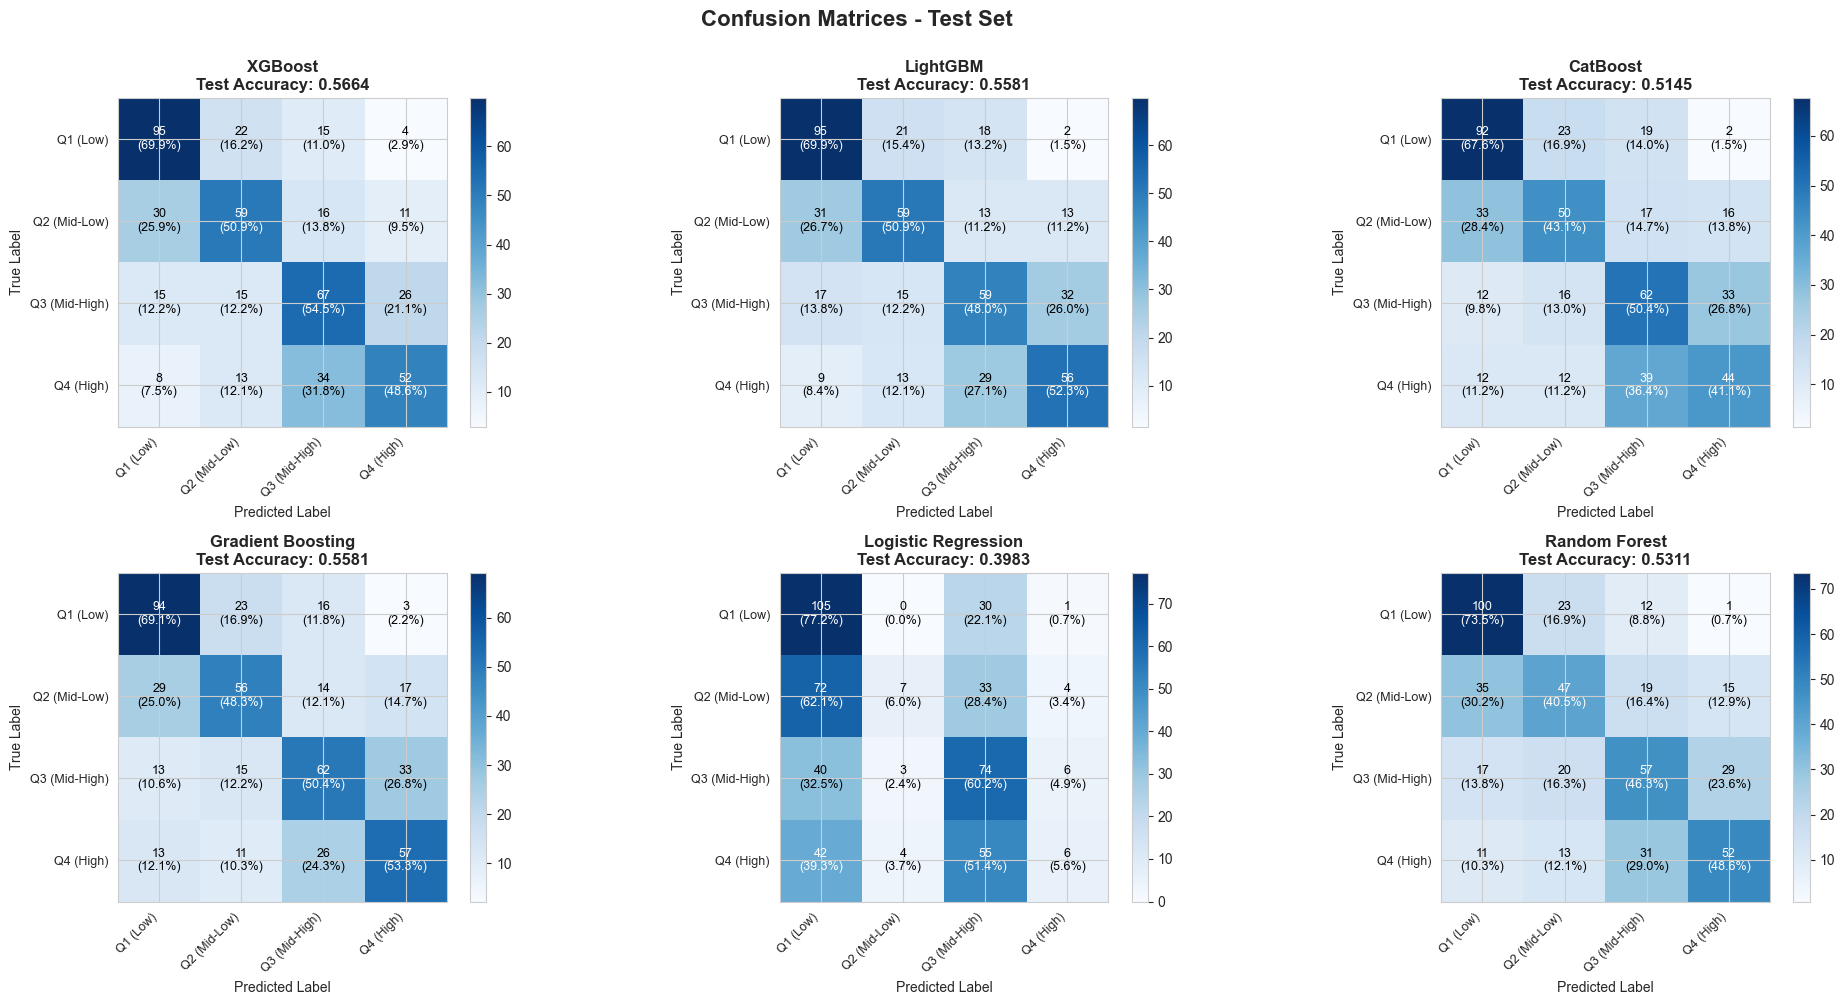

In [210]:
# Plot confusion matrices for all models on Test set
# Get the actual labels from the classification target
salary_labels_display = y_train_clf.cat.categories.tolist()

fig = plt.figure(figsize=(20, 10))

for idx, (model_name, result) in enumerate(clf_results.items(), 1):
    ax = plt.subplot(2, 3, idx)
    
    # Get predictions
    y_test_pred = result['predictions']['test']
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test_clf_encoded, y_test_pred)
    
    # Normalize confusion matrix (percentages)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Plot
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{model_name}\nTest Accuracy: {result["test_accuracy"]:.4f}', 
                 fontsize=12, fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Set ticks and labels
    tick_marks = np.arange(len(salary_labels_display))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(salary_labels_display, fontsize=9, rotation=45, ha='right')
    ax.set_yticklabels(salary_labels_display, fontsize=9)
    
    # Add text annotations (count and percentage)
    thresh = cm_norm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f'{cm[i, j]}\n({cm_norm[i, j]:.1f}%)',
                   ha="center", va="center",
                   color="white" if cm_norm[i, j] > thresh else "black",
                   fontsize=9)
    
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.suptitle('Confusion Matrices - Test Set', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [209]:
# Detailed Classification Report for Best Model
best_model_result = clf_results[best_model_name]
y_test_pred_best = best_model_result['predictions']['test']

# Get the actual labels from the classification target
salary_labels_list = y_train_clf.cat.categories.tolist()

print("\n" + "="*80)
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("="*80)
print("\nTest Set Performance:")
print(classification_report(y_test_clf_encoded, y_test_pred_best, 
                           target_names=salary_labels_list, 
                           digits=4))

# Per-class analysis
print("\n" + "="*80)
print("PER-CLASS ANALYSIS (Test Set)")
print("="*80)

cm = confusion_matrix(y_test_clf_encoded, y_test_pred_best)
for i, label in enumerate(salary_labels_list):
    total = cm[i].sum()
    correct = cm[i, i]
    accuracy = correct / total if total > 0 else 0
    
    print(f"\n{label}:")
    print(f"  Total samples: {total}")
    print(f"  Correctly classified: {correct} ({accuracy*100:.2f}%)")
    print(f"  Misclassified: {total - correct} ({(1-accuracy)*100:.2f}%)")
    
    if total > 0:
        # Where were the misclassifications?
        misclass = []
        for j in range(len(salary_labels_list)):
            if i != j and cm[i, j] > 0:
                misclass.append(f"{cm[i, j]} as {salary_labels_list[j]}")
        if misclass:
            print(f"  Misclassified as: {', '.join(misclass)}")


DETAILED CLASSIFICATION REPORT - XGBoost

Test Set Performance:
               precision    recall  f1-score   support

     Q1 (Low)     0.6419    0.6985    0.6690       136
 Q2 (Mid-Low)     0.5413    0.5086    0.5244       116
Q3 (Mid-High)     0.5076    0.5447    0.5255       123
    Q4 (High)     0.5591    0.4860    0.5200       107

     accuracy                         0.5664       482
    macro avg     0.5625    0.5595    0.5597       482
 weighted avg     0.5650    0.5664    0.5645       482


PER-CLASS ANALYSIS (Test Set)

Q1 (Low):
  Total samples: 136
  Correctly classified: 95 (69.85%)
  Misclassified: 41 (30.15%)
  Misclassified as: 22 as Q2 (Mid-Low), 15 as Q3 (Mid-High), 4 as Q4 (High)

Q2 (Mid-Low):
  Total samples: 116
  Correctly classified: 59 (50.86%)
  Misclassified: 57 (49.14%)
  Misclassified as: 30 as Q1 (Low), 16 as Q3 (Mid-High), 11 as Q4 (High)

Q3 (Mid-High):
  Total samples: 123
  Correctly classified: 67 (54.47%)
  Misclassified: 56 (45.53%)
  Misclassif

### 6: Feature Importance Analysis (Best Model)


TOP 30 MOST IMPORTANT FEATURES - XGBoost
                      Feature  Importance
             HAS_LANG_UNKNOWN    0.080924
                 HAS_LANG_C++    0.050451
               LANG_DIVERSITY    0.026753
               WORK_ON_SUNDAY    0.025047
               EXPERIENCE_MIN    0.023379
                    ROLE_NAME    0.018124
                    JOB_LEVEL    0.014250
             LANG_CAT_Data_AI    0.013742
         HAS_TECH_SPRING_BOOT    0.012737
          HAS_SKILL_PHÂN_TÍCH    0.012124
          HAS_TECH_KUBERNETES    0.011616
             HAS_MODERN_STACK    0.011560
         LANG_CAT_Cloud_Infra    0.011331
          HAS_SKILL_TIẾNG_ANH    0.011299
HAS_SKILL_PHÂN_TÍCH_NGHIỆP_VỤ    0.011101
              CRAWL_DAYOFWEEK    0.011075
    HAS_SKILL_PROBLEM_SOLVING    0.010967
                     JOB_TYPE    0.010738
         HAS_LOCATION_ĐÀ_NẴNG    0.010723
               HAS_TECH_KAFKA    0.010688
          HAS_LOCATION_HÀ_NỘI    0.010656
           HAS_SKILL_ĐÀM_PHÁN    0

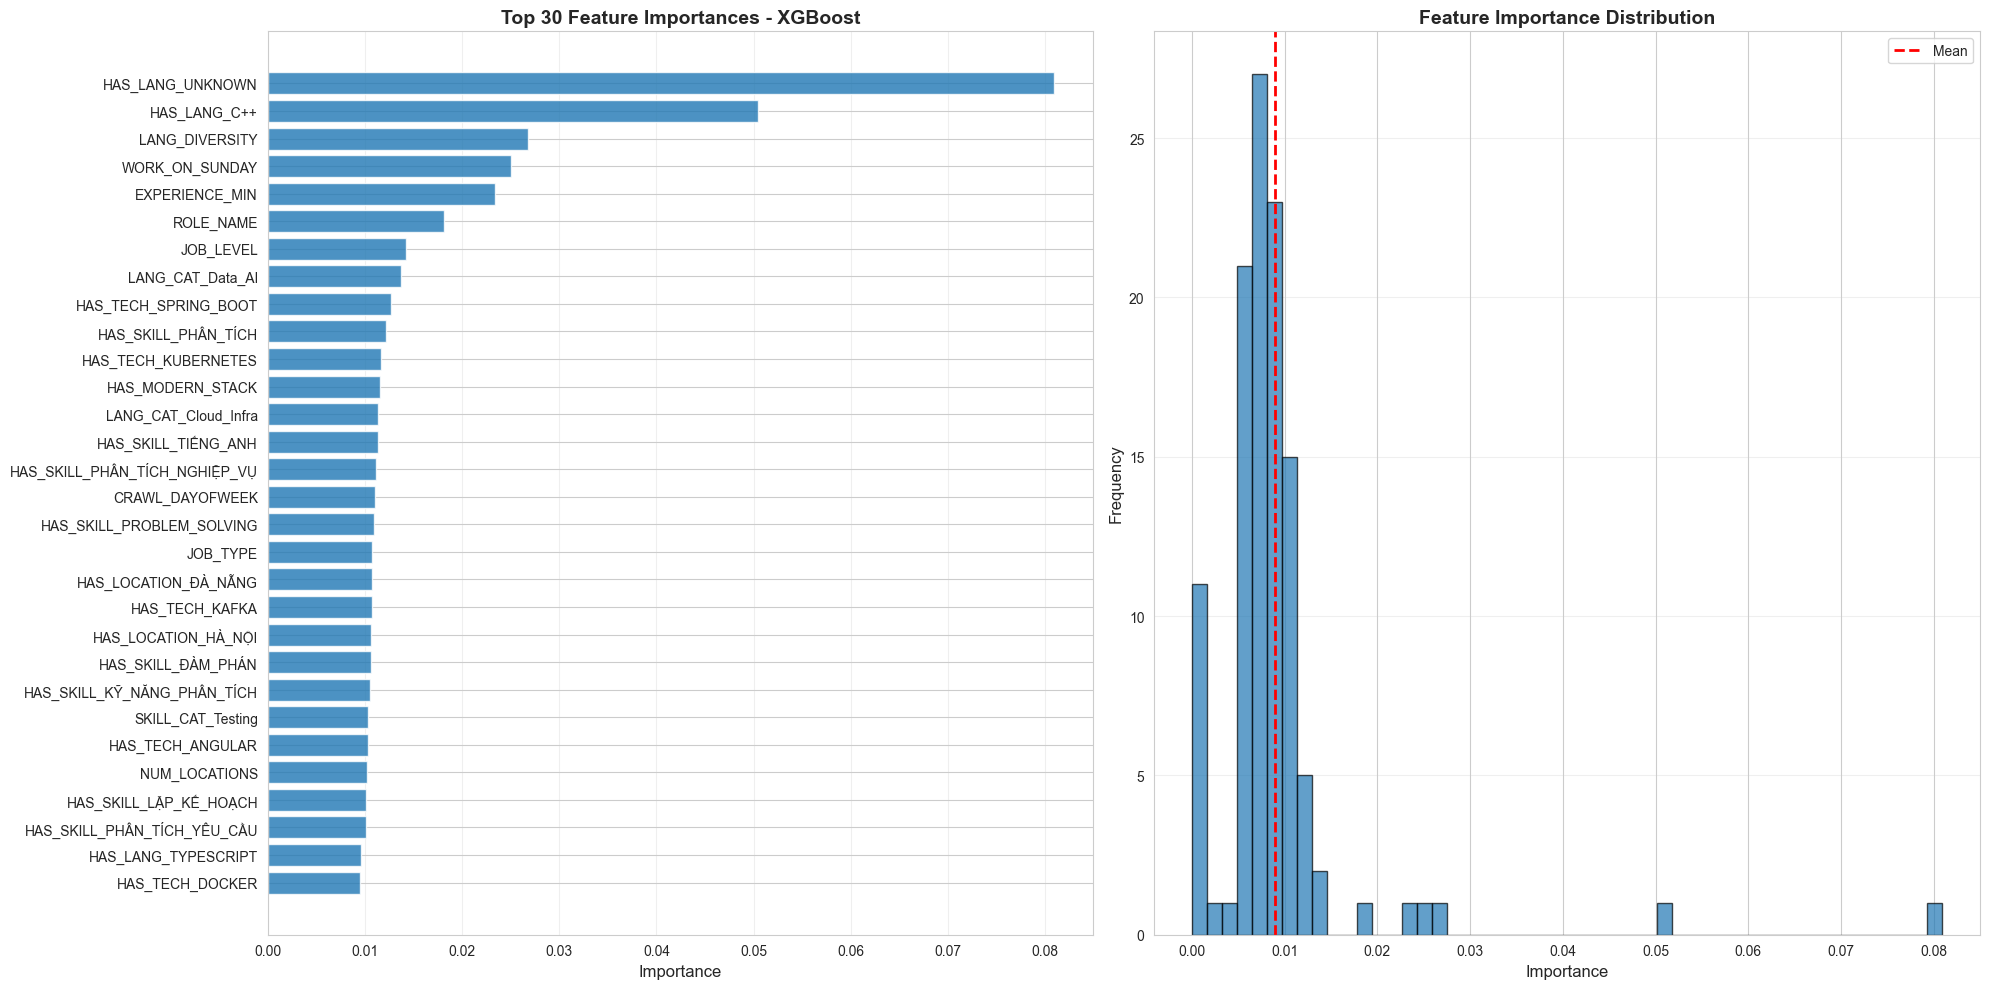


FEATURE IMPORTANCE BY TYPE

Binary Tech Features:
  Count: 15
  Average Importance: 0.008386
  Max Importance: 0.012737 (HAS_TECH_SPRING_BOOT)
  Top 3: HAS_TECH_SPRING_BOOT, HAS_TECH_KUBERNETES, HAS_TECH_KAFKA

Binary Lang Features:
  Count: 9
  Average Importance: 0.020009
  Max Importance: 0.080924 (HAS_LANG_UNKNOWN)
  Top 3: HAS_LANG_UNKNOWN, HAS_LANG_C++, HAS_LANG_TYPESCRIPT

Binary Skill Features:
  Count: 20
  Average Importance: 0.009025
  Max Importance: 0.012124 (HAS_SKILL_PHÂN_TÍCH)
  Top 3: HAS_SKILL_PHÂN_TÍCH, HAS_SKILL_TIẾNG_ANH, HAS_SKILL_PHÂN_TÍCH_NGHIỆP_VỤ

Binary Location Features:
  Count: 3
  Average Importance: 0.009852
  Max Importance: 0.010723 (HAS_LOCATION_ĐÀ_NẴNG)
  Top 3: HAS_LOCATION_ĐÀ_NẴNG, HAS_LOCATION_HÀ_NỘI, HAS_LOCATION_HỒ_CHÍ_MINH

Category Features:
  Count: 27
  Average Importance: 0.006197
  Max Importance: 0.013742 (LANG_CAT_Data_AI)
  Top 3: LANG_CAT_Data_AI, LANG_CAT_Cloud_Infra, SKILL_CAT_Testing

Diversity Features:
  Count: 10
  Average Impor

In [208]:
# Feature importance for best model
best_model = best_model_result['model']

if hasattr(best_model, 'feature_importances_'):
    # Get feature importances
    importances = best_model.feature_importances_
    feature_names = X_train.columns
    
    # Create DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Print top 30 features
    print("\n" + "="*80)
    print(f"TOP 30 MOST IMPORTANT FEATURES - {best_model_name}")
    print("="*80)
    print(feature_importance_df.head(30).to_string(index=False))
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Top 30 features
    top_30 = feature_importance_df.head(30)
    ax1.barh(range(len(top_30)), top_30['Importance'], alpha=0.8)
    ax1.set_yticks(range(len(top_30)))
    ax1.set_yticklabels(top_30['Feature'])
    ax1.invert_yaxis()
    ax1.set_xlabel('Importance', fontsize=12)
    ax1.set_title(f'Top 30 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Feature importance distribution
    ax2.hist(feature_importance_df['Importance'], bins=50, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Importance', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Feature Importance Distribution', fontsize=14, fontweight='bold')
    ax2.axvline(feature_importance_df['Importance'].mean(), color='red', 
                linestyle='--', linewidth=2, label='Mean')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Group by feature type
    print("\n" + "="*80)
    print("FEATURE IMPORTANCE BY TYPE")
    print("="*80)
    
    feature_types = {
        'Binary Tech Features': feature_importance_df[feature_importance_df['Feature'].str.startswith('HAS_TECH_')],
        'Binary Lang Features': feature_importance_df[feature_importance_df['Feature'].str.startswith('HAS_LANG_')],
        'Binary Skill Features': feature_importance_df[feature_importance_df['Feature'].str.startswith('HAS_SKILL_')],
        'Binary Location Features': feature_importance_df[feature_importance_df['Feature'].str.startswith('HAS_LOCATION_')],
        'Category Features': feature_importance_df[feature_importance_df['Feature'].str.contains('_CAT_')],
        'Diversity Features': feature_importance_df[
            (feature_importance_df['Feature'].str.contains('DIVERSITY')) |
            (feature_importance_df['Feature'].str.startswith('IS_')) |
            (feature_importance_df['Feature'] == 'SPECIALIZATION_SCORE')
        ],
        'Basic Numerical': feature_importance_df[
            ~(feature_importance_df['Feature'].str.startswith('HAS_')) &
            ~(feature_importance_df['Feature'].str.contains('_CAT_')) &
            ~(feature_importance_df['Feature'].str.contains('DIVERSITY')) &
            ~(feature_importance_df['Feature'].str.startswith('IS_')) &
            (feature_importance_df['Feature'] != 'SPECIALIZATION_SCORE')
        ]
    }
    
    for feature_type, features_df in feature_types.items():
        if len(features_df) > 0:
            avg_importance = features_df['Importance'].mean()
            max_importance = features_df['Importance'].max()
            top_feature = features_df.iloc[0]['Feature']
            print(f"\n{feature_type}:")
            print(f"  Count: {len(features_df)}")
            print(f"  Average Importance: {avg_importance:.6f}")
            print(f"  Max Importance: {max_importance:.6f} ({top_feature})")
            print(f"  Top 3: {', '.join(features_df.head(3)['Feature'].tolist())}")

else:
    print(f"\n{best_model_name} does not support feature importance analysis.")